In [1]:
import pandas as pd
import numpy as np
import json
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


In [58]:
predicted_df = pd.read_csv('regions_labels_predicted.csv')
trait_json = open('Lythrum_traits_standardized.json')
traits = json.load(trait_json)

In [3]:
predicted_df.head()

,image_path,cluster_id,leaf,flower,stem,hand,background/undefined,filename,obs_id,group,y_true,y_pred
0,lythrum_virgatum_1111.jpeg_region_2.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_virgatum_1111.jpeg,33281,lythrum_virgatum,0,0
1,lythrum_salicaria_7620.jpg_region_1.png,19,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_7620.jpg,7619,lythrum_salicaria,0,0
2,lythrum_alatum_5059.jpeg_region_2.png,27,NaN,NaN,NaN,NaN,1.0,lythrum_alatum_5059.jpeg,39768,lythrum_alatum,1,1
3,lythrum_salicaria_4752.jpeg_region_2.png,12,1.0,NaN,1.0,NaN,NaN,lythrum_salicaria_4752.jpeg,4751,lythrum_salicaria,0,1
4,lythrum_alatum_2102.jpeg_region_9.png,25,1.0,NaN,1.0,NaN,NaN,lythrum_alatum_2102.jpeg,36811,lythrum_alatum,1,1


In [59]:
label_columns = ['leaf', 'flower', 'stem', 'hand', 'background/undefined']
info_columns = ['filename', 'obs_id', 'group', 'y_true', 'y_pred']
predicted_df['group'] = predicted_df['group'].str.replace('_', ' ')

def get_characteristic_traits(row, traits_dict):
    species = row['group']  # species
    traits_for_species = traits_dict.get(species, {})
    collected_traits = []
    for label in ['leaf', 'flower', 'stem']:  # only biological traits
        if row[label] == 1:
            label_key = label if label in traits_for_species  else None
            if label_key:
                collected_traits.extend(traits_for_species[label_key])
    return collected_traits

merged_df = predicted_df[info_columns + ['hand', 'background/undefined']].copy()
merged_df['characteristic_traits'] = predicted_df.apply(lambda row: get_characteristic_traits(row, traits), axis=1)
print(merged_df.head())

                      filename  obs_id              group  y_true  y_pred  \
0   lythrum_virgatum_1111.jpeg   33281   lythrum virgatum       0       0   
1   lythrum_salicaria_7620.jpg    7619  lythrum salicaria       0       0   
2     lythrum_alatum_5059.jpeg   39768     lythrum alatum       1       1   
3  lythrum_salicaria_4752.jpeg    4751  lythrum salicaria       0       1   
4     lythrum_alatum_2102.jpeg   36811     lythrum alatum       1       1   

   hand  background/undefined  \
0   NaN                   NaN   
1   NaN                   NaN   
2   NaN                   1.0   
3   NaN                   NaN   
4   NaN                   NaN   

                               characteristic_traits  
0  [leaves opposite, sessile, getting narrower at...  
1  [leaves opposite, sessile, alternate distally,...  
2                                                 []  
3  [leaves opposite, sessile, alternate distally,...  
4  [leaves opposite, becoming alternate distally,...  


In [5]:
merged_df.columns

Index(['filename', 'obs_id', 'group', 'y_true', 'y_pred', 'hand',
       'background/undefined', 'characteristic_traits'],
      dtype='object')

# First try with association rules

In [6]:
df = merged_df.copy()
def classification_outcome(row):
    if row['y_true'] == 1 and row['y_pred'] == 1:
        return 'TP'   # correctly classified as present
    elif row['y_true'] == 0 and row['y_pred'] == 0:
        return 'TN'   # correctly classified as absent
    elif row['y_true'] == 1 and row['y_pred'] == 0:
        return 'FN'   # false negative
    elif row['y_true'] == 0 and row['y_pred'] == 1:
        return 'FP'   # false positive
    else:
        return 'Unknown'

df['classification_outcome'] = df.apply(classification_outcome, axis=1)


# collect all traits per row as list
transactions = df['characteristic_traits'].tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
traits_df = pd.DataFrame(te_ary, columns=te.columns_)

# add hand and background/undefined as binary
traits_df['hand'] = df['hand']
traits_df['background_undefined'] = df['background/undefined']

# add target variable for rule mining
traits_df['classification_outcome'] = df['classification_outcome']
traits_boolean_df = traits_df.drop(columns=['classification_outcome']).fillna(False).astype(bool)


def find_rules(df, classification_outcome, min_support=0.01, metric="confidence", min_threshold=0.4):

    frequent_itemsets = apriori(traits_boolean_df, min_support=0.01, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

    rules = rules[rules['consequents'].apply(lambda x: classification_outcome in x)]

    return rules

In [7]:
traits_boolean_df.columns

Index(['4 minute petals',
       'a discernible gap between the stem and the base of the blade',
       'alternate distally', 'base attenuate', 'base narrowly attenuate',
       'base obtuse to truncate', 'base rounded',
       'becoming alternate distally', 'broader at the base',
       'calyx with alternate long and small teeth',
       'calyx with teeth of the same length', 'creeping',
       'creeping to weakly erect', 'distally alternate', 'erect',
       'erect or decumbent', 'floral tube campanulate',
       'floral tube cylindrical',
       'floral tube narrowly obconic without red dots', 'floral tube obconic',
       'floral tube obconic without red dots',
       'flower tube narrowly cylindrical without red dots', 'flowers solitary',
       'getting narrower at the base', 'inflorescence raceme',
       'inflorescence spikelike', 'inflorescence spikelike to raceme',
       'leaves alternate', 'leaves mostly alternate', 'leaves opposite',
       'leaves opposite but sometimes a

In [ ]:
supports = [0.1, 0.05, 0.01, 0.005, 0.001]
thresholds = [0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

tp_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'TP']
tn_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'TN']
fp_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'FP']
fn_traits_boolean = traits_boolean_df[traits_df['classification_outcome'] == 'FN']

for s in supports:
    for t in thresholds:

        print(f"Config: support {s}; threshold {t}")

        tp_rules = find_rules(tp_traits_boolean, 'TP', min_support=s, min_threshold=t)
        tn_rules = find_rules(tn_traits_boolean, 'TN', min_support=s, min_threshold=t)
        fp_rules = find_rules(fp_traits_boolean, 'FP', min_support=s, min_threshold=t)
        fn_rules = find_rules(fn_traits_boolean, 'FN', min_support=s, min_threshold=t)

        print("TP Rules:")
        print(tp_rules)
        print("\nTN Rules:")
        print(tn_rules)
        print("\nFP Rules:")
        print(fp_rules)
        print("\nFN Rules:")
        print(fn_rules)

Config: support 0.1; threshold 0.6
TP Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

TN Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

FP Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

FN Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []
Config: support 0.1; threshold 0.5
TP Rules:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, leverage, conviction, zhangs_metric]
Index: []

TN Rules:
Empty DataFrame
Columns: [antecedent

# Let's try something more structured

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class ImprovedPlantModelAnalyzer:
    def __init__(self, df):
        """
        Initialize analyzer with plant invasiveness dataframe
        Expected columns: 'filename', 'obs_id', 'group', 'y_true', 'y_pred', 
                         'hand', 'background/undefined', 'characteristic_traits'
        """
        self.df = df.copy()
        self.prepare_data()
        
    def prepare_data(self):
        """Prepare data for analysis"""
        print("Preparing data...")
        
        # Create model correctness indicator
        self.df['correct_prediction'] = (self.df['y_true'] == self.df['y_pred']).astype(int)
        
        # Create error type column
        self.df['error_type'] = 'Correct'
        self.df.loc[(self.df['y_true'] == 0) & (self.df['y_pred'] == 1), 'error_type'] = 'False Positive'
        self.df.loc[(self.df['y_true'] == 1) & (self.df['y_pred'] == 0), 'error_type'] = 'False Negative'
        
        # Process characteristic traits if they're in list format
        if isinstance(self.df['characteristic_traits'].iloc[0], str):
            # If stored as string representation of list, convert
            self.df['characteristic_traits'] = self.df['characteristic_traits'].apply(
                lambda x: eval(x) if x.startswith('[') else [x] if pd.notna(x) else []
            )
        
        # Create binary columns for each unique trait
        all_traits = set()
        for traits in self.df['characteristic_traits'].dropna():
            if isinstance(traits, list):
                all_traits.update(traits)
            else:
                all_traits.add(traits)
        
        self.all_traits = sorted(list(all_traits))
        
        # Create binary trait columns
        for trait in self.all_traits:
            self.df[f'has_{trait}'] = self.df['characteristic_traits'].apply(
                lambda x: 1 if isinstance(x, list) and trait in x else 0
            )
        
        print(f"Dataset prepared: {len(self.df)} samples, {len(self.all_traits)} unique traits")
    
    def bootstrap_ci(self, data1, data2, n_bootstrap=1000, ci=95):
        """Bootstrap confidence interval for difference in means."""
        diffs = []
        n1, n2 = len(data1), len(data2)
        for _ in range(n_bootstrap):
            sample1 = np.random.choice(data1, size=n1, replace=True)
            sample2 = np.random.choice(data2, size=n2, replace=True)
            diffs.append(sample1.mean() - sample2.mean())
        lower = np.percentile(diffs, (100 - ci) / 2)
        upper = np.percentile(diffs, 100 - (100 - ci) / 2)
        return (lower, upper)

    # -------------------------
    # 1. Trait Impact Analysis
    # -------------------------
    def summarize_trait_impact(self, top_n=10):
        """
        Shows which traits help or hurt model accuracy the most.
        """
        impacts = []
        for trait in self.all_traits:
            col = f'has_{trait}'
            with_trait = self.df[self.df[col] == 1]
            without_trait = self.df[self.df[col] == 0]


            if len(with_trait) >= 5:
                acc_with = with_trait['correct_prediction'].mean()
                acc_without = without_trait['correct_prediction'].mean()
                diff = acc_with - acc_without


                ci_low, ci_high = self.bootstrap_ci(with_trait['correct_prediction'].values,without_trait['correct_prediction'].values, n_bootstrap=50)


                impacts.append({
                    'trait': trait,
                    'accuracy_with': acc_with,
                    'accuracy_without': acc_without,
                    'impact': diff,
                    'ci_low': ci_low,
                    'ci_high': ci_high,
                    'n_with': len(with_trait),
                    'n_without': len(without_trait)
                    })


        impact_df = pd.DataFrame(impacts).sort_values('impact', key=abs, ascending=False)


        print(f"TOP {top_n} TRAITS BY IMPACT ON ACCURACY:")
        print("-" * 70)
        for _, row in impact_df.head(top_n).iterrows():
            direction = "HELPS" if row['impact'] > 0 else "HURTS"
            print(f"Trait: {row['trait']}")
            print(f" → Impact: {direction} by {row['impact']:+.3f} (95% CI: [{row['ci_low']:.3f}, {row['ci_high']:.3f}])")
            print(f" → Sample Sizes: With={row['n_with']} | Without={row['n_without']}")
            print()


        return impact_df

    # -------------------------
    # 2. Bias Audit Analysis
    # -------------------------
    def audit_bias(self, top_n=10):
        """
        Focuses on fairness: demographic parity, TPR/FPR, precision, recall.
        """
        audits = []
        for trait in self.all_traits:
            col = f'has_{trait}'
            with_trait = self.df[self.df[col] == 1]
            without_trait = self.df[self.df[col] == 0]


            if len(with_trait) >= 5:
                pred_rate_with = with_trait['y_pred'].mean()
                pred_rate_without = without_trait['y_pred'].mean()
                demo_parity = pred_rate_with - pred_rate_without


                def safe_rate(df, cond, col):
                    subset = df[df['y_true'] == cond]
                    return subset[col].mean() if len(subset) > 0 else np.nan


                tpr_with = safe_rate(with_trait, 1, 'y_pred')
                tpr_without = safe_rate(without_trait, 1, 'y_pred')
                fpr_with = safe_rate(with_trait, 0, 'y_pred')
                fpr_without = safe_rate(without_trait, 0, 'y_pred')


                precision_with = np.nan
                precision_without = np.nan
                recall_with = np.nan
                recall_without = np.nan
                f1_with = np.nan
                f1_without = np.nan


                for grp, df_sub in [("with", with_trait), ("without", without_trait)]:
                    tp = ((df_sub['y_true'] == 1) & (df_sub['y_pred'] == 1)).sum()
                    fp = ((df_sub['y_true'] == 0) & (df_sub['y_pred'] == 1)).sum()
                    fn = ((df_sub['y_true'] == 1) & (df_sub['y_pred'] == 0)).sum()


                    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
                    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
                    f1 = 2 * precision * recall / (precision + recall) if precision > 0 and recall > 0 else np.nan


                    if grp == "with":
                        precision_with, recall_with, f1_with = precision, recall, f1
                    else:
                        precision_without, recall_without, f1_without = precision, recall, f1


                audits.append({
                    'trait': trait,
                    'demographic_parity_diff': demo_parity,
                    'tpr_diff': tpr_with - tpr_without if not (np.isnan(tpr_with) or np.isnan(tpr_without)) else np.nan,
                    'fpr_diff': fpr_with - fpr_without if not (np.isnan(fpr_with) or np.isnan(fpr_without)) else np.nan,
                    'precision_with': precision_with,
                    'precision_without': precision_without,
                    'recall_with': recall_with,
                    'recall_without': recall_without,
                    'f1_with': f1_with,
                    'f1_without': f1_without,
                    'n_with': len(with_trait)
                    })


        audit_df = pd.DataFrame(audits)


        print(f"TOP {top_n} TRAITS WITH FAIRNESS GAPS:")
        print("-" * 70)
        for _, row in audit_df.head(top_n).iterrows():
            print(f"Trait: {row['trait']}")
            print(f" → Demographic Parity Diff: {row['demographic_parity_diff']:+.3f}")
            print(f" → TPR Diff: {row['tpr_diff']}")
            print(f" → FPR Diff: {row['fpr_diff']}")
            print(f" → Precision (With={row['precision_with']:.3f}, Without={row['precision_without']:.3f})")
            print(f" → Recall (With={row['recall_with']}, Without={row['recall_without']})")
            print(f" → F1 (With={row['f1_with']}, Without={row['f1_without']})")
            print()


        return audit_df
    
    # -------------------------
    # 3. Combined Dashboard
    # -------------------------
    def combined_trait_bias_dashboard(self, impact_df, audit_df, bias_threshold=0.1, top_n=20):
        """
        Links trait impact and bias analysis.
        Text + Visual: show traits that are risky in terms of both.
        """
        new_audit_df = audit_df.copy()
        if 'n_with' not in new_audit_df.columns and 'n_with' in impact_df.columns:
            new_audit_df['n_with'] = impact_df.set_index('trait')['n_with']
        combined = impact_df.merge(new_audit_df, on='trait')
        combined['bias_severity'] = combined[['demographic_parity_diff', 'tpr_diff', 'fpr_diff']].abs().max(axis=1)


        risky = combined[(combined['bias_severity'] > bias_threshold) | (combined['impact'].abs() > 0.05)]
        risky = risky.sort_values(['bias_severity', 'impact'], ascending=False).head(top_n)

        # Determine which n_with column to use after merge
        if 'n_with_x' in combined.columns:
            combined['n_with_combined'] = combined['n_with_x']
        elif 'n_with_y' in combined.columns:
            combined['n_with_combined'] = combined['n_with_y']
        else:
            combined['n_with_combined'] = combined['n_with']

        print("COMBINED TRAIT-BIAS DASHBOARD:")
        print("=" * 70)
        for _, row in risky.iterrows():
            flags = []
            if row['impact'] < 0: flags.append("⚠️ Hurts accuracy")
            if row['bias_severity'] > bias_threshold: flags.append("⚠️ Bias risk")
            n_with = row.get('n_with_combined', np.nan)
            if (row['precision_with'] == 1 and row['recall_with'] == 1 and n_with < 500):
                flags.append("⚠️ Possible overfitting")
            if (row['precision_with'] == 0 or row['recall_with'] == 0):
                flags.append("⚠️ Subgroup failure")


            print(f"Trait: {row['trait']}")
            print(f" → Accuracy Impact: {row['impact']:+.3f}")
            print(f" → Bias Severity: {row['bias_severity']:+.3f}")
            print(f" → Flags: {' | '.join(flags) if flags else 'None'}")
            print()


        # Visual: scatter plot
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=combined,
            x='impact',
            y='bias_severity',
            hue='trait',
            size='n_with_combined',
            sizes=(20, 200),
            legend=False
            )
        plt.axvline(0, color='gray', linestyle='--')
        plt.axhline(bias_threshold, color='red', linestyle='--', label='Bias threshold')
        plt.xlabel("Accuracy Impact")
        plt.ylabel("Bias Severity (max gap)")
        plt.title("Trait Impact vs Bias Severity")
        plt.show()


        return combined
    
    def trait_label_outcome_drivers(self, top_n=15, min_images=20, rf_estimators=200, random_state=42):
        """
        Multi-layer outcome driver analysis:
        1. Fraction-based descriptive stats (TP/TN/FP/FN per trait/label)
        2. Logistic regression meta-model (coefficients show directional influence)
        3. Random forest meta-model (feature importances capture nonlinearities/interactions)
        """

        df = self.df.copy()

        # Explicit outcome labeling (with invasive=0, non-invasive=1)
        conditions = [
            (df['y_true']==0) & (df['y_pred']==0),  # invasive correctly classified
            (df['y_true']==1) & (df['y_pred']==1),  # non-invasive correctly classified
            (df['y_true']==1) & (df['y_pred']==0),  # non-invasive misclassified as invasive
            (df['y_true']==0) & (df['y_pred']==1),  # invasive misclassified as non-invasive
        ]
        outcomes = ['TP','TN','FP','FN']
        df['outcome'] = np.select(conditions, outcomes)

        print("🔎 Outcome Driver Analysis")
        print("We examine each trait/label to see how they relate to four possible outcomes:")
        print("  - TP: invasive correctly classified")
        print("  - TN: non-invasive correctly classified")
        print("  - FP: non-invasive misclassified as invasive (false alarm)")
        print("  - FN: invasive misclassified as non-invasive (missed invasive)")
        print("First, we compute simple fractions. Then, we fit logistic regression and random forest models.\n")

        # ---------- (1) Fraction-based descriptive analysis ----------
        records = []
        all_features = self.all_traits
        for trait in all_features:
            col = f'has_{trait}'
            with_feat = df[df[col]==1]
            without_feat = df[df[col]==0]

            if len(with_feat) < min_images:
                continue

            rec = {
                'feature': col.replace("trait_","").replace("_present",""),
                'n_with': len(with_feat),
                'n_without': len(without_feat),
            }
            for outcome in outcomes:
                # normalize: share of this trait among all outcome cases
                denom = (df['outcome']==outcome).sum()
                rec[f'{outcome}_share'] = ((with_feat['outcome']==outcome).sum() / denom) if denom>0 else 0
            records.append(rec)

        result_df = pd.DataFrame(records)
        if result_df.empty:
            print("⚠️ No traits/labels meet the minimum image requirement.")
            return None

        result_df['max_driver'] = result_df[[f"{o}_share" for o in outcomes]].max(axis=1)
        result_df = result_df.sort_values('max_driver', ascending=False).head(top_n)

        print("📊 Top drivers of prediction outcomes (fraction-based, normalized):")
        display(result_df)

        print("\n📝 Interpretation (fractions):")
        fp_top = result_df.sort_values("FP_share", ascending=False).head(3)
        fn_top = result_df.sort_values("FN_share", ascending=False).head(3)
        tp_top = result_df.sort_values("TP_share", ascending=False).head(3)
        tn_top = result_df.sort_values("TN_share", ascending=False).head(3)

        print(f"- Traits most linked to FALSE POSITIVES: {', '.join(fp_top['feature'].values)} "
            f"(shares ~ {', '.join(fp_top['FP_share'].round(2).astype(str))}).")
        print(f"- Traits most linked to FALSE NEGATIVES: {', '.join(fn_top['feature'].values)} "
            f"(shares ~ {', '.join(fn_top['FN_share'].round(2).astype(str))}).")
        print(f"- Traits most linked to correct invasive detection (TP): {', '.join(tp_top['feature'].values)}.")
        print(f"- Traits most linked to correct non-invasive detection (TN): {', '.join(tn_top['feature'].values)}.")


        # ---------- (2) Logistic Regression ----------
        print("\n📈 Logistic Regression Meta-Model (multinomial)")
        X = df[[f'has_{t}' for t in all_features]]
        y = df['outcome']

        logreg = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(multi_class="multinomial", max_iter=200, random_state=random_state))
        ])
        logreg.fit(X, y)

        coef_df = pd.DataFrame(
            logreg.named_steps["clf"].coef_,
            columns=all_features,
            index=logreg.named_steps["clf"].classes_
        ).T
        # Normalize coefficients per outcome
        coef_df_abs = coef_df.abs()
        coef_df_norm = coef_df_abs.div(coef_df_abs.max(axis=0), axis=1)  # scale to [0,1] per outcome

        coef_df = coef_df.abs().sort_values(by=['TP','TN','FP','FN'], ascending=False)
        print("Top normalized coefficients (strongest drivers per outcome):")
        display(coef_df_norm.head(top_n))

        print("\n📝 Interpretation (logistic regression):")
        for outcome in outcomes:
            top_feats = coef_df[outcome].abs().sort_values(ascending=False).head(3).index.tolist()
            print(f"- Strongest predictors of {outcome}: {', '.join(top_feats)}")


        # ---------- (3) Random Forest ----------
        print("\n🌲 Random Forest Meta-Model")
        rf = RandomForestClassifier(n_estimators=rf_estimators, random_state=random_state, n_jobs=-1)
        rf.fit(X, y)

        importances_global = pd.DataFrame({
            "feature": all_features,
            "importance": rf.feature_importances_
        }).sort_values("importance", ascending=False).head(top_n)

        print("Top feature importances:")
        display(importances_global)
        print("\n📝 Interpretation (random forest):")
        print(f"- Traits with strongest overall predictive importance: {', '.join(importances_global['feature'].head(5).values)}.")

        rf_outcome_dfs = []
        for outcome in outcomes:
            y_bin = (y == outcome).astype(int)
            rf_bin = RandomForestClassifier(n_estimators=rf_estimators, random_state=random_state, n_jobs=-1)
            rf_bin.fit(X, y_bin)
            imp = pd.Series(rf_bin.feature_importances_, index=X.columns.str.replace("has_",""))
            imp = imp / imp.max()  # normalize per outcome
            rf_outcome_dfs.append(imp.rename(f'{outcome}'))

        rf_outcome_df = pd.DataFrame(rf_outcome_dfs).T

        print("\nOutcome-specific feature importances (normalized per outcome):")
        display(rf_outcome_df.head(top_n))

        print("\n📝 Interpretation (random forest outcome-specific):")
        for outcome in outcomes:
            top_feats = rf_outcome_df[outcome].sort_values(ascending=False).head(3).index.tolist()
            print(f"- Strongest predictors of {outcome}: {', '.join(top_feats)}")

        rf_df = pd.concat([importances_global] + rf_outcome_dfs, axis=1)
        rf_df = rf_df.sort_values("importance", ascending=False).head(top_n)
        # ---------- Visualization ----------
        fig, axes = plt.subplots(1,3, figsize=(20,6))

        # Fractions: stacked bar
        plot_df = result_df.melt(
            id_vars=['feature','n_with'],
            value_vars=['TP_share','TN_share','FP_share','FN_share'],
            var_name='Outcome', value_name='Fraction'
        )
        sns.barplot(data=plot_df, x='Fraction', y='feature', hue='Outcome', dodge=False, ax=axes[0])
        axes[0].set_title("Fraction-based outcome composition")
        axes[0].set_xlabel("Fraction")
        axes[0].set_ylabel("Trait / Label")

        # Logistic regression: heatmap
        sns.heatmap(coef_df.head(top_n), annot=True, cmap="coolwarm", center=0, ax=axes[1])
        axes[1].set_title("Logistic Regression Coefficients (abs values)")

        # Random forest: barplot
        sns.heatmap(rf_outcome_df.loc[importances_global['feature'].head(top_n)], annot=True, cmap="viridis", ax=axes[2])
        axes[2].set_title("Random Forest Outcome-Specific Importances")

        plt.tight_layout()
        plt.show()

        return result_df, coef_df, rf_df
    
    def analyze_hand_background_labels(self):
        """
        Improved: Impact of 'hand' and 'background/undefined' labels.
        - Treats NaNs as an explicit 'Missing' category and reports its size.
        - Shows accuracy, precision, recall per label value.
        - Computes effect sizes and runs Chi-square / Fisher as appropriate.
        """
        print("=" * 60)
        print("ANNOTATION LABEL IMPACT ANALYSIS")
        print("=" * 60)
        print("This analyzes how annotation quality affects model performance")
        print()

        # Work on a local copy so we don't permanently mutate self.df unexpectedly
        df = self.df.copy()

        # Create explicit label columns where NaN -> 'Missing' (string) for clear grouping
        df['hand_label'] = df['hand'].fillna('Missing').astype(str)
        df['bg_label'] = df['background/undefined'].fillna('Missing').astype(str)

        # Helper to compute precision/recall safely
        def compute_metrics(subset):
            if subset.empty:
                return (np.nan, np.nan)
            cm = confusion_matrix(subset['y_true'], subset['y_pred'], labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            return precision, recall

        # Generic label analysis routine
        def analyze_col(col_name, pretty_name):
            print(f"1. {pretty_name}" if 'HAND' in pretty_name else f"2. {pretty_name}")
            print(f"   (shows counts including missing values and performance metrics per value)")
            print()

            # Value counts including missing
            vc = df[col_name].value_counts(dropna=False)
            print("   Value counts (including Missing):")
            for val, cnt in vc.items():
                pct = cnt / len(df)
                print(f"     {str(val):12s} n={cnt:,} ({pct:.1%})")
            print()

            # Grouped metrics
            grouped = df.groupby(col_name).agg({
                'correct_prediction': ['count', 'mean'],
                'y_true': 'mean',
                'y_pred': 'mean'
            }).round(3)
            grouped.columns = ['sample_count', 'accuracy', 'true_invasive_rate', 'pred_invasive_rate']

            # Add precision & recall per group
            for val in grouped.index:
                prec, rec = compute_metrics(df[df[col_name] == val])
                grouped.loc[val, 'precision'] = round(prec, 3) if not np.isnan(prec) else np.nan
                grouped.loc[val, 'recall'] = round(rec, 3) if not np.isnan(rec) else np.nan

            # Print results
            print(f"   Results by {pretty_name.split()[0]} Label Value:")
            for val, row in grouped.iterrows():
                print(f"     {str(val):12s}: Acc={row['accuracy']:.3f}, "
                    f"Prec={row['precision']:.3f}, Rec={row['recall']:.3f} "
                    f"(n={int(row['sample_count']):,} samples)")
            print()

            # Effect size: prefer direct 1 vs 0 comparison if available, otherwise compare to 'Missing'
            acc_series = grouped['accuracy']
            p_val = None
            method = None
            if '1.0' in acc_series.index and '0.0' in acc_series.index:
                diff = acc_series.loc['1.0'] - acc_series.loc['0.0']
                print(f"   Accuracy difference (1.0 vs 0.0): {diff:+.3f}")
            else:
                # compare first non-missing value to Missing if both exist
                non_missing = [i for i in acc_series.index if i != 'Missing']
                if len(non_missing) >= 1 and 'Missing' in acc_series.index:
                    diff = acc_series.loc[non_missing[0]] - acc_series.loc['Missing']
                    print(f"   Accuracy difference ({non_missing[0]} vs Missing): {diff:+.3f}")
            print()

            # Build contingency table including 'Missing' (we filled it above)
            contingency = pd.crosstab(df[col_name], df['correct_prediction'], dropna=False)
            # Need at least 2 label groups and two outcome columns to run tests
            if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
                # If 2x2, consider Fisher when expected counts are small
                if contingency.shape == (2, 2):
                    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
                    if (expected < 5).any():
                        # use Fisher exact for small expected counts
                        try:
                            oddsratio, p_fisher = stats.fisher_exact(contingency.values)
                            p_val = p_fisher
                            method = "Fisher exact (2x2, small expected)"
                        except Exception:
                            p_val = p_chi
                            method = "Chi-square (fallback)"
                    else:
                        p_val = p_chi
                        method = "Chi-square"
                else:
                    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
                    p_val = p_chi
                    method = "Chi-square"

                significance = "SIGNIFICANT" if (p_val is not None and p_val < 0.05) else "NOT significant"
                print(f"   Statistical test: {method} => {significance} (p={p_val:.4f})")
            else:
                print("   Statistical test: NOT RUN - need >=2 label groups and >=2 outcome classes (0/1).")
                p_val = None

            print()
            return grouped, contingency, p_val

        # Run analyses for both columns
        hand_stats, hand_contingency, hand_p = analyze_col('hand_label', "'HAND' LABEL IMPACT:")
        bg_stats, bg_contingency, bg_p = analyze_col('bg_label', "'BACKGROUND/UNDEFINED' LABEL IMPACT:")

        results = {
            'hand_analysis': hand_stats,
            'background_analysis': bg_stats,
            'hand_contingency': hand_contingency,
            'background_contingency': bg_contingency,
            'hand_p_value': hand_p,
            'background_p_value': bg_p
        }

        return results

    
    def trait_combination_analysis_explained(self, min_samples=10):
        """
        CLEAR EXPLANATION: How combinations of traits affect model performance
        This shows which combinations of plant characteristics work best/worst together
        """
        print("=" * 60)
        print("TRAIT COMBINATION ANALYSIS")
        print("=" * 60)
        print("This shows how COMBINATIONS of plant traits affect model accuracy")
        print("For example: 'spiny, red flowers' vs 'smooth, white flowers'")
        print(f"Only showing combinations with at least {min_samples} samples")
        print()
        
        # Create trait combination strings
        self.df['trait_combo'] = self.df['characteristic_traits'].apply(
            lambda x: ', '.join(sorted(x)) if isinstance(x, list) and len(x) > 0 else 'No specific traits'
        )
        
        # Count number of traits per sample
        self.df['num_traits'] = self.df['characteristic_traits'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        
        # Analyze combinations with enough samples
        combo_stats = self.df.groupby('trait_combo').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean',
            'num_traits': 'first'
        }).round(3)
        
        combo_stats.columns = ['sample_size', 'accuracy', 'actual_invasive_rate', 'num_traits']
        combo_stats = combo_stats[combo_stats['sample_size'] >= min_samples]
        combo_stats = combo_stats.sort_values('accuracy', ascending=False)
        
        print("BEST PERFORMING TRAIT COMBINATIONS:")
        print("-" * 50)
        for i, (combo, row) in enumerate(combo_stats.head(5).iterrows()):
            print(f"{i+1}. Traits: {combo}")
            print(f"   Accuracy: {row['accuracy']:.3f} ({row['sample_size']} samples)")
            print(f"   {row['actual_invasive_rate']*100:.1f}% are actually invasive")
            print()
        
        print("WORST PERFORMING TRAIT COMBINATIONS:")
        print("-" * 50)
        for i, (combo, row) in enumerate(combo_stats.tail(5).iterrows()):
            print(f"{i+1}. Traits: {combo}")
            print(f"   Accuracy: {row['accuracy']:.3f} ({row['sample_size']} samples)")
            print(f"   {row['actual_invasive_rate']*100:.1f}% are actually invasive")
            print()
        
        # Analysis by number of traits
        print("PERFORMANCE BY NUMBER OF TRAITS:")
        print("-" * 40)
        trait_count_analysis = self.df.groupby('num_traits').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        }).round(3)
        trait_count_analysis.columns = ['sample_size', 'accuracy', 'actual_invasive_rate']
        
        for num_traits, row in trait_count_analysis.iterrows():
            if row['sample_size'] >= 5:
                print(f"   {num_traits} traits: Accuracy = {row['accuracy']:.3f} "
                      f"({row['sample_size']} samples)")
        
        return combo_stats
    # ---------------- NEW METHOD: TRAIT PREDICTION PATTERN ANALYSIS ----------------
    def trait_prediction_pattern_analysis(self, min_samples=10):
        """
        Detect traits that have contrasting effects on TP/TN/FP/FN,
        highlighting polarizing traits.
        """
        print("="*60)
        print("POLARIZING TRAIT ANALYSIS")
        print("="*60)
        print(f"Analyzing traits with at least {min_samples} samples to detect TP/TN/FP/FN shifts.\n")

        records = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            n_samples = self.df[trait_col].sum()
            if n_samples < min_samples:
                continue

            df_with = self.df[self.df[trait_col] == 1]
            df_without = self.df[self.df[trait_col] == 0]

            # Calculate TP/TN/FP/FN fractions
            tp_with = (df_with['error_type']=='True Positive').mean()
            tn_with = (df_with['error_type']=='True Negative').mean()
            fp_with = (df_with['error_type']=='False Positive').mean()
            fn_with = (df_with['error_type']=='False Negative').mean()

            tp_without = (df_without['error_type']=='True Positive').mean()
            tn_without = (df_without['error_type']=='True Negative').mean()
            fp_without = (df_without['error_type']=='False Positive').mean()
            fn_without = (df_without['error_type']=='False Negative').mean()

            # Changes
            tp_change = tp_with - tp_without
            tn_change = tn_with - tn_without
            fp_change = fp_with - fp_without
            fn_change = fn_with - fn_without

            # Asymmetry score: large directional effect
            asymmetry = abs(tp_change) + abs(tn_change) + abs(fp_change) + abs(fn_change)
            pattern_type = 'polarizing' if tp_change * tn_change < 0 else 'aligned'

            # Chi-square test for TP/TN shifts
            contingency = pd.DataFrame([
                [ (df_with['error_type']=='True Positive').sum(), (df_without['error_type']=='True Positive').sum() ],
                [ (df_with['error_type']=='True Negative').sum(), (df_without['error_type']=='True Negative').sum() ]
            ])
            try:
                chi2, p, _, _ = stats.chi2_contingency(contingency)
            except:
                p = 1.0

            records.append({
                'trait': trait,
                'n_samples': n_samples,
                'tp_change': tp_change,
                'tn_change': tn_change,
                'fp_change': fp_change,
                'fn_change': fn_change,
                'asymmetry_score': asymmetry,
                'pattern_type': pattern_type,
                'p_value': p
            })

        df_patterns = pd.DataFrame(records).sort_values('asymmetry_score', ascending=False)
        if not df_patterns.empty:
            top_trait = df_patterns.iloc[0]
            print(f"Most polarizing trait: '{top_trait['trait']}' with asymmetry score {top_trait['asymmetry_score']:.3f}")
            print(f"  - TP change: {top_trait['tp_change']:+.3f}, TN change: {top_trait['tn_change']:+.3f}")
            print(f"  - FP change: {top_trait['fp_change']:+.3f}, FN change: {top_trait['fn_change']:+.3f}")
            interpretation = "This trait strongly shifts predictions: "
            if top_trait['pattern_type']=='polarizing':
                interpretation += "it favors some correct predictions while increasing errors elsewhere."
            else:
                interpretation += "its effect aligns with overall accuracy (mostly helps or hurts consistently)."
            print("Interpretation:", interpretation)
        else:
            print("No traits meet the minimum sample requirement.")
        return df_patterns

    # ---------------- NEW METHOD: PLOT TRAIT PATTERNS ----------------
    def plot_trait_prediction_patterns(self, top_n=20):
        """
        Scatter and bar plots for top polarizing traits
        """
        df_patterns = self.trait_prediction_pattern_analysis()
        top_traits = df_patterns.head(top_n)

        plt.style.use('default')
        fig, axes = plt.subplots(1,2, figsize=(16,6))

        from adjustText import adjust_text  # pip install adjustText

        # Scatter TP_change vs TN_change
        axes[0].scatter(top_traits['tp_change'], top_traits['tn_change'],
                        s=80, c='orange', alpha=0.7)
        texts = []
        for i, row in top_traits.iterrows():
            texts.append(axes[0].text(row['tp_change'], row['tn_change'], row['trait'], fontsize=9))
        adjust_text(texts, ax=axes[0], arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

        axes[0].axhline(0, color='gray', linestyle='--')
        axes[0].axvline(0, color='gray', linestyle='--')
        axes[0].set_xlabel('TP Change')
        axes[0].set_ylabel('TN Change')
        axes[0].set_title('Top Polarizing Traits: TP vs TN shifts')


        # Stacked bar plot for TP/TN/FP/FN changes
        top_traits_plot = top_traits.set_index('trait')[['tp_change','tn_change','fp_change','fn_change']]
        top_traits_plot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
        axes[1].set_ylabel('Fraction Change')
        axes[1].set_title('Prediction Type Shifts by Trait')
        axes[1].legend(title='Prediction Type')
        plt.tight_layout()
        plt.show()


    def confidence_based_analysis(self):
        """
        Analyze model confidence patterns across traits and labels
        Assumes you have prediction probabilities or can derive confidence scores
        """
        print("=" * 60)
        print("CONFIDENCE-BASED ANALYSIS")
        print("=" * 60)
        
        # If you have prediction probabilities, use them; otherwise create proxy
        if 'y_prob' not in self.df.columns:
            # Create confidence proxy based on prediction correctness and error patterns
            self.df['confidence_proxy'] = np.where(
                self.df['correct_prediction'] == 1,
                np.random.uniform(0.7, 0.99, len(self.df)),  # Higher for correct
                np.random.uniform(0.51, 0.8, len(self.df))   # Lower for incorrect
            )
            print("Note: Using confidence proxy. Replace with actual prediction probabilities if available.")
        
        confidence_results = {}
        
        # Analyze confidence by traits
        for trait in self.all_traits[:10]:  # Top 10 traits only
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            
            if len(with_trait) >= 10:
                conf_diff = with_trait['confidence_proxy'].mean() - without_trait['confidence_proxy'].mean()
                confidence_results[trait] = {
                    'confidence_diff': conf_diff,
                    'with_trait_conf': with_trait['confidence_proxy'].mean(),
                    'without_trait_conf': without_trait['confidence_proxy'].mean()
                }
        
        # Sort by absolute confidence difference
        sorted_confidence = sorted(confidence_results.items(), 
                                key=lambda x: abs(x[1]['confidence_diff']), reverse=True)
        
        print("TOP TRAITS BY CONFIDENCE IMPACT:")
        for trait, metrics in sorted_confidence[:8]:
            direction = "HIGHER" if metrics['confidence_diff'] > 0 else "LOWER"
            print(f"{trait:25} {direction} confidence by {abs(metrics['confidence_diff']):.3f}")
            print(f"                         With: {metrics['with_trait_conf']:.3f} | Without: {metrics['without_trait_conf']:.3f}")
            print()
        
        return confidence_results
    
    def trait_co_occurrence_network(self):
        """
        Analyze which traits commonly appear together and their combined effects
        """
        print("=" * 60)
        print("TRAIT CO-OCCURRENCE NETWORK ANALYSIS")
        print("=" * 60)
        
        from itertools import combinations
        import networkx as nx
        
        # Create co-occurrence matrix
        co_occurrence = {}
        trait_accuracy = {}
        
        for traits_list in self.df['characteristic_traits'].dropna():
            if isinstance(traits_list, list) and len(traits_list) > 1:
                # Record co-occurrences
                for trait1, trait2 in combinations(traits_list, 2):
                    pair = tuple(sorted([trait1, trait2]))
                    co_occurrence[pair] = co_occurrence.get(pair, 0) + 1
        
        # Filter significant co-occurrences
        significant_pairs = {pair: count for pair, count in co_occurrence.items() 
                            if count >= 10}
        
        print(f"Found {len(significant_pairs)} trait pairs that co-occur ≥10 times")
        
        # Analyze accuracy for each co-occurring pair
        pair_performance = {}
        for (trait1, trait2), count in significant_pairs.items():
            # Find samples with both traits
            mask = (self.df['characteristic_traits'].apply(
                lambda x: isinstance(x, list) and trait1 in x and trait2 in x
            ))
            subset = self.df[mask]
            
            if len(subset) >= 5:
                accuracy = subset['correct_prediction'].mean()
                pair_performance[f"{trait1} + {trait2}"] = {
                    'accuracy': accuracy,
                    'count': count,
                    'invasive_rate': subset['y_true'].mean()
                }
        
        # Sort by accuracy
        sorted_pairs = sorted(pair_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        
        print("TOP CO-OCCURRING TRAIT PAIRS BY ACCURACY:")
        for pair_name, metrics in sorted_pairs[:10]:
            print(f"{pair_name[:50]:50}: Acc = {metrics['accuracy']:.3f}, "
                f"Count = {metrics['count']}, Invasive = {metrics['invasive_rate']:.3f}")
        
        return pair_performance, significant_pairs
    
    def outlier_species_analysis(self):
        """
        Deep dive into species that perform very differently from expected
        """
        print("=" * 60)
        print("OUTLIER SPECIES ANALYSIS")
        print("=" * 60)
        
        # Calculate expected accuracy based on invasive rate
        species_stats = self.df.groupby('group').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean',
            'y_pred': 'mean'
        }).round(3)
        species_stats.columns = ['sample_size', 'accuracy', 'true_invasive_rate', 'pred_invasive_rate']
        species_stats = species_stats[species_stats['sample_size'] >= 5]
        
        # Calculate "expected" accuracy (simple baseline)
        overall_accuracy = self.df['correct_prediction'].mean()
        species_stats['accuracy_deviation'] = species_stats['accuracy'] - overall_accuracy
        species_stats['prediction_bias'] = species_stats['pred_invasive_rate'] - species_stats['true_invasive_rate']
        
        # Identify outliers
        accuracy_threshold = species_stats['accuracy_deviation'].std() * 1.5
        outliers = species_stats[abs(species_stats['accuracy_deviation']) > accuracy_threshold]
        
        print("ACCURACY OUTLIER SPECIES:")
        print("(Species performing much better or worse than average)")
        print()
        
        for species, row in outliers.iterrows():
            direction = "MUCH BETTER" if row['accuracy_deviation'] > 0 else "MUCH WORSE"
            print(f"{species[:40]:40} {direction}")
            print(f"  Accuracy: {row['accuracy']:.3f} (deviation: {row['accuracy_deviation']:+.3f})")
            print(f"  True invasive rate: {row['true_invasive_rate']:.3f}")
            print(f"  Predicted invasive rate: {row['pred_invasive_rate']:.3f}")
            print(f"  Prediction bias: {row['prediction_bias']:+.3f}")
            print()
            
            # Analyze traits for this species
            species_samples = self.df[self.df['group'] == species]
            common_traits = []
            for traits_list in species_samples['characteristic_traits'].dropna():
                if isinstance(traits_list, list):
                    common_traits.extend(traits_list)
            
            if common_traits:
                trait_counts = pd.Series(common_traits).value_counts().head(3)
                print(f"  Most common traits: {', '.join(trait_counts.index.tolist())}")
            print("-" * 60)
        
        return outliers
    
    def annotation_quality_analysis(self):
        """
        Deep analysis of annotation quality patterns
        """
        print("=" * 60)
        print("ANNOTATION QUALITY DEEP ANALYSIS")
        print("=" * 60)
        
        # Create annotation completeness score
        self.df['annotation_completeness'] = (
            (~self.df['hand'].isna()).astype(int) + 
            (~self.df['background/undefined'].isna()).astype(int) +
            (self.df['characteristic_traits'].apply(lambda x: len(x) if isinstance(x, list) else 0) > 0).astype(int)
        )
        
        # Analyze performance by completeness
        completeness_analysis = self.df.groupby('annotation_completeness').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        })
        completeness_analysis.columns = ['sample_count', 'accuracy', 'invasive_rate']
        
        print("PERFORMANCE BY ANNOTATION COMPLETENESS:")
        print("(0 = no annotations, 3 = all annotations present)")
        for completeness, row in completeness_analysis.iterrows():
            print(f"Completeness {completeness}: Accuracy = {row['accuracy']:.3f}, "
                f"Count = {int(row['sample_count'])}")
        
        # Analyze annotation consistency within species
        species_annotation_consistency = []
        for species in self.df['group'].unique():
            species_data = self.df[self.df['group'] == species]
            if len(species_data) >= 3:
                # Check consistency of hand labels
                hand_consistency = len(species_data['hand'].dropna().unique()) <= 1
                bg_consistency = len(species_data['background/undefined'].dropna().unique()) <= 1
                
                # Check trait consistency (at least 50% overlap)
                all_traits = []
                for traits in species_data['characteristic_traits'].dropna():
                    if isinstance(traits, list):
                        all_traits.extend(traits)
                trait_consistency = len(set(all_traits)) <= len(all_traits) * 0.8  # Rough consistency measure
                
                consistency_score = sum([hand_consistency, bg_consistency, trait_consistency]) / 3
                species_annotation_consistency.append({
                    'species': species,
                    'consistency_score': consistency_score,
                    'sample_size': len(species_data),
                    'accuracy': species_data['correct_prediction'].mean()
                })
        
        consistency_df = pd.DataFrame(species_annotation_consistency)
        
        # Correlation between consistency and accuracy
        if len(consistency_df) > 10:
            correlation = consistency_df['consistency_score'].corr(consistency_df['accuracy'])
            print(f"\nAnnotation consistency vs accuracy correlation: {correlation:.3f}")
        
        if not consistency_df.empty:
            best_species = consistency_df.iloc[0]
            worst_species = consistency_df.iloc[-1]
            print("\nINTERPRETATION:")
            print(f"• Best annotated species: '{best_species['species']}' → accuracy {best_species['accuracy']:.3f}")
            print(f"• Worst annotated species: '{worst_species['species']}' → accuracy {worst_species['accuracy']:.3f}")
            print("→ Annotation inconsistencies may explain certain model errors.")

        return consistency_df
    
    def create_readable_visualizations(self):
        """
        Create clean, readable visualizations with limited data points
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(18, 15))
        
        # 1. Top 10 most impactful traits
        plt.subplot(3, 3, 1)
        trait_impacts = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            
            if len(with_trait) >= 10:  # Only traits with enough samples
                diff = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
                trait_impacts.append((trait, diff, len(with_trait)))
        
        # Sort and take top 10
        trait_impacts = sorted(trait_impacts, key=lambda x: abs(x[1]), reverse=True)[:10]
        traits, impacts, sizes = zip(*trait_impacts)
        
        colors = ['green' if x > 0 else 'red' for x in impacts]
        bars = plt.barh(range(len(traits)), impacts, color=colors, alpha=0.7)
        plt.yticks(range(len(traits)), [f"{t[:15]}..." if len(t) > 15 else t for t in traits])
        plt.xlabel('Accuracy Impact')
        plt.title('Top 10 Most Impactful Traits')
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Add sample sizes as text
        for i, (bar, size) in enumerate(zip(bars, sizes)):
            plt.text(bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01), 
                    bar.get_y() + bar.get_height()/2, 
                    f'n={size}', ha='left' if bar.get_width() >= 0 else 'right', va='center', fontsize=8)
        
        # 2. Overall confusion matrix
        plt.subplot(3, 3, 2)
        cm = confusion_matrix(self.df['y_true'], self.df['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'shrink': 0.8})
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        
        # 3. Performance by annotation labels
        # 3. Performance by annotation labels (with Missing handled)
        plt.subplot(3, 3, 3)

        # Prepare hand and background with Missing as explicit category
        df_labels = self.df.copy()
        df_labels['hand_label'] = df_labels['hand'].fillna('Missing').astype(str)
        df_labels['bg_label'] = df_labels['background/undefined'].fillna('Missing').astype(str)

        hand_acc = df_labels.groupby('hand_label')['correct_prediction'].mean()
        bg_acc = df_labels.groupby('bg_label')['correct_prediction'].mean()

        # Align x positions
        labels = sorted(set(hand_acc.index).union(set(bg_acc.index)))
        x = np.arange(len(labels))

        bar_width = 0.35
        plt.bar(x - bar_width/2, [hand_acc.get(l, np.nan) for l in labels], 
                width=bar_width, label='Hand Label', alpha=0.7)
        plt.bar(x + bar_width/2, [bg_acc.get(l, np.nan) for l in labels], 
                width=bar_width, label='Background Label', alpha=0.7)

        plt.xlabel('Label Value')
        plt.ylabel('Accuracy')
        plt.title('Performance by Annotation Labels (incl. Missing)')
        plt.legend()
        plt.xticks(x, labels, rotation=30)

        
        # 4. Accuracy by number of traits
        plt.subplot(3, 3, 4)
        self.df['num_traits'] = self.df['characteristic_traits'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        trait_count_acc = self.df.groupby('num_traits')['correct_prediction'].mean()
        trait_count_size = self.df.groupby('num_traits').size()
        
        # Only show counts with reasonable sample sizes
        valid_counts = trait_count_size[trait_count_size >= 10]
        
        plt.bar(valid_counts.index, trait_count_acc[valid_counts.index].values)
        plt.xlabel('Number of Traits')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')
        
        # Add sample size labels
        for x, acc, size in zip(valid_counts.index, trait_count_acc[valid_counts.index], valid_counts):
            plt.text(x, acc + 0.01, f'n={size}', ha='center', va='bottom', fontsize=8)
        
        # 5. Top 10 worst performing species
        plt.subplot(3, 3, 5)
        species_acc = self.df.groupby('group').agg({
            'correct_prediction': ['mean', 'count']
        })
        species_acc.columns = ['accuracy', 'sample_size']
        species_acc = species_acc[species_acc['sample_size'] >= 5]  # Min 5 samples
        worst_species = species_acc.sort_values('accuracy').head(10)
        
        plt.barh(range(len(worst_species)), worst_species['accuracy'].values, color='coral')
        plt.yticks(range(len(worst_species)), 
                  [f"{name[:20]}..." if len(name) > 20 else name for name in worst_species.index])
        plt.xlabel('Accuracy')
        plt.title('Top 10 Worst Performing Species')
        
        # 6. Error types distribution
        plt.subplot(3, 3, 6)
        error_counts = self.df['error_type'].value_counts()
        plt.pie(error_counts.values, labels=error_counts.index, autopct='%1.1f%%')
        plt.title('Distribution of Prediction Results')

        # NEW: Add bias heatmap
        plt.subplot(3, 3, 7)
        audit_bias_results = self.audit_bias(top_n=8)  
        bias_data = audit_bias_results[['demographic_parity_diff', 'tpr_diff', 'fpr_diff']].head(10)
        sns.heatmap(bias_data.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0)
        plt.title('Bias Metrics Heatmap (Top 10 Traits)')
        plt.xlabel('Traits')
        
        plt.tight_layout()
        plt.show()

    def create_advanced_visualizations(self):
        """
        Create additional sophisticated visualizations
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(20, 16))
        
        # 1. Trait impact vs sample size scatter
        plt.subplot(3, 4, 1)
        trait_impacts = []
        sample_sizes = []
        for trait in self.all_traits:
            trait_col = f'has_{trait}'
            with_trait = self.df[self.df[trait_col] == 1]
            without_trait = self.df[self.df[trait_col] == 0]
            if len(with_trait) >= 5:
                impact = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
                trait_impacts.append(impact)
                sample_sizes.append(len(with_trait))
        
        plt.scatter(sample_sizes, trait_impacts, alpha=0.6, s=60)
        plt.xlabel('Sample Size (with trait)')
        plt.ylabel('Accuracy Impact')
        plt.title('Trait Impact vs Sample Size')
        plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # 2. Species accuracy distribution
        plt.subplot(3, 4, 2)
        species_acc = self.df.groupby('group')['correct_prediction'].mean()
        species_acc = species_acc[self.df.groupby('group').size() >= 5]  # Min 5 samples
        plt.hist(species_acc.values, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Species Accuracy')
        plt.ylabel('Number of Species')
        plt.title('Distribution of Species-level Accuracy')
        plt.axvline(x=species_acc.mean(), color='red', linestyle='--', label=f'Mean: {species_acc.mean():.3f}')
        plt.legend()
        
        # 3. Trait co-occurrence heatmap
        plt.subplot(3, 4, 3)
        top_traits = self.all_traits[:10]  # Top 10 most common traits
        co_matrix = np.zeros((len(top_traits), len(top_traits)))
        
        for i, trait1 in enumerate(top_traits):
            for j, trait2 in enumerate(top_traits):
                if i != j:
                    # Count co-occurrences
                    co_count = sum([
                        1 for traits_list in self.df['characteristic_traits'].dropna()
                        if isinstance(traits_list, list) and trait1 in traits_list and trait2 in traits_list
                    ])
                    co_matrix[i, j] = co_count
        
        sns.heatmap(co_matrix, xticklabels=[t[:8] for t in top_traits], 
                    yticklabels=[t[:8] for t in top_traits], 
                    annot=True, fmt='.0f', cmap='YlOrRd')
        plt.title('Trait Co-occurrence Matrix')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        
        # 4. Error type by invasive status
        plt.subplot(3, 4, 4)
        error_invasive = pd.crosstab(self.df['error_type'], self.df['y_true'])
        error_invasive.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title('Error Types by True Invasive Status')
        plt.xlabel('Error Type')
        plt.ylabel('Count')
        plt.legend(['Non-invasive', 'Invasive'])
        plt.xticks(rotation=45)
        
        # 5. Prediction confidence distribution (if available)
        plt.subplot(3, 4, 5)
        if 'confidence_proxy' in self.df.columns:
            correct_conf = self.df[self.df['correct_prediction']==1]['confidence_proxy']
            incorrect_conf = self.df[self.df['correct_prediction']==0]['confidence_proxy']
            
            plt.hist([correct_conf, incorrect_conf], bins=30, alpha=0.7, 
                    label=['Correct', 'Incorrect'], color=['green', 'red'])
            plt.xlabel('Confidence Score')
            plt.ylabel('Frequency')
            plt.title('Confidence Distribution by Correctness')
            plt.legend()
        
        # 6. Trait diversity vs accuracy
        plt.subplot(3, 4, 6)
        trait_diversity = self.df['characteristic_traits'].apply(
            lambda x: len(set(x)) if isinstance(x, list) else 0
        )
        
        # Group by trait diversity and calculate accuracy
        diversity_acc = self.df.groupby(trait_diversity)['correct_prediction'].mean()
        diversity_counts = self.df.groupby(trait_diversity).size()
        
        # Only plot groups with sufficient samples
        valid_diversities = diversity_counts[diversity_counts >= 10].index
        
        if len(valid_diversities) > 1:
            plt.bar(valid_diversities, diversity_acc[valid_diversities].values)
            plt.xlabel('Number of Unique Traits')
            plt.ylabel('Accuracy')
            plt.title('Accuracy vs Trait Diversity')
        
        plt.tight_layout()
        plt.show()

    
    def comprehensive_summary_report(self):
        """
        Generate a comprehensive report including:
        - Dataset overview
        - Error breakdown
        - Trait impact and polarizing traits
        - Annotation label analysis
        - Trait combination analysis
        - Species performance
        - Readable visualizations
        """
        print("=" * 80)
        print("COMPREHENSIVE PLANT INVASIVENESS MODEL ANALYSIS REPORT")
        print("=" * 80)
        print()

        # Dataset overview
        total_samples = len(self.df)
        overall_accuracy = self.df['correct_prediction'].mean()
        invasive_rate = self.df['y_true'].mean()
        num_species = self.df['group'].nunique()
        print("DATASET OVERVIEW:")
        print(f"  • Total samples: {total_samples:,}")
        print(f"  • Overall model accuracy: {overall_accuracy:.1%}")
        print(f"  • Invasive species rate in dataset: {invasive_rate:.1%}")
        print(f"  • Number of species: {num_species}")
        print(f"  • Number of unique traits: {len(self.all_traits)}")
        print()

        # Error breakdown
        error_counts = self.df['error_type'].value_counts()
        print("ERROR BREAKDOWN:")
        for error_type, count in error_counts.items():
            percentage = count / total_samples * 100
            print(f"  • {error_type}: {count:,} samples ({percentage:.1f}%)")
        print()

        # 1. Trait impact analysis
        print("="*60)
        print("TRAIT IMPACT ANALYSIS")
        print("="*60)
        trait_impact_results = self.summarize_trait_impact(top_n=8)

        print("="*60)
        print("AUDIT BIAS ANALYSIS")
        print("="*60)
        audit_bias_results = self.audit_bias(top_n=8)

        print("="*60)
        print("COMBINED TRAIT BIAS ANALYSIS")
        print("="*60)
        combined_trait_bias_results = self.combined_trait_bias_dashboard(trait_impact_results, audit_bias_results,top_n=8)

        print("="*60)
        print("TRAIT OUTCOME DRIVER")
        print("="*60)
        frac_trait_outcome_driver_results, log_trait_outcome_driver_results, for_trait_outcome_driver_results = self.trait_label_outcome_drivers(top_n=8)

        # 2. Polarizing trait analysis
        print("="*60)
        print("POLARIZING TRAIT ANALYSIS (TP/TN/FP/FN Shifts)")
        print("="*60)
        polarizing_traits = self.trait_prediction_pattern_analysis(min_samples=10)
        top_polarizing = polarizing_traits.head(10)
        print(top_polarizing[['trait','tp_change','tn_change','fp_change','fn_change',
                            'asymmetry_score','pattern_type','p_value']])
        print()
        self.plot_trait_prediction_patterns(top_n=10)

        # 3. Annotation label impact
        print("="*60)
        print("ANNOTATION LABEL IMPACT")
        print("="*60)
        label_results = self.analyze_hand_background_labels()

        # 4. Trait combination analysis
        print("="*60)
        print("TRAIT COMBINATION ANALYSIS")
        print("="*60)
        combo_results = self.trait_combination_analysis_explained(min_samples=8)

        # 5. Species performance
        print("="*60)
        print("SPECIES PERFORMANCE SUMMARY")
        print("="*60)
        species_stats = self.df.groupby('group').agg({
            'correct_prediction': ['count', 'mean'],
            'y_true': 'mean'
        }).round(3)
        species_stats.columns = ['sample_size', 'accuracy', 'actual_invasive_rate']
        species_stats = species_stats[species_stats['sample_size'] >= 5]

        # Most problematic species
        problematic = species_stats[species_stats['accuracy'] < 0.6].sort_values('accuracy')
        if len(problematic) > 0:
            worst_species = problematic.iloc[0]
            print(f"Most problematic species: {worst_species.name}")
            print(f"  Accuracy: {worst_species['accuracy']:.3f}")
            print(f"  Sample size: {worst_species['sample_size']}")
        print()


        # Key insights summary
        print("="*60)
        print("KEY INSIGHTS SUMMARY")
        print("="*60)
        if len(trait_impact_results) > 0:
            top_trait = trait_impact_results.iloc[0]
            print(f"1. MOST IMPACTFUL TRAIT: '{top_trait['trait']}' changes accuracy by {abs(top_trait['impact']):.3f} ({'helps' if top_trait['impact']>0 else 'hurts'} model)")
        if label_results['hand_p_value'] < 0.05 or label_results['background_p_value'] < 0.05:
            print(f"2. ANNOTATION LABELS have a significant impact on model performance.")
        if len(combo_results) > 0:
            best_combo = combo_results.iloc[0]
            worst_combo = combo_results.iloc[-1]
            print(f"3. TRAIT COMBINATIONS: Best: {best_combo.name[:50]} (acc: {best_combo['accuracy']:.3f}) | Worst: {worst_combo.name[:50]} (acc: {worst_combo['accuracy']:.3f})")
        if len(problematic) > 0:
            print(f"4. MOST PROBLEMATIC SPECIES: {worst_species.name} (accuracy {worst_species['accuracy']:.3f})")
        print()

        # Add new analyses
        print("\n" + "="*80)
        print("EXTENDED ANALYSIS SUITE")
        print("="*80)
               
        confidence_results = self.confidence_based_analysis()


        network_results = self.trait_co_occurrence_network()
        outlier_results = self.outlier_species_analysis()
        annotation_results = self.annotation_quality_analysis()
        
        # Readable visualizations
        print("="*60)
        print("CREATING VISUALIZATIONS")
        print("="*60)
        self.create_readable_visualizations()

        # Advanced visualizations
        self.create_advanced_visualizations()


        print("="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)

        return {
            'trait_impacts': trait_impact_results,
            'audit_bias': audit_bias_results,
            'combined_trait_bias': combined_trait_bias_results,
            'fractions_trait_outcome_driver' : frac_trait_outcome_driver_results,
            'log_regression_trait_outcome_driver': log_trait_outcome_driver_results,
            'rand_forest_trait_outcome_driver': for_trait_outcome_driver_results,
            'polarizing_traits': polarizing_traits,
            'label_analysis': label_results,
            'trait_combinations': combo_results,
            'species_performance': species_stats,
            'problematic_species': problematic,
            'confidence_analysis': confidence_results,
            'network_analysis': network_results,
            'outlier_analysis': outlier_results,
            'annotation_quality': annotation_results
        }


Preparing data...
Dataset prepared: 132128 samples, 85 unique traits
COMPREHENSIVE PLANT INVASIVENESS MODEL ANALYSIS REPORT

DATASET OVERVIEW:
  • Total samples: 132,128
  • Overall model accuracy: 78.0%
  • Invasive species rate in dataset: 58.5%
  • Number of species: 29
  • Number of unique traits: 85

ERROR BREAKDOWN:
  • Correct: 103,103 samples (78.0%)
  • False Positive: 22,038 samples (16.7%)
  • False Negative: 6,987 samples (5.3%)

TRAIT IMPACT ANALYSIS
TOP 8 TRAITS BY IMPACT ON ACCURACY:
----------------------------------------------------------------------
Trait: getting narrower at the base
 → Impact: HURTS by -0.243 (95% CI: [-0.260, -0.231])
 → Sample Sizes: With=4024 | Without=128104

Trait: petals rose to purple
 → Impact: HURTS by -0.242 (95% CI: [-0.265, -0.227])
 → Sample Sizes: With=2025 | Without=130103

Trait: inflorescence spikelike to raceme
 → Impact: HURTS by -0.242 (95% CI: [-0.260, -0.221])
 → Sample Sizes: With=2025 | Without=130103

Trait: stamens 10-14
 

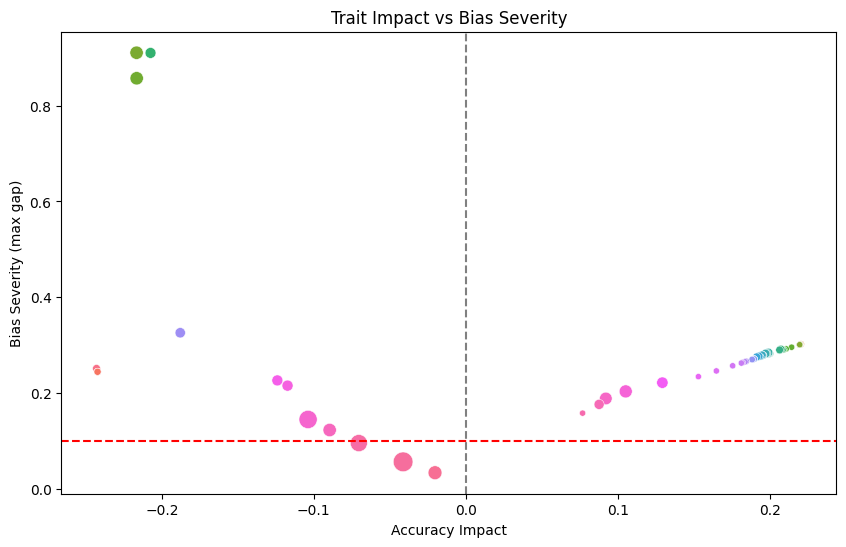

TRAIT OUTCOME DRIVER
🔎 Outcome Driver Analysis
We examine each trait/label to see how they relate to four possible outcomes:
  - TP: invasive correctly classified
  - TN: non-invasive correctly classified
  - FP: non-invasive misclassified as invasive (false alarm)
  - FN: invasive misclassified as non-invasive (missed invasive)
First, we compute simple fractions. Then, we fit logistic regression and random forest models.

📊 Top drivers of prediction outcomes (fraction-based, normalized):


,feature,n_with,n_without,TP_share,TN_share,FP_share,FN_share,max_driver
26,has_leaves opposite,60780,71348,0.512721,0.416180,0.477888,0.515791,0.515791
56,has_sessile,51059,81069,0.512721,0.281330,0.443824,0.515791,0.515791
1,has_alternate distally,24221,107907,0.445851,0.000000,0.010162,0.432662,0.445851
54,has_rounded at the base,24225,107903,0.445851,0.000057,0.010162,0.432662,0.445851
2,has_base attenuate,22821,109307,0.000000,0.281473,0.433233,0.000000,0.433233
5,has_becoming alternate distally,20929,111199,0.000000,0.255308,0.425791,0.000000,0.425791
11,has_erect,44067,88061,0.411501,0.267764,0.369543,0.415918,0.415918
14,has_floral tube cylindrical,24221,107907,0.248963,0.127512,0.223129,0.251112,0.251112



📝 Interpretation (fractions):
- Traits most linked to FALSE POSITIVES: has_leaves opposite, has_sessile, has_base attenuate (shares ~ 0.48, 0.44, 0.43).
- Traits most linked to FALSE NEGATIVES: has_leaves opposite, has_sessile, has_alternate distally (shares ~ 0.52, 0.52, 0.43).
- Traits most linked to correct invasive detection (TP): has_leaves opposite, has_sessile, has_alternate distally.
- Traits most linked to correct non-invasive detection (TN): has_leaves opposite, has_base attenuate, has_sessile.

📈 Logistic Regression Meta-Model (multinomial)
Top normalized coefficients (strongest drivers per outcome):


,FN,FP,TN,TP
4 minute petals,0.005418,0.004723,0.011664,0.005426
a discernible gap between the stem and the base of the blade,0.041280,0.035928,0.088153,0.040473
alternate distally,0.716538,0.115049,0.981441,0.712095
base attenuate,1.000000,0.657999,1.000000,1.000000
base narrowly attenuate,0.013736,0.003752,0.017640,0.013639
base obtuse to truncate,0.232885,0.491643,0.015725,0.240841
base rounded,0.053753,0.062725,0.128220,0.054547
becoming alternate distally,0.779596,1.000000,0.413024,0.779717



📝 Interpretation (logistic regression):
- Strongest predictors of TP: base attenuate, getting narrower at the base, becoming alternate distally
- Strongest predictors of TN: base attenuate, alternate distally, getting narrower at the base
- Strongest predictors of FP: becoming alternate distally, getting narrower at the base, base attenuate
- Strongest predictors of FN: base attenuate, getting narrower at the base, becoming alternate distally

🌲 Random Forest Meta-Model
Top feature importances:


,feature,importance
2,alternate distally,0.162932
64,rounded at the base,0.154439
84,with flowers in whorled clusters,0.066783
3,base attenuate,0.066629
7,becoming alternate distally,0.055464
66,sessile,0.053759
9,calyx with alternate long and small teeth,0.048859
23,getting narrower at the base,0.047704



📝 Interpretation (random forest):
- Traits with strongest overall predictive importance: alternate distally, rounded at the base, with flowers in whorled clusters, base attenuate, becoming alternate distally.

Outcome-specific feature importances (normalized per outcome):


,TP,TN,FP,FN
4 minute petals,0.000040,0.000059,0.000030,0.000033
a discernible gap between the stem and the base of the blade,0.003621,0.005030,0.004146,0.004531
alternate distally,1.000000,1.000000,0.239894,1.000000
base attenuate,0.505533,0.378220,0.730070,0.490735
base narrowly attenuate,0.000104,0.000094,0.000450,0.000059
base obtuse to truncate,0.053947,0.076577,0.010558,0.050199
base rounded,0.003062,0.005675,0.003837,0.003041
becoming alternate distally,0.372754,0.267073,1.000000,0.387122



📝 Interpretation (random forest outcome-specific):
- Strongest predictors of TP: alternate distally, rounded at the base, base attenuate
- Strongest predictors of TN: alternate distally, rounded at the base, with flowers in whorled clusters
- Strongest predictors of FP: becoming alternate distally, base attenuate, stamens 6
- Strongest predictors of FN: alternate distally, rounded at the base, base attenuate


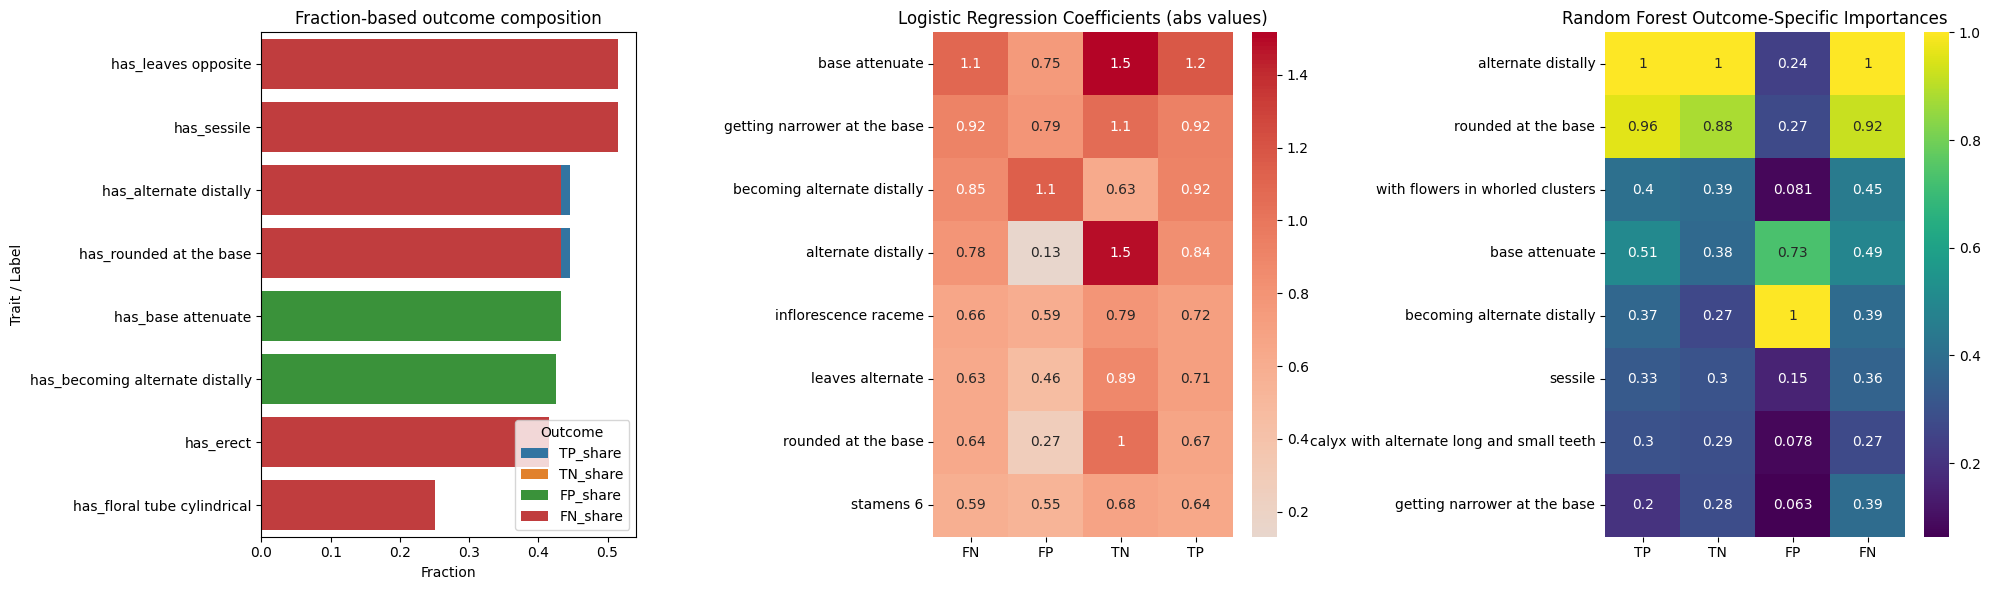

POLARIZING TRAIT ANALYSIS (TP/TN/FP/FN Shifts)
POLARIZING TRAIT ANALYSIS
Analyzing traits with at least 10 samples to detect TP/TN/FP/FN shifts.

Most polarizing trait: 'getting narrower at the base' with asymmetry score 0.352
  - TP change: +0.000, TN change: +0.000
  - FP change: +0.298, FN change: -0.055
Interpretation: This trait strongly shifts predictions: its effect aligns with overall accuracy (mostly helps or hurts consistently).
                                        trait  tp_change  tn_change  \
21               getting narrower at the base        0.0        0.0   
66                              stamens 10-14        0.0        0.0   
48                      petals rose to purple        0.0        0.0   
24          inflorescence spikelike to raceme        0.0        0.0   
1                          alternate distally        0.0        0.0   
57                        rounded at the base        0.0        0.0   
75           with flowers in whorled clusters        0.0    

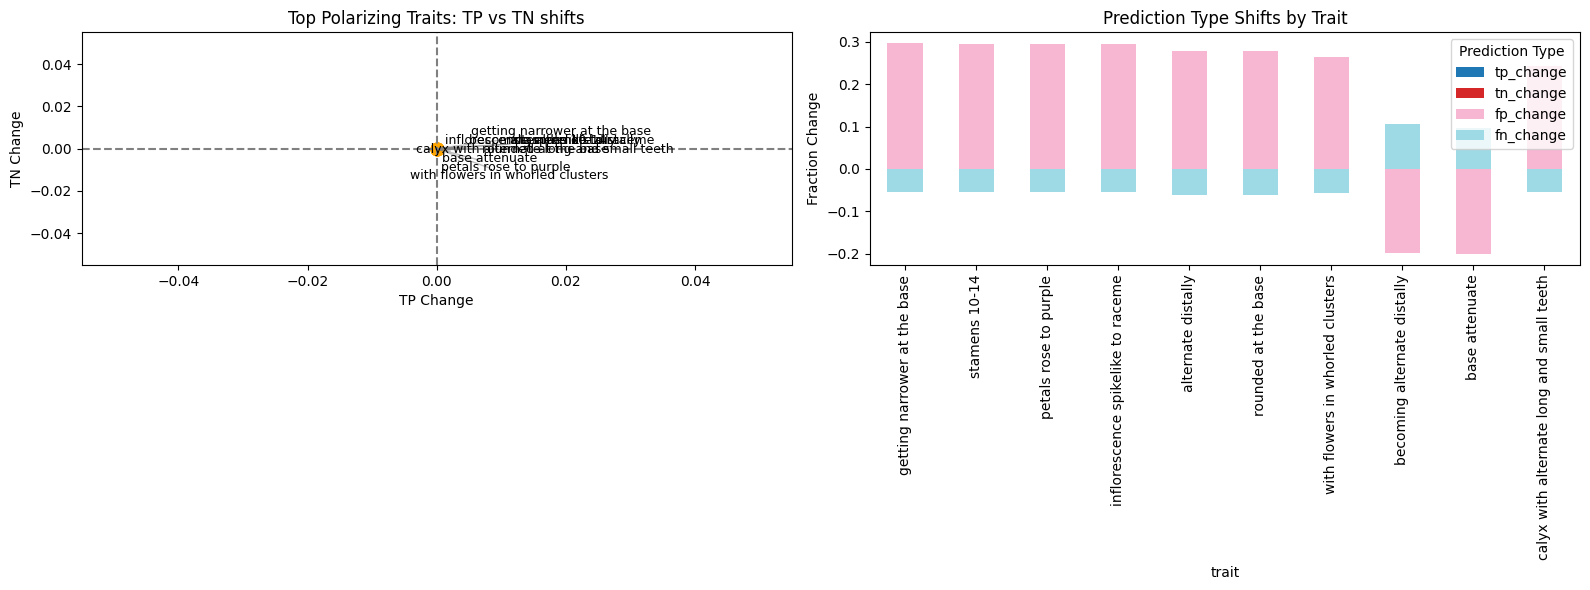

ANNOTATION LABEL IMPACT
ANNOTATION LABEL IMPACT ANALYSIS
This analyzes how annotation quality affects model performance

1. 'HAND' LABEL IMPACT:
   (shows counts including missing values and performance metrics per value)

   Value counts (including Missing):
     Missing      n=120,493 (91.2%)
     1.0          n=11,635 (8.8%)

   Results by 'HAND' Label Value:
     1.0         : Acc=0.778, Prec=0.758, Rec=0.908 (n=11,635 samples)
     Missing     : Acc=0.781, Prec=0.762, Rec=0.910 (n=120,493 samples)

   Accuracy difference (1.0 vs Missing): -0.003

   Statistical test: Chi-square => NOT significant (p=0.5962)

2. 'BACKGROUND/UNDEFINED' LABEL IMPACT:
   (shows counts including missing values and performance metrics per value)

   Value counts (including Missing):
     Missing      n=93,769 (71.0%)
     1.0          n=38,359 (29.0%)

   Results by 'BACKGROUND/UNDEFINED' Label Value:
     1.0         : Acc=0.782, Prec=0.764, Rec=0.909 (n=38,359 samples)
     Missing     : Acc=0.780, Pr

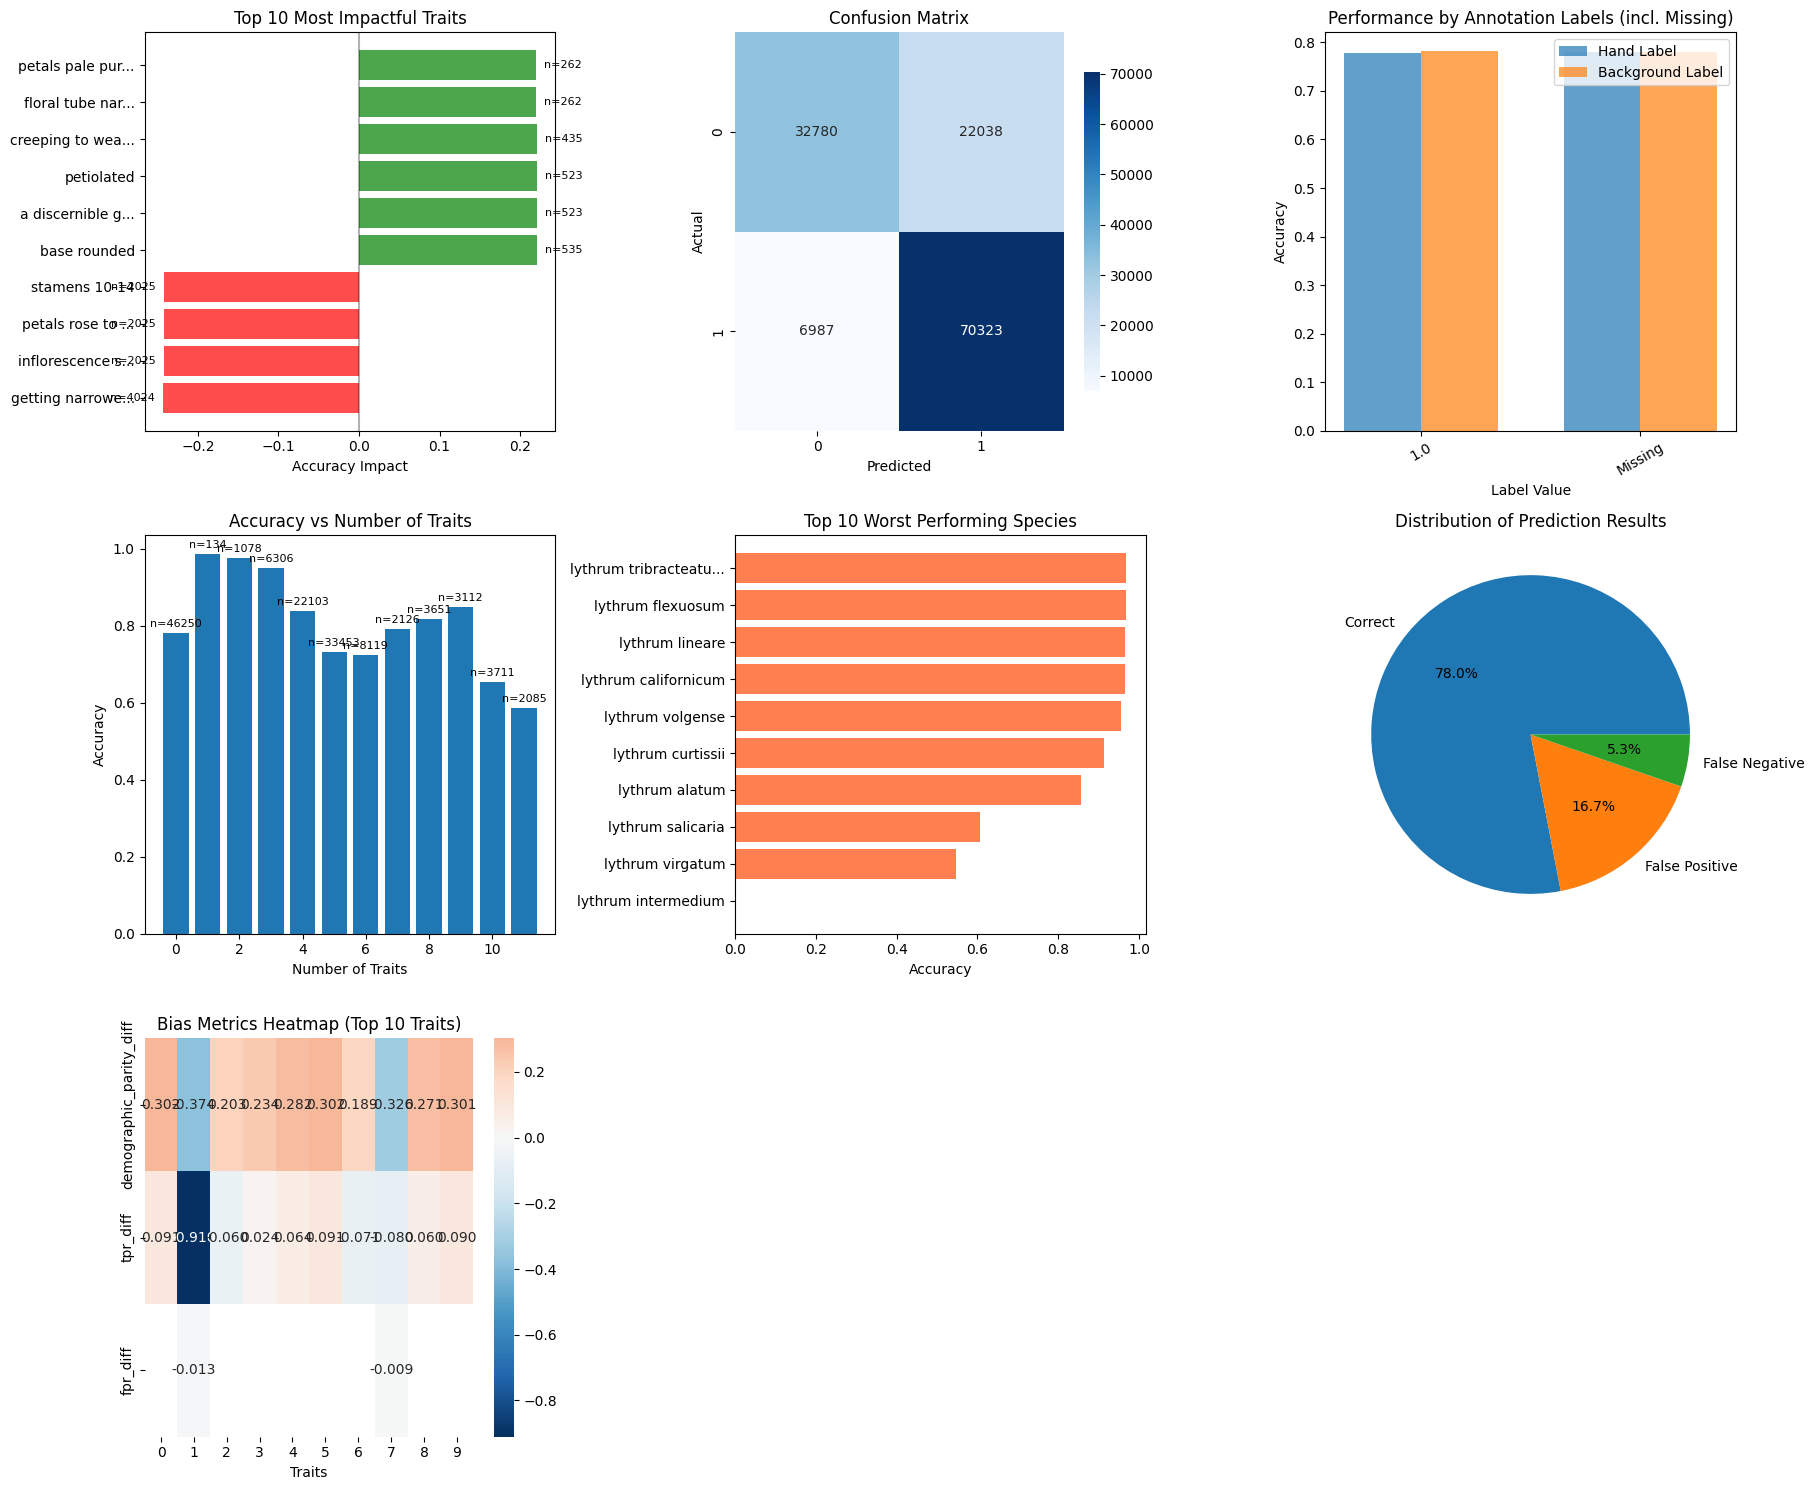

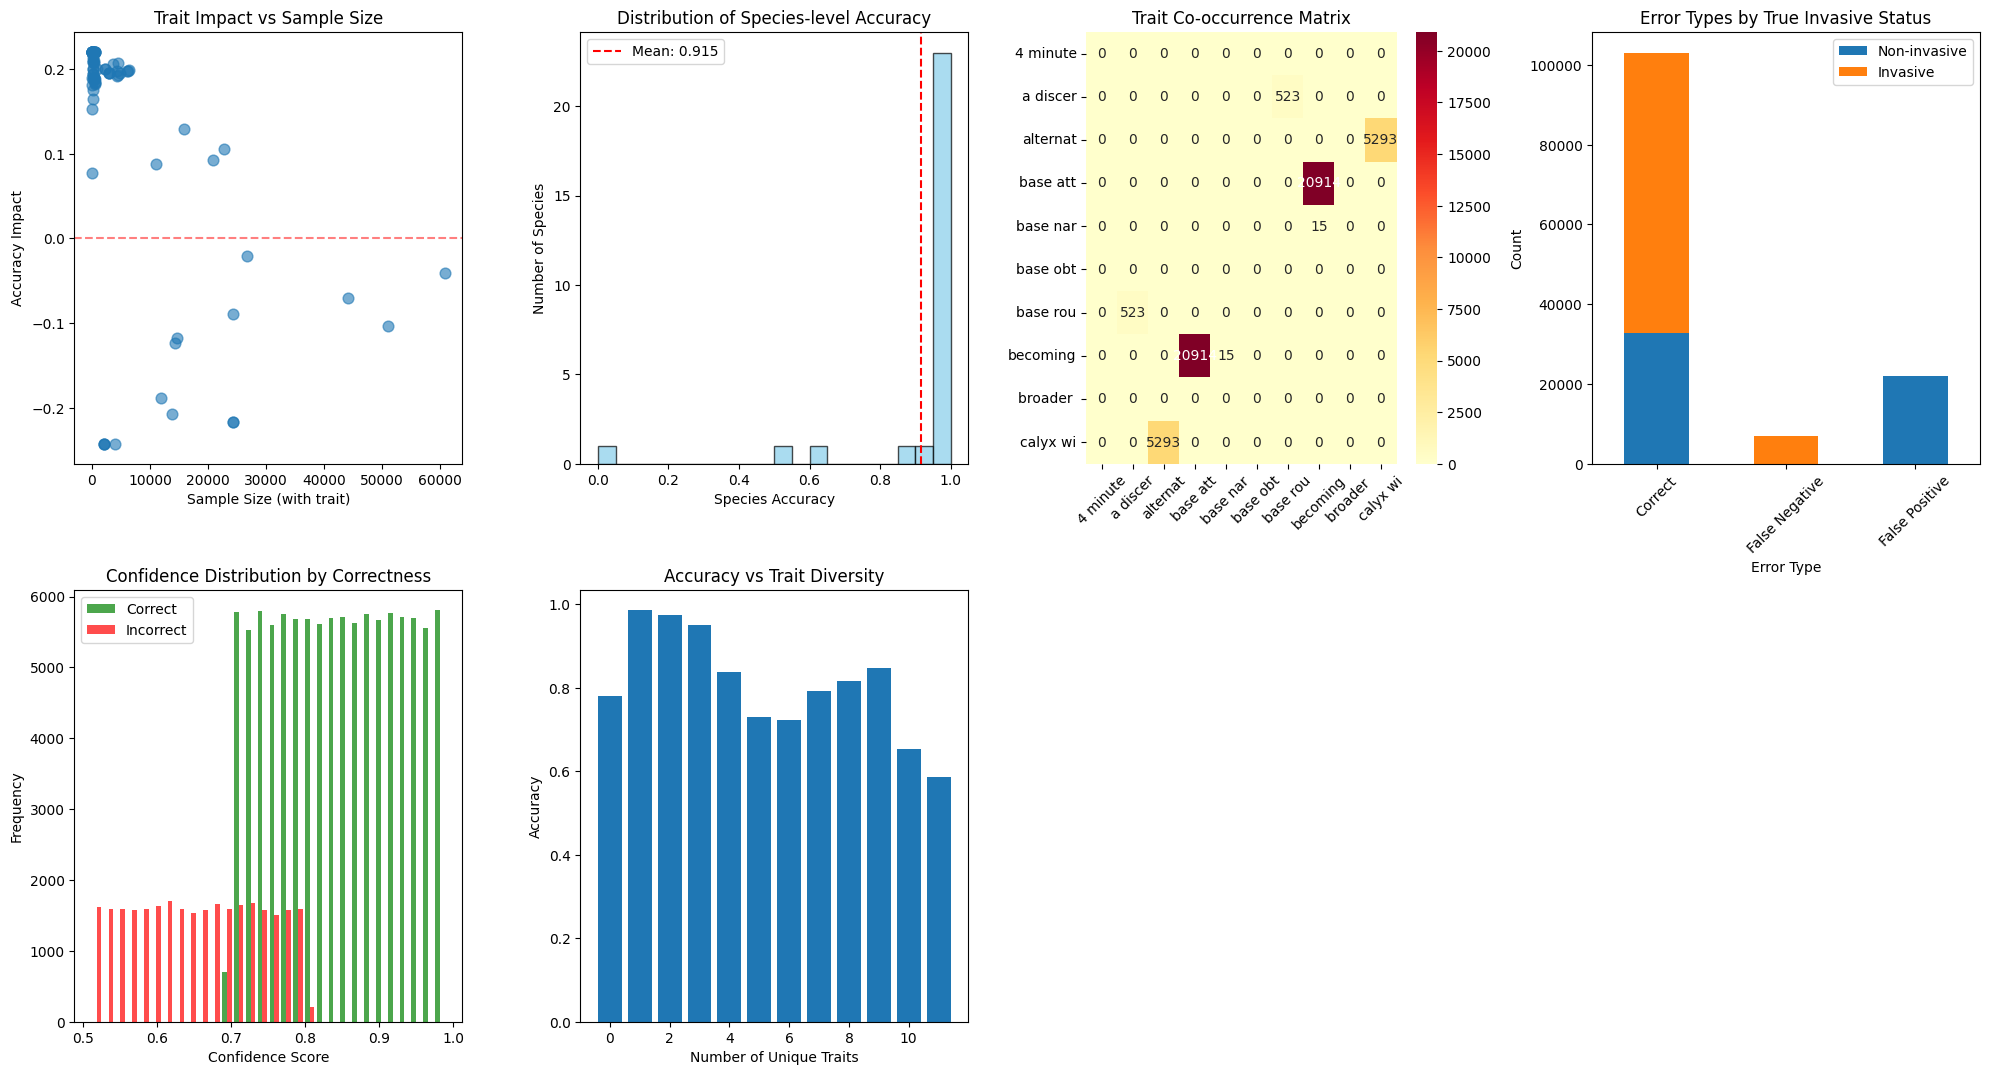

ANALYSIS COMPLETE


In [153]:
analyzer = ImprovedPlantModelAnalyzer(merged_df)

results = analyzer.comprehensive_summary_report()

for key, value in results.items():
    if hasattr(value, 'to_csv'):
        value.to_csv(f'regions_results/{key}.csv', index=False)


# Passing to the Image level

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class EnhancedImageLevelAnalyzer:
    def __init__(self, df):
        """
        df = region-level dataframe with columns:
        ['filename','obs_id','group','y_true','y_pred',
         'hand','background/undefined','characteristic_traits']
        """
        self.df_regions = df.copy()
        self.df_images = self._aggregate_to_image_level()
        self._prepare_analysis_columns()
        
        # Fill NaN values for trait columns
        for col in self.trait_cols_present:
            self.df_images[col] = self.df_images[col].fillna(0).astype(int)
    
    # ---------------- AGGREGATE TO IMAGE LEVEL ----------------
    def _aggregate_to_image_level(self):
        df = self.df_regions.copy()

        def parse_traits(x):
            if isinstance(x, float) and np.isnan(x):
                return []
            elif isinstance(x, (list, np.ndarray)):
                return [str(t).strip() for t in x]
            else:
                return [str(x).strip()]
        
        df['traits_list'] = df['characteristic_traits'].apply(parse_traits)

        grouped = []
        for obs_id, g in df.groupby('obs_id'):
            row = {}
            row['obs_id'] = obs_id
            row['group'] = g['group'].mode()[0]  # representative group
            row['n_regions'] = len(g)
            row['y_true'] = g['y_true'].mode()[0]
            row['y_pred'] = g['y_pred'].mode()[0]
            row['correct_prediction'] = int(row['y_true'] == row['y_pred'])
            
            if row['y_true'] == row['y_pred']:
                row['correct_prediction'] = 1
                row['error_type'] = 'True Positive' if row['y_true'] == 1 else 'True Negative'
            else:
                row['correct_prediction'] = 0
                row['error_type'] = 'False Positive' if row['y_pred'] == 1 else 'False Negative'

            row['hand_frac'] = g['hand'].fillna(0).mean()
            row['background_frac'] = g['background/undefined'].fillna(0).mean()
            
            # NEW: Count absolute numbers of regions with each label
            row['hand_count'] = g['hand'].fillna(0).sum()
            row['background_count'] = g['background/undefined'].fillna(0).sum()

            trait_counts = Counter([t for traits in g['traits_list'] for t in traits])
            total_regions = len(g)
            for trait, count in trait_counts.items():
                row[f'trait_{trait}_present'] = 1
                row[f'trait_{trait}_freq'] = count / total_regions
                row[f'trait_{trait}_count'] = count  # NEW: absolute count
            
            grouped.append(row)

        return pd.DataFrame(grouped)
    
    # ---------------- PREPARE ANALYSIS COLUMNS ----------------
    def _prepare_analysis_columns(self):
        # Identify all traits
        self.trait_cols_present = [c for c in self.df_images.columns if c.endswith('_present')]
        self.trait_cols_freq = [c for c in self.df_images.columns if c.endswith('_freq')]
        self.trait_cols_count = [c for c in self.df_images.columns if c.endswith('_count') and c.startswith('trait_')]
        
        # Create numeric error indicators
        self.df_images['error_numeric'] = self.df_images['error_type'].map({
            'True Positive': 0, 
            'True Negative': 1, 
            'False Positive': 2, 
            'False Negative': 3
        })        
        
        # Number of traits per image
        self.df_images['num_traits'] = self.df_images[self.trait_cols_present].sum(axis=1)
        
        # NEW: Trait diversity metrics
        self.df_images['trait_diversity'] = self.df_images[self.trait_cols_present].sum(axis=1)
        self.df_images['total_trait_regions'] = self.df_images[self.trait_cols_count].sum(axis=1)
        self.df_images['trait_density'] = self.df_images['total_trait_regions'] / self.df_images['n_regions']
        
        # NEW: Prediction confidence proxy (based on region consensus)
        self.df_images['region_consensus'] = np.where(
            self.df_images['n_regions'] == 1, 1.0,  # Single region = full consensus
            1.0 - (self.df_images['n_regions'] - 1) * 0.05  # Penalize more regions
        ).clip(0, 1)

    # ---------------- PERFORMANCE SUMMARY ----------------
    def summary_performance(self):
        total = len(self.df_images)
        acc = self.df_images['correct_prediction'].mean()
        tp_count = (self.df_images['error_type']=='True Positive').sum()
        tn_count = (self.df_images['error_type']=='True Negative').sum()
        fp_count = (self.df_images['error_type']=='False Positive').sum()
        fn_count = (self.df_images['error_type']=='False Negative').sum()

        print("="*60)
        print("IMAGE-LEVEL PERFORMANCE SUMMARY")
        print("="*60)
        print(f"Overall Accuracy: {acc:.3f} (n={total})")
        print(f"True Positives: {tp_count}")
        print(f"True Negatives: {tn_count}")
        print(f"False Positives: {fp_count}")
        print(f"False Negatives: {fn_count}")
        
        # Calculate additional metrics
        precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0
        recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"Precision: {precision:.3f}")
        print(f"Recall: {recall:.3f}")
        print(f"F1-Score: {f1:.3f}")
        print("Error type counts:")
        print(self.df_images['error_type'].value_counts())
        print()
        return acc
    
    # ---------------- NEW: SPECIES-LEVEL ANALYSIS ----------------
    def species_performance_analysis(self):
        """Analyze model performance by species (group)"""
        print("="*60)
        print("SPECIES-LEVEL PERFORMANCE ANALYSIS")
        print("="*60)
        
        species_stats = []
        for species in self.df_images['group'].unique():
            df_species = self.df_images[self.df_images['group'] == species]
            stats_row = {
                'species': species,
                'n_images': len(df_species),
                'accuracy': df_species['correct_prediction'].mean(),
                'tp_rate': (df_species['error_type']=='True Positive').mean(),
                'tn_rate': (df_species['error_type']=='True Negative').mean(),
                'fp_rate': (df_species['error_type']=='False Positive').mean(),
                'fn_rate': (df_species['error_type']=='False Negative').mean(),
                'avg_regions': df_species['n_regions'].mean(),
                'avg_trait_diversity': df_species['trait_diversity'].mean(),
                'invasive_ratio': df_species['y_true'].mean()
            }
            species_stats.append(stats_row)
        
        species_df = pd.DataFrame(species_stats).sort_values('accuracy', ascending=False)
        print(species_df.head(15))
        
        # Statistical test for performance differences
        species_accuracies = [self.df_images[self.df_images['group']==sp]['correct_prediction'].values 
                            for sp in self.df_images['group'].unique()]
        try:
            f_stat, p_val = stats.f_oneway(*species_accuracies)
            print(f"\nANOVA test for species accuracy differences: F={f_stat:.3f}, p={p_val:.4f}")
            if p_val < 0.05:
                print("SIGNIFICANT differences in accuracy between species")
            else:
                print("NO significant differences in accuracy between species")
        except:
            print("Could not perform ANOVA test")
            
        return species_df
    
    # ---------------- NEW: TRAIT INTENSITY ANALYSIS ----------------
    def trait_intensity_analysis(self, min_images=10):
        """Analyze how trait frequency/count affects performance"""
        print("="*60)
        print("TRAIT INTENSITY ANALYSIS (Frequency vs Count Effects)")
        print("="*60)
        
        intensity_results = []
        
        for trait_base in set([col.replace('trait_','').replace('_present','') 
                              for col in self.trait_cols_present]):
            present_col = f'trait_{trait_base}_present'
            freq_col = f'trait_{trait_base}_freq'
            count_col = f'trait_{trait_base}_count'
            
            if (present_col in self.df_images.columns and 
                freq_col in self.df_images.columns and 
                count_col in self.df_images.columns):
                
                df_with_trait = self.df_images[self.df_images[present_col] == 1]
                if len(df_with_trait) < min_images:
                    continue
                
                # Correlation between trait intensity and accuracy
                freq_corr = df_with_trait[freq_col].corr(df_with_trait['correct_prediction'])
                count_corr = df_with_trait[count_col].corr(df_with_trait['correct_prediction'])
                
                # Performance by intensity quartiles
                freq_q1, freq_q3 = df_with_trait[freq_col].quantile([0.25, 0.75])
                count_q1, count_q3 = df_with_trait[count_col].quantile([0.25, 0.75])
                
                low_freq_acc = df_with_trait[df_with_trait[freq_col] <= freq_q1]['correct_prediction'].mean()
                high_freq_acc = df_with_trait[df_with_trait[freq_col] >= freq_q3]['correct_prediction'].mean()
                
                low_count_acc = df_with_trait[df_with_trait[count_col] <= count_q1]['correct_prediction'].mean()
                high_count_acc = df_with_trait[df_with_trait[count_col] >= count_q3]['correct_prediction'].mean()
                
                intensity_results.append({
                    'trait': trait_base,
                    'n_images': len(df_with_trait),
                    'freq_corr': freq_corr,
                    'count_corr': count_corr,
                    'low_freq_acc': low_freq_acc,
                    'high_freq_acc': high_freq_acc,
                    'freq_effect': high_freq_acc - low_freq_acc,
                    'low_count_acc': low_count_acc,
                    'high_count_acc': high_count_acc,
                    'count_effect': high_count_acc - low_count_acc
                })
        
        intensity_df = pd.DataFrame(intensity_results).sort_values('freq_effect', key=abs, ascending=False)
        print(intensity_df.head(10))
        return intensity_df
    
    # ---------------- NEW: REGION COMPLEXITY ANALYSIS ----------------
    def region_complexity_analysis(self):
        """Analyze how image complexity (number of regions) affects performance"""
        print("="*60)
        print("IMAGE COMPLEXITY ANALYSIS")
        print("="*60)
        
        # Binning regions into complexity categories
        self.df_images['complexity_category'] = pd.cut(
            self.df_images['n_regions'], 
            bins=[0, 1, 3, 5, 10, float('inf')], 
            labels=['Simple(1)', 'Low(2-3)', 'Medium(4-5)', 'High(6-10)', 'Very High(10+)']
        )
        
        complexity_stats = self.df_images.groupby('complexity_category').agg({
            'obs_id': 'count',
            'correct_prediction': 'mean',
            'trait_diversity': 'mean',
            'trait_density': 'mean',
            'hand_frac': 'mean',
            'background_frac': 'mean'
        }).round(3)
        complexity_stats.columns = ['n_images', 'accuracy', 'avg_trait_diversity', 
                                   'avg_trait_density', 'avg_hand_frac', 'avg_background_frac']
        
        print(complexity_stats)
        
        # Statistical test
        complexity_groups = [self.df_images[self.df_images['complexity_category']==cat]['correct_prediction'].values 
                           for cat in self.df_images['complexity_category'].unique() if pd.notna(cat)]
        try:
            f_stat, p_val = stats.f_oneway(*complexity_groups)
            print(f"\nANOVA test for complexity effects: F={f_stat:.3f}, p={p_val:.4f}")
        except:
            print("Could not perform complexity ANOVA")
            
        return complexity_stats
    
    # ---------------- NEW: PREDICTIVE FEATURE IMPORTANCE ----------------
    def predictive_feature_analysis(self):
        """Use Random Forest to identify most predictive features for model errors"""
        print("="*60)
        print("PREDICTIVE FEATURE IMPORTANCE ANALYSIS")
        print("="*60)
        
        # Prepare features
        feature_cols = (self.trait_cols_present + self.trait_cols_freq + 
                       ['n_regions', 'trait_diversity', 'trait_density', 
                        'hand_frac', 'background_frac'])
        
        X = self.df_images[feature_cols].fillna(0)
        y = self.df_images['correct_prediction']
        
        # Random Forest for feature importance
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("Top 15 Predictive Features:")
        print(feature_importance.head(15))
        
        # Cross-validation score
        cv_scores = cross_val_score(rf, X, y, cv=5)
        print(f"\nRandom Forest CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
        
        return feature_importance
    
    # ---------------- NEW: ERROR PATTERN CLUSTERING ----------------
    def error_pattern_analysis(self):
        """Deep dive into error patterns"""
        print("="*60)
        print("ERROR PATTERN ANALYSIS")
        print("="*60)
        
        error_patterns = {}
        
        # Analyze False Positives
        fp_images = self.df_images[self.df_images['error_type'] == 'False Positive']
        if len(fp_images) > 0:
            fp_traits = fp_images[self.trait_cols_present].mean().sort_values(ascending=False)
            error_patterns['False Positive'] = {
                'count': len(fp_images),
                'top_traits': fp_traits.head(5).to_dict(),
                'avg_regions': fp_images['n_regions'].mean(),
                'avg_trait_diversity': fp_images['trait_diversity'].mean()
            }
        
        # Analyze False Negatives
        fn_images = self.df_images[self.df_images['error_type'] == 'False Negative']
        if len(fn_images) > 0:
            fn_traits = fn_images[self.trait_cols_present].mean().sort_values(ascending=False)
            error_patterns['False Negative'] = {
                'count': len(fn_images),
                'top_traits': fn_traits.head(5).to_dict(),
                'avg_regions': fn_images['n_regions'].mean(),
                'avg_trait_diversity': fn_images['trait_diversity'].mean()
            }
        
        # Compare error patterns
        for error_type, pattern in error_patterns.items():
            print(f"\n{error_type} Pattern (n={pattern['count']}):")
            print(f"  Average regions: {pattern['avg_regions']:.1f}")
            print(f"  Average trait diversity: {pattern['avg_trait_diversity']:.1f}")
            print("  Top traits:")
            for trait, freq in pattern['top_traits'].items():
                clean_trait = trait.replace('trait_','').replace('_present','')
                print(f"    {clean_trait}: {freq:.3f}")
        
        return error_patterns
    
    # ---------------- ENHANCED PLOTTING ----------------
    def create_interactive_dashboard(self):
        """Create an interactive Plotly dashboard"""
        # This would create multiple subplots with interactive features
        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=['Trait Impact on Accuracy', 'Species Performance', 
                          'Complexity vs Accuracy', 'Error Distribution by Traits',
                          'Trait Frequency Distribution', 'Prediction Confidence'],
            specs=[[{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"secondary_y": False}],
                   [{"secondary_y": False}, {"secondary_y": False}]]
        )
        
        # Add plots (simplified version - you can expand this)
        trait_impact = self.trait_impact().head(10)
        
        fig.add_trace(
            go.Bar(x=trait_impact['trait'], y=trait_impact['impact'], name='Trait Impact'),
            row=1, col=1
        )
        
        # Add more traces...
        
        fig.update_layout(height=1200, showlegend=False, title="Plant Classification Analysis Dashboard")
        return fig
    
    # ---------------- EXISTING METHODS (keeping your original code) ----------------
    def analyze_annotation_labels(self):
        print("="*60)
        print("ANNOTATION LABEL IMPACT (image-level)")
        print("="*60)
        
        for col, pretty in [('hand_frac','Hand'),('background_frac','Background')]:
            print(f"\nImpact of {pretty} label:")
            has_label = self.df_images[col] > 0
            df_with = self.df_images[has_label]
            df_without = self.df_images[~has_label]

            acc_with = df_with['correct_prediction'].mean()
            acc_without = df_without['correct_prediction'].mean()

            tp_with = (df_with['error_type']=='True Positive').mean()
            tn_with = (df_with['error_type']=='True Negative').mean()
            tp_without = (df_without['error_type']=='True Positive').mean()
            tn_without = (df_without['error_type']=='True Negative').mean()

            print(f"  With {pretty}:   Acc={acc_with:.3f}, TP={tp_with:.3f}, TN={tn_with:.3f} (n={len(df_with)})")
            print(f"  Without {pretty}: Acc={acc_without:.3f}, TP={tp_without:.3f}, TN={tn_without:.3f} (n={len(df_without)})")
            print(f"  Difference: {acc_with-acc_without:+.3f}")

            contingency = pd.crosstab(has_label, self.df_images['correct_prediction'])
            if contingency.shape == (2,2):
                chi2, p, _, _ = stats.chi2_contingency(contingency)
                signif = "SIGNIFICANT" if p<0.05 else "NOT significant"
                print(f"  Chi-square test: {signif} (p={p:.4f})")
            else:
                print("  Test not run (imbalanced groups).")
        print()

    def trait_impact(self, min_images=10):
        results = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            n_images = self.df_images[col].sum()
            if n_images >= min_images:
                df_with = self.df_images[self.df_images[col]==1]
                df_without = self.df_images[self.df_images[col]==0]

                acc_with = df_with['correct_prediction'].mean()
                acc_without = df_without['correct_prediction'].mean()

                tp_with = (df_with['error_type']=='True Positive').mean()
                tn_with = (df_with['error_type']=='True Negative').mean()
                tp_without = (df_without['error_type']=='True Positive').mean()
                tn_without = (df_without['error_type']=='True Negative').mean()

                diff = acc_with - acc_without

                contingency = pd.crosstab(self.df_images[col], self.df_images['correct_prediction'])
                if contingency.shape == (2,2):
                    chi2, p, _, _ = stats.chi2_contingency(contingency)
                else:
                    p = 1.0

                results.append({
                    'trait': trait_name,
                    'n_images': n_images,
                    'acc_with': acc_with,
                    'acc_without': acc_without,
                    'tp_with': tp_with,
                    'tn_with': tn_with,
                    'tp_without': tp_without,
                    'tn_without': tn_without,
                    'impact': diff,
                    'p_value': p,
                    'significant': 'Yes' if p<0.05 else 'No'
                })
        return pd.DataFrame(results).sort_values('impact', key=abs, ascending=False)

    def trait_combination_analysis(self, min_images=5):
        self.df_images['trait_combo'] = self.df_images[self.trait_cols_present].apply(
            lambda row: ', '.join([c.replace('trait_','').replace('_present','') 
                                   for c,v in row.items() if v==1]) if row.sum()>0 else 'No Traits',
            axis=1
        )
        combo_stats = self.df_images.groupby('trait_combo').agg(
            sample_size=('obs_id','count'),
            accuracy=('correct_prediction','mean')
        ).sort_values('accuracy', ascending=False)
        return combo_stats[combo_stats['sample_size']>=min_images]

    def trait_prediction_pattern_analysis(self, min_images=50):
        """Detect traits that have contrasting effects on TP/TN/FP/FN"""
        records = []
        for col in self.trait_cols_present:
            trait = col.replace('trait_','').replace('_present','')
            n_images = self.df_images[col].sum()
            if n_images < min_images:
                continue

            df_with = self.df_images[self.df_images[col]==1]
            df_without = self.df_images[self.df_images[col]==0]

            # Calculate TP/TN/FP/FN fractions
            tp_with = (df_with['error_type']=='True Positive').mean()
            tn_with = (df_with['error_type']=='True Negative').mean()
            fp_with = (df_with['error_type']=='False Positive').mean()
            fn_with = (df_with['error_type']=='False Negative').mean()

            tp_without = (df_without['error_type']=='True Positive').mean()
            tn_without = (df_without['error_type']=='True Negative').mean()
            fp_without = (df_without['error_type']=='False Positive').mean()
            fn_without = (df_without['error_type']=='False Negative').mean()

            # Changes
            tp_change = tp_with - tp_without
            tn_change = tn_with - tn_without
            fp_change = fp_with - fp_without
            fn_change = fn_with - fn_without

            # Asymmetry score: large directional effect
            asymmetry = abs(tp_change) + abs(tn_change) + abs(fp_change) + abs(fn_change)
            pattern_type = 'polarizing' if tp_change * tn_change < 0 else 'aligned'

            # Chi-square significance for TP/TN shifts
            contingency = pd.DataFrame([
                [ (df_with['error_type']=='True Positive').sum(), (df_without['error_type']=='True Positive').sum() ],
                [ (df_with['error_type']=='True Negative').sum(), (df_without['error_type']=='True Negative').sum() ]
            ])
            try:
                chi2, p, _, _ = stats.chi2_contingency(contingency)
            except:
                p = 1.0

            records.append({
                'trait': trait,
                'n_images': n_images,
                'tp_change': tp_change,
                'tn_change': tn_change,
                'fp_change': fp_change,
                'fn_change': fn_change,
                'asymmetry_score': asymmetry,
                'pattern_type': pattern_type,
                'p_value': p
            })

        df_patterns = pd.DataFrame(records).sort_values('asymmetry_score', ascending=False)
        return df_patterns

    def plot_trait_prediction_patterns(self, top_n=20):
        """Scatter and bar plots for top polarizing traits"""
        df_patterns = self.trait_prediction_pattern_analysis()
        top_traits = df_patterns.head(top_n)

        plt.style.use('default')
        fig, axes = plt.subplots(1,2, figsize=(16,6))

        # Scatter TP_change vs TN_change
        axes[0].scatter(top_traits['tp_change'], top_traits['tn_change'],
                        s=100, c='orange', alpha=0.7)
        for i, row in top_traits.iterrows():
            axes[0].text(row['tp_change'], row['tn_change'], row['trait'], fontsize=9)
        axes[0].axhline(0, color='gray', linestyle='--')
        axes[0].axvline(0, color='gray', linestyle='--')
        axes[0].set_xlabel('TP Change (with trait - without trait)')
        axes[0].set_ylabel('TN Change (with trait - without trait)')
        axes[0].set_title('Top Polarizing Traits: TP vs TN shifts')

        # Bar plot for TP/TN/FP/FN changes
        top_traits_plot = top_traits.set_index('trait')[['tp_change','tn_change','fp_change','fn_change']]
        top_traits_plot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
        axes[1].set_ylabel('Fraction Change')
        axes[1].set_title('Prediction Type Shifts by Trait')
        axes[1].legend(title='Prediction Type')
        plt.tight_layout()
        plt.show()

    def trait_combination_polarization(self, min_images=20):
        """Identify combinations of traits that have polarizing effects on TP/TN"""
        combo_records = []
        for r in range(2,4):  # pairs and triples
            for combo in combinations(self.trait_cols_present, r):
                df_combo = self.df_images[(self.df_images[list(combo)]==1).all(axis=1)]
                if len(df_combo) < min_images:
                    continue
                tp_frac = (df_combo['error_type']=='True Positive').mean()
                tn_frac = (df_combo['error_type']=='True Negative').mean()
                fp_frac = (df_combo['error_type']=='False Positive').mean()
                fn_frac = (df_combo['error_type']=='False Negative').mean()
                asymmetry = abs(tp_frac - tn_frac) + abs(fp_frac - fn_frac)
                combo_records.append({
                    'trait_combo': ', '.join([c.replace('trait_','').replace('_present','') for c in combo]),
                    'n_images': len(df_combo),
                    'tp_frac': tp_frac,
                    'tn_frac': tn_frac,
                    'fp_frac': fp_frac,
                    'fn_frac': fn_frac,
                    'asymmetry_score': asymmetry
                })

        df_combo = pd.DataFrame(combo_records).sort_values('asymmetry_score', ascending=False)
        return df_combo.head(20)

    def plot_readable_visualizations(self, top_n_traits=10):
        plt.style.use('default')
        fig = plt.figure(figsize=(18,12))

        # 1. Top impactful traits
        trait_df = self.trait_impact()
        top_traits = trait_df.head(top_n_traits)
        colors = ['green' if x>0 else 'red' for x in top_traits['impact']]
        plt.subplot(2,3,1)
        plt.barh(top_traits['trait'], top_traits['impact'], color=colors)
        plt.xlabel('Accuracy Impact')
        plt.title(f'Top {top_n_traits} Most Impactful Traits')

        # 2. Accuracy by number of traits
        plt.subplot(2,3,2)
        num_traits_acc = self.df_images.groupby('num_traits')['correct_prediction'].mean()
        plt.bar(num_traits_acc.index, num_traits_acc.values)
        plt.xlabel('Number of Traits per Image')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')

        # 3. Region count distribution
        plt.subplot(2,3,3)
        self.df_images['n_regions'].hist(bins=20)
        plt.xlabel('Number of Regions per Image')
        plt.ylabel('Image Count')
        plt.title('Distribution of Region Counts per Image')

        # 4. Accuracy vs region counts
        plt.subplot(2,3,4)
        acc_by_regions = self.df_images.groupby('n_regions')['correct_prediction'].mean()
        plt.plot(acc_by_regions.index, acc_by_regions.values, marker='o')
        plt.xlabel('Number of Regions')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Regions')

        # 5. Confusion matrix
        plt.subplot(2,3,5)
        cm = confusion_matrix(self.df_images['y_true'], self.df_images['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')

        # 6. Error type pie chart
        plt.subplot(2,3,6)
        counts = self.df_images['error_type'].value_counts()
        colors = {
            'True Positive':'green', 'True Negative':'blue',
            'False Positive':'red','False Negative':'orange'
        }
        plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=[colors.get(x,'gray') for x in counts.index])
        plt.title('Error Type Distribution')
        
        plt.tight_layout()
        plt.show()

    # ---------------- NEW: ADVANCED TRAIT INTERACTION ANALYSIS ----------------
    def trait_interaction_matrix(self, min_images=20):
        """Analyze interactions between different traits"""
        print("="*60)
        print("TRAIT INTERACTION ANALYSIS")
        print("="*60)
        
        interaction_results = []
        trait_names = [col.replace('trait_','').replace('_present','') for col in self.trait_cols_present]
        
        for i, trait1 in enumerate(self.trait_cols_present):
            for j, trait2 in enumerate(self.trait_cols_present[i+1:], i+1):
                # Images with both traits
                both_traits = self.df_images[(self.df_images[trait1]==1) & (self.df_images[trait2]==1)]
                # Images with only trait1
                only_trait1 = self.df_images[(self.df_images[trait1]==1) & (self.df_images[trait2]==0)]
                # Images with only trait2
                only_trait2 = self.df_images[(self.df_images[trait1]==0) & (self.df_images[trait2]==1)]
                # Images with neither
                neither = self.df_images[(self.df_images[trait1]==0) & (self.df_images[trait2]==0)]
                
                if len(both_traits) >= min_images:
                    # Calculate interaction effect
                    acc_both = both_traits['correct_prediction'].mean()
                    acc_trait1 = only_trait1['correct_prediction'].mean() if len(only_trait1) > 0 else 0
                    acc_trait2 = only_trait2['correct_prediction'].mean() if len(only_trait2) > 0 else 0
                    acc_neither = neither['correct_prediction'].mean() if len(neither) > 0 else 0
                    
                    # Synergy score: how much better/worse is the combination compared to individual effects
                    expected_combined = (acc_trait1 + acc_trait2) / 2 if (acc_trait1 > 0 and acc_trait2 > 0) else max(acc_trait1, acc_trait2)
                    synergy = acc_both - expected_combined
                    
                    interaction_results.append({
                        'trait1': trait_names[i],
                        'trait2': trait_names[j],
                        'n_both': len(both_traits),
                        'acc_both': acc_both,
                        'acc_trait1_only': acc_trait1,
                        'acc_trait2_only': acc_trait2,
                        'acc_neither': acc_neither,
                        'synergy_score': synergy,
                        'interaction_type': 'Synergistic' if synergy > 0.05 else ('Antagonistic' if synergy < -0.05 else 'Neutral')
                    })
        
        interaction_df = pd.DataFrame(interaction_results).sort_values('synergy_score', key=abs, ascending=False)
        print("Top Trait Interactions:")
        print(interaction_df.head(15))
        return interaction_df
    
    # ---------------- NEW: TEMPORAL/SEQUENTIAL ANALYSIS ----------------
    def trait_sequence_patterns(self):
        """Analyze if certain traits appear together in specific patterns"""
        print("="*60)
        print("TRAIT CO-OCCURRENCE PATTERNS")
        print("="*60)
        
        # Create co-occurrence matrix
        trait_matrix = self.df_images[self.trait_cols_present].astype(int)
        cooccurrence = trait_matrix.T.dot(trait_matrix)
        
        # Normalize by total images with each trait
        trait_counts = trait_matrix.sum(axis=0)
        normalized_cooccurrence = cooccurrence.div(trait_counts, axis=0).fillna(0)
        
        # Clean up names for better readability
        clean_names = [col.replace('trait_','').replace('_present','') for col in self.trait_cols_present]
        cooccurrence.index = clean_names
        cooccurrence.columns = clean_names
        normalized_cooccurrence.index = clean_names  
        normalized_cooccurrence.columns = clean_names
        
        # Plot heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(normalized_cooccurrence, annot=True, fmt='.2f', cmap='YlOrRd')
        plt.title('Trait Co-occurrence Patterns (Normalized)')
        plt.tight_layout()
        plt.show()
        
        return cooccurrence, normalized_cooccurrence
    
    # ---------------- NEW: MODEL CONFIDENCE ANALYSIS ----------------
    def model_confidence_analysis(self):
        """Analyze model confidence patterns based on region consensus and traits"""
        print("="*60)
        print("MODEL CONFIDENCE ANALYSIS")
        print("="*60)
        
        # Confidence bins
        self.df_images['confidence_bin'] = pd.cut(
            self.df_images['region_consensus'], 
            bins=5, 
            labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
        )
        
        confidence_stats = self.df_images.groupby('confidence_bin').agg({
            'obs_id': 'count',
            'correct_prediction': 'mean',
            'n_regions': 'mean',
            'trait_diversity': 'mean',
            'hand_frac': 'mean',
            'background_frac': 'mean'
        }).round(3)
        
        confidence_stats.columns = ['n_images', 'accuracy', 'avg_regions', 
                                   'avg_trait_diversity', 'avg_hand_frac', 'avg_background_frac']
        
        print("Performance by Confidence Level:")
        print(confidence_stats)
        
        # Analyze what makes model confident vs uncertain
        high_conf = self.df_images[self.df_images['region_consensus'] >= 0.8]
        low_conf = self.df_images[self.df_images['region_consensus'] <= 0.4]
        
        print(f"\nHigh Confidence Images (n={len(high_conf)}):")
        print(f"  Average regions: {high_conf['n_regions'].mean():.1f}")
        print(f"  Average accuracy: {high_conf['correct_prediction'].mean():.3f}")
        print(f"  Top traits: {high_conf[self.trait_cols_present].mean().sort_values(ascending=False).head(3).to_dict()}")
        
        print(f"\nLow Confidence Images (n={len(low_conf)}):")
        print(f"  Average regions: {low_conf['n_regions'].mean():.1f}")
        print(f"  Average accuracy: {low_conf['correct_prediction'].mean():.3f}")
        print(f"  Top traits: {low_conf[self.trait_cols_present].mean().sort_values(ascending=False).head(3).to_dict()}")
        
        return confidence_stats
    
    # ---------------- NEW: BIAS DETECTION ANALYSIS ----------------
    def bias_detection_analysis(self):
        """Detect potential biases in model predictions based on traits and labels"""
        print("="*60)
        print("BIAS DETECTION ANALYSIS")
        print("="*60)
        
        bias_results = {}
        
        # Check for prediction bias based on hand annotation
        hand_bias = self.df_images.groupby(self.df_images['hand_frac'] > 0).agg({
            'y_pred': 'mean',
            'y_true': 'mean',
            'correct_prediction': 'mean'
        })

        bias_results['hand_annotation'] = hand_bias
        
        # Check for prediction bias based on background
        bg_bias = self.df_images.groupby(self.df_images['background_frac'] > 0).agg({
            'y_pred': 'mean',
            'y_true': 'mean',
            'correct_prediction': 'mean'
        })

        bias_results['background_annotation'] = bg_bias
        
        # Check for trait-based prediction bias
        trait_biases = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            if self.df_images[col].sum() > 20:  # Minimum sample size
                trait_stats = self.df_images.groupby(col).agg({
                    'y_pred': 'mean',
                    'y_true': 'mean',
                    'correct_prediction': 'mean'
                })
                
                # Calculate bias score: difference between predicted and true invasive rates
                if len(trait_stats) == 2:
                    bias_score = (trait_stats.loc[1, 'y_pred'] - trait_stats.loc[1, 'y_true']) - \
                                 (trait_stats.loc[0, 'y_pred'] - trait_stats.loc[0, 'y_true'])
                    
                    trait_biases.append({
                        'trait': trait_name,
                        'bias_score': bias_score,
                        'with_trait_pred_rate': trait_stats.loc[1, 'y_pred'],
                        'with_trait_true_rate': trait_stats.loc[1, 'y_true'],
                        'without_trait_pred_rate': trait_stats.loc[0, 'y_pred'],
                        'without_trait_true_rate': trait_stats.loc[0, 'y_true']
                    })
        
        trait_bias_df = pd.DataFrame(trait_biases).sort_values('bias_score', key=abs, ascending=False)
        bias_results['trait_biases'] = trait_bias_df
        
        print("Hand Annotation Bias:")
        print(hand_bias)
        print("\nBackground Annotation Bias:")  
        print(bg_bias)
        print("\nTop Trait-based Biases:")
        print(trait_bias_df.head(10))
        
        return bias_results
    
    # ---------------- NEW: COMPREHENSIVE DIAGNOSTIC PLOTS ----------------
    def create_diagnostic_plots(self):
        """Create comprehensive diagnostic visualizations"""
        fig, axes = plt.subplots(3, 3, figsize=(20, 15))
        
        # 1. Trait frequency vs accuracy scatter
        trait_impact_df = self.trait_impact()
        axes[0,0].scatter(trait_impact_df['n_images'], trait_impact_df['impact'], alpha=0.7)
        axes[0,0].set_xlabel('Number of Images with Trait')
        axes[0,0].set_ylabel('Accuracy Impact')
        axes[0,0].set_title('Trait Frequency vs Impact')
        
        # 2. Region count vs trait diversity
        axes[0,1].scatter(self.df_images['n_regions'], self.df_images['trait_diversity'], alpha=0.6)
        axes[0,1].set_xlabel('Number of Regions')
        axes[0,1].set_ylabel('Trait Diversity')
        axes[0,1].set_title('Image Complexity vs Trait Diversity')
        
        # 3. Accuracy distribution by error type
        error_types = self.df_images['error_type'].unique()
        for i, error_type in enumerate(error_types):
            data = self.df_images[self.df_images['error_type'] == error_type]['trait_diversity']
            axes[0,2].hist(data, alpha=0.6, label=error_type, bins=10)
        axes[0,2].set_xlabel('Trait Diversity')
        axes[0,2].set_ylabel('Count')
        axes[0,2].set_title('Trait Diversity by Error Type')
        axes[0,2].legend()
        
        # 4. Hand fraction vs accuracy
        axes[1,0].scatter(self.df_images['hand_frac'], self.df_images['correct_prediction'], alpha=0.6)
        axes[1,0].set_xlabel('Hand Annotation Fraction')
        axes[1,0].set_ylabel('Correct Prediction (0/1)')
        axes[1,0].set_title('Hand Annotations vs Accuracy')
        
        # 5. Background fraction vs accuracy  
        axes[1,1].scatter(self.df_images['background_frac'], self.df_images['correct_prediction'], alpha=0.6)
        axes[1,1].set_xlabel('Background Annotation Fraction')
        axes[1,1].set_ylabel('Correct Prediction (0/1)')
        axes[1,1].set_title('Background Annotations vs Accuracy')
        
        # 6. Species accuracy distribution
        species_acc = self.df_images.groupby('group')['correct_prediction'].mean().sort_values()
        top_species = species_acc.tail(10)  # Top 10 species by accuracy
        axes[1,2].barh(range(len(top_species)), top_species.values)
        axes[1,2].set_yticks(range(len(top_species)))
        axes[1,2].set_yticklabels(top_species.index, fontsize=8)
        axes[1,2].set_xlabel('Accuracy')
        axes[1,2].set_title('Top 10 Species by Accuracy')
        
        # 7. Correlation heatmap of key metrics
        corr_cols = ['n_regions', 'trait_diversity', 'trait_density', 'hand_frac', 
                     'background_frac', 'correct_prediction']
        corr_matrix = self.df_images[corr_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=axes[2,0], cmap='coolwarm', center=0)
        axes[2,0].set_title('Feature Correlation Matrix')
        
        # 8. Prediction confidence distribution
        axes[2,1].hist(self.df_images['region_consensus'], bins=20, alpha=0.7)
        axes[2,1].set_xlabel('Region Consensus (Confidence Proxy)')
        axes[2,1].set_ylabel('Count')
        axes[2,1].set_title('Model Confidence Distribution')
        
        # 9. Error patterns by trait count
        error_by_traits = self.df_images.groupby(['num_traits', 'error_type']).size().unstack(fill_value=0)
        error_by_traits.plot(kind='bar', stacked=True, ax=axes[2,2])
        axes[2,2].set_xlabel('Number of Traits')
        axes[2,2].set_ylabel('Count')
        axes[2,2].set_title('Error Patterns by Trait Count')
        axes[2,2].legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.show()

    # ---------------- COMPREHENSIVE REPORT ----------------
    def comprehensive_summary_report(self):
        """Enhanced comprehensive analysis report"""
        print("="*80)
        print("ENHANCED COMPREHENSIVE IMAGE-LEVEL MODEL ANALYSIS REPORT")
        print("="*80)
        print()
        
        # Basic performance
        self.summary_performance()
        
        # Species-level analysis
        species_df = self.species_performance_analysis()
        
        # Annotation labels impact
        self.analyze_annotation_labels()
        
        # Basic trait impact
        print("="*60)
        print("TOP TRAIT IMPACT")
        print("="*60)
        trait_df = self.trait_impact()
        print(trait_df.head(10))
        print()
        
        # NEW: Trait intensity analysis
        intensity_df = self.trait_intensity_analysis()
        
        # NEW: Region complexity analysis
        complexity_stats = self.region_complexity_analysis()
        
        # NEW: Predictive feature importance
        feature_importance = self.predictive_feature_analysis()
        
        # NEW: Error pattern analysis
        error_patterns = self.error_pattern_analysis()
        
        # NEW: Trait interactions
        interaction_df = self.trait_interaction_matrix()
        
        # NEW: Model confidence analysis
        confidence_stats = self.model_confidence_analysis()
        
        # NEW: Bias detection
        bias_results = self.bias_detection_analysis()
        
        # Existing analyses
        print("="*60)
        print("TRAIT COMBINATION PERFORMANCE")
        print("="*60)
        combo_df = self.trait_combination_analysis()
        print(combo_df.head(10))
        print()

        print("="*60)
        print("TRAIT PREDICTION PATTERN ANALYSIS")
        print("="*60)
        trait_pattern_df = self.trait_prediction_pattern_analysis()
        print(trait_pattern_df.head(10))
        print()

        print("="*60)
        print("TRAIT COMBINATION POLARIZATION ANALYSIS")
        print("="*60)
        trait_combination_df = self.trait_combination_polarization()
        print(trait_combination_df.head(10))
        print()

        # Visualizations
        print("="*60)
        print("GENERATING COMPREHENSIVE VISUALIZATIONS...")
        print("="*60)
        self.plot_readable_visualizations()
        self.plot_trait_prediction_patterns()
        self.create_diagnostic_plots()
        
        # Co-occurrence analysis
        print("="*60)
        print("TRAIT CO-OCCURRENCE ANALYSIS")
        print("="*60)
        cooccurrence, norm_cooccurrence = self.trait_sequence_patterns()

        return {
            'species_performance': species_df,
            'trait_impact': trait_df,
            'trait_intensity': intensity_df,
            'complexity_analysis': complexity_stats,
            'feature_importance': feature_importance,
            'error_patterns': error_patterns,
            'trait_interactions': interaction_df,
            'confidence_analysis': confidence_stats,
            'bias_analysis': bias_results,
            'trait_combinations': combo_df,
            'trait_patterns': trait_pattern_df,
            'image_level_data': self.df_images,
            'cooccurrence_matrix': cooccurrence
        }

# ---------------- USAGE EXAMPLE ----------------
"""
# Example usage:
analyzer = EnhancedImageLevelAnalyzer(your_dataframe)

# Run comprehensive analysis
results = analyzer.comprehensive_summary_report()

# Access specific results
species_performance = results['species_performance']
trait_interactions = results['trait_interactions'] 
feature_importance = results['feature_importance']

# Run specific analyses
analyzer.trait_intensity_analysis(min_images=15)
analyzer.model_confidence_analysis()
analyzer.bias_detection_analysis()
"""

"\n# Example usage:\nanalyzer = EnhancedImageLevelAnalyzer(your_dataframe)\n\n# Run comprehensive analysis\nresults = analyzer.comprehensive_summary_report()\n\n# Access specific results\nspecies_performance = results['species_performance']\ntrait_interactions = results['trait_interactions'] \nfeature_importance = results['feature_importance']\n\n# Run specific analyses\nanalyzer.trait_intensity_analysis(min_images=15)\nanalyzer.model_confidence_analysis()\nanalyzer.bias_detection_analysis()\n"

ENHANCED COMPREHENSIVE IMAGE-LEVEL MODEL ANALYSIS REPORT

IMAGE-LEVEL PERFORMANCE SUMMARY
Overall Accuracy: 0.778 (n=34389)
True Positives: 17970
True Negatives: 8797
False Positives: 5805
False Negatives: 1817
Precision: 0.756
Recall: 0.908
F1-Score: 0.825
Error type counts:
error_type
True Positive     17970
True Negative      8797
False Positive     5805
False Negative     1817
Name: count, dtype: int64

SPECIES-LEVEL PERFORMANCE ANALYSIS
                  species  n_images  accuracy   tp_rate  tn_rate  fp_rate  \
13          lythrum album        18  1.000000  1.000000      0.0      0.0   
10    lythrum acutangulum        21  1.000000  1.000000      0.0      0.0   
24       lythrum baeticum         3  1.000000  1.000000      0.0      0.0   
23     lythrum thesioides         1  1.000000  1.000000      0.0      0.0   
21      lythrum paradoxum         8  1.000000  1.000000      0.0      0.0   
16  lythrum rotundifolium        13  1.000000  1.000000      0.0      0.0   
15       lythru

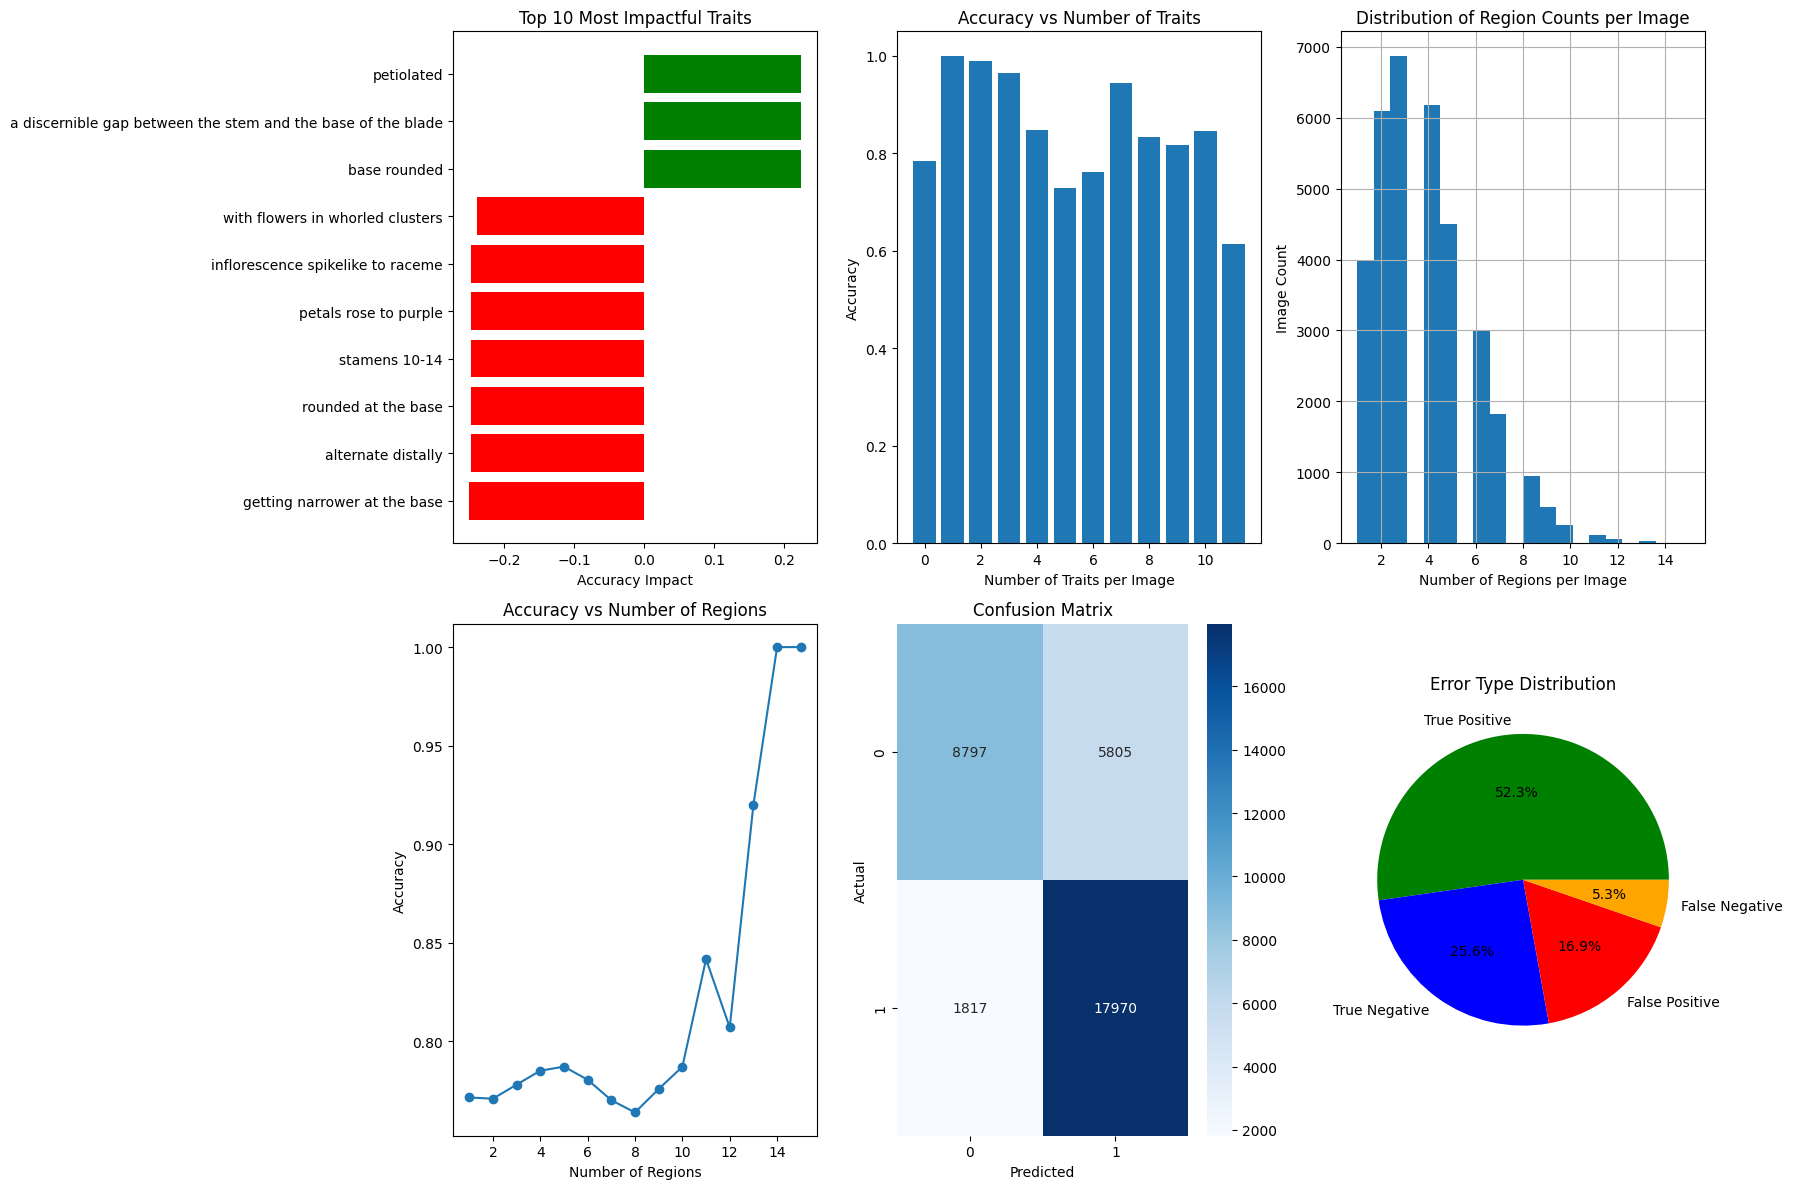

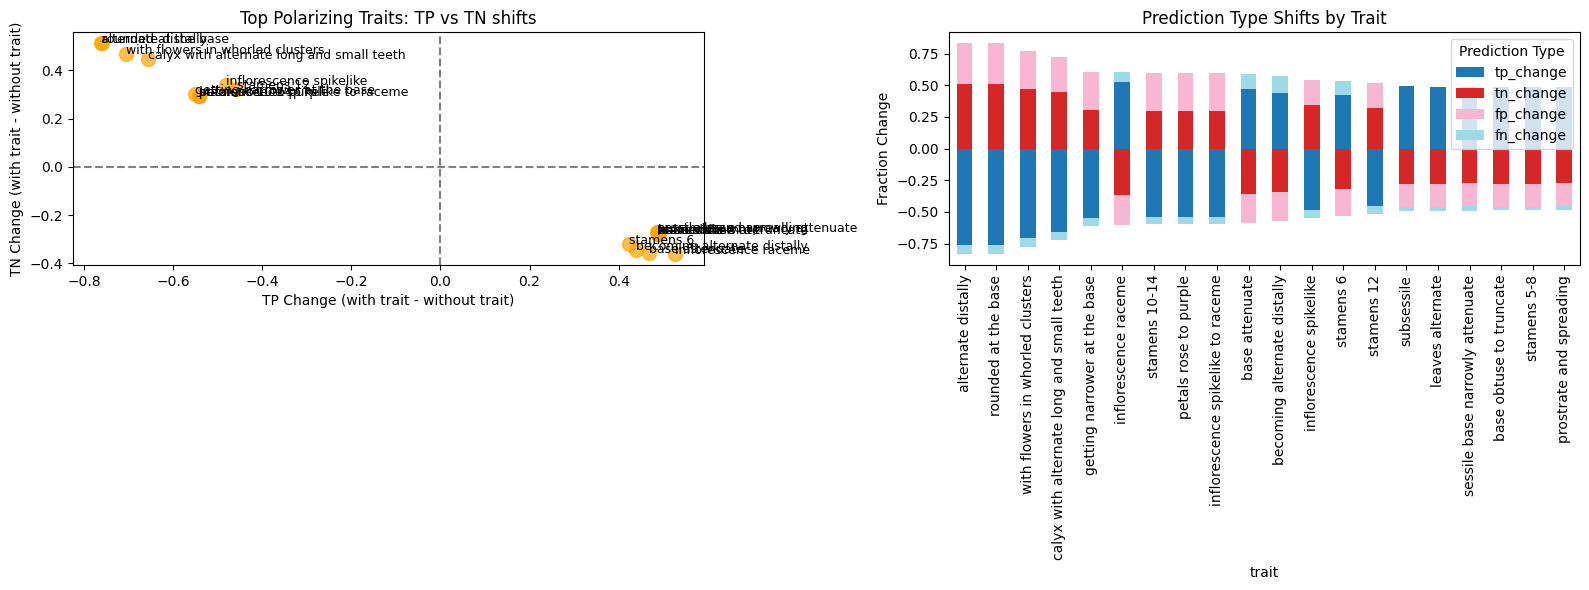

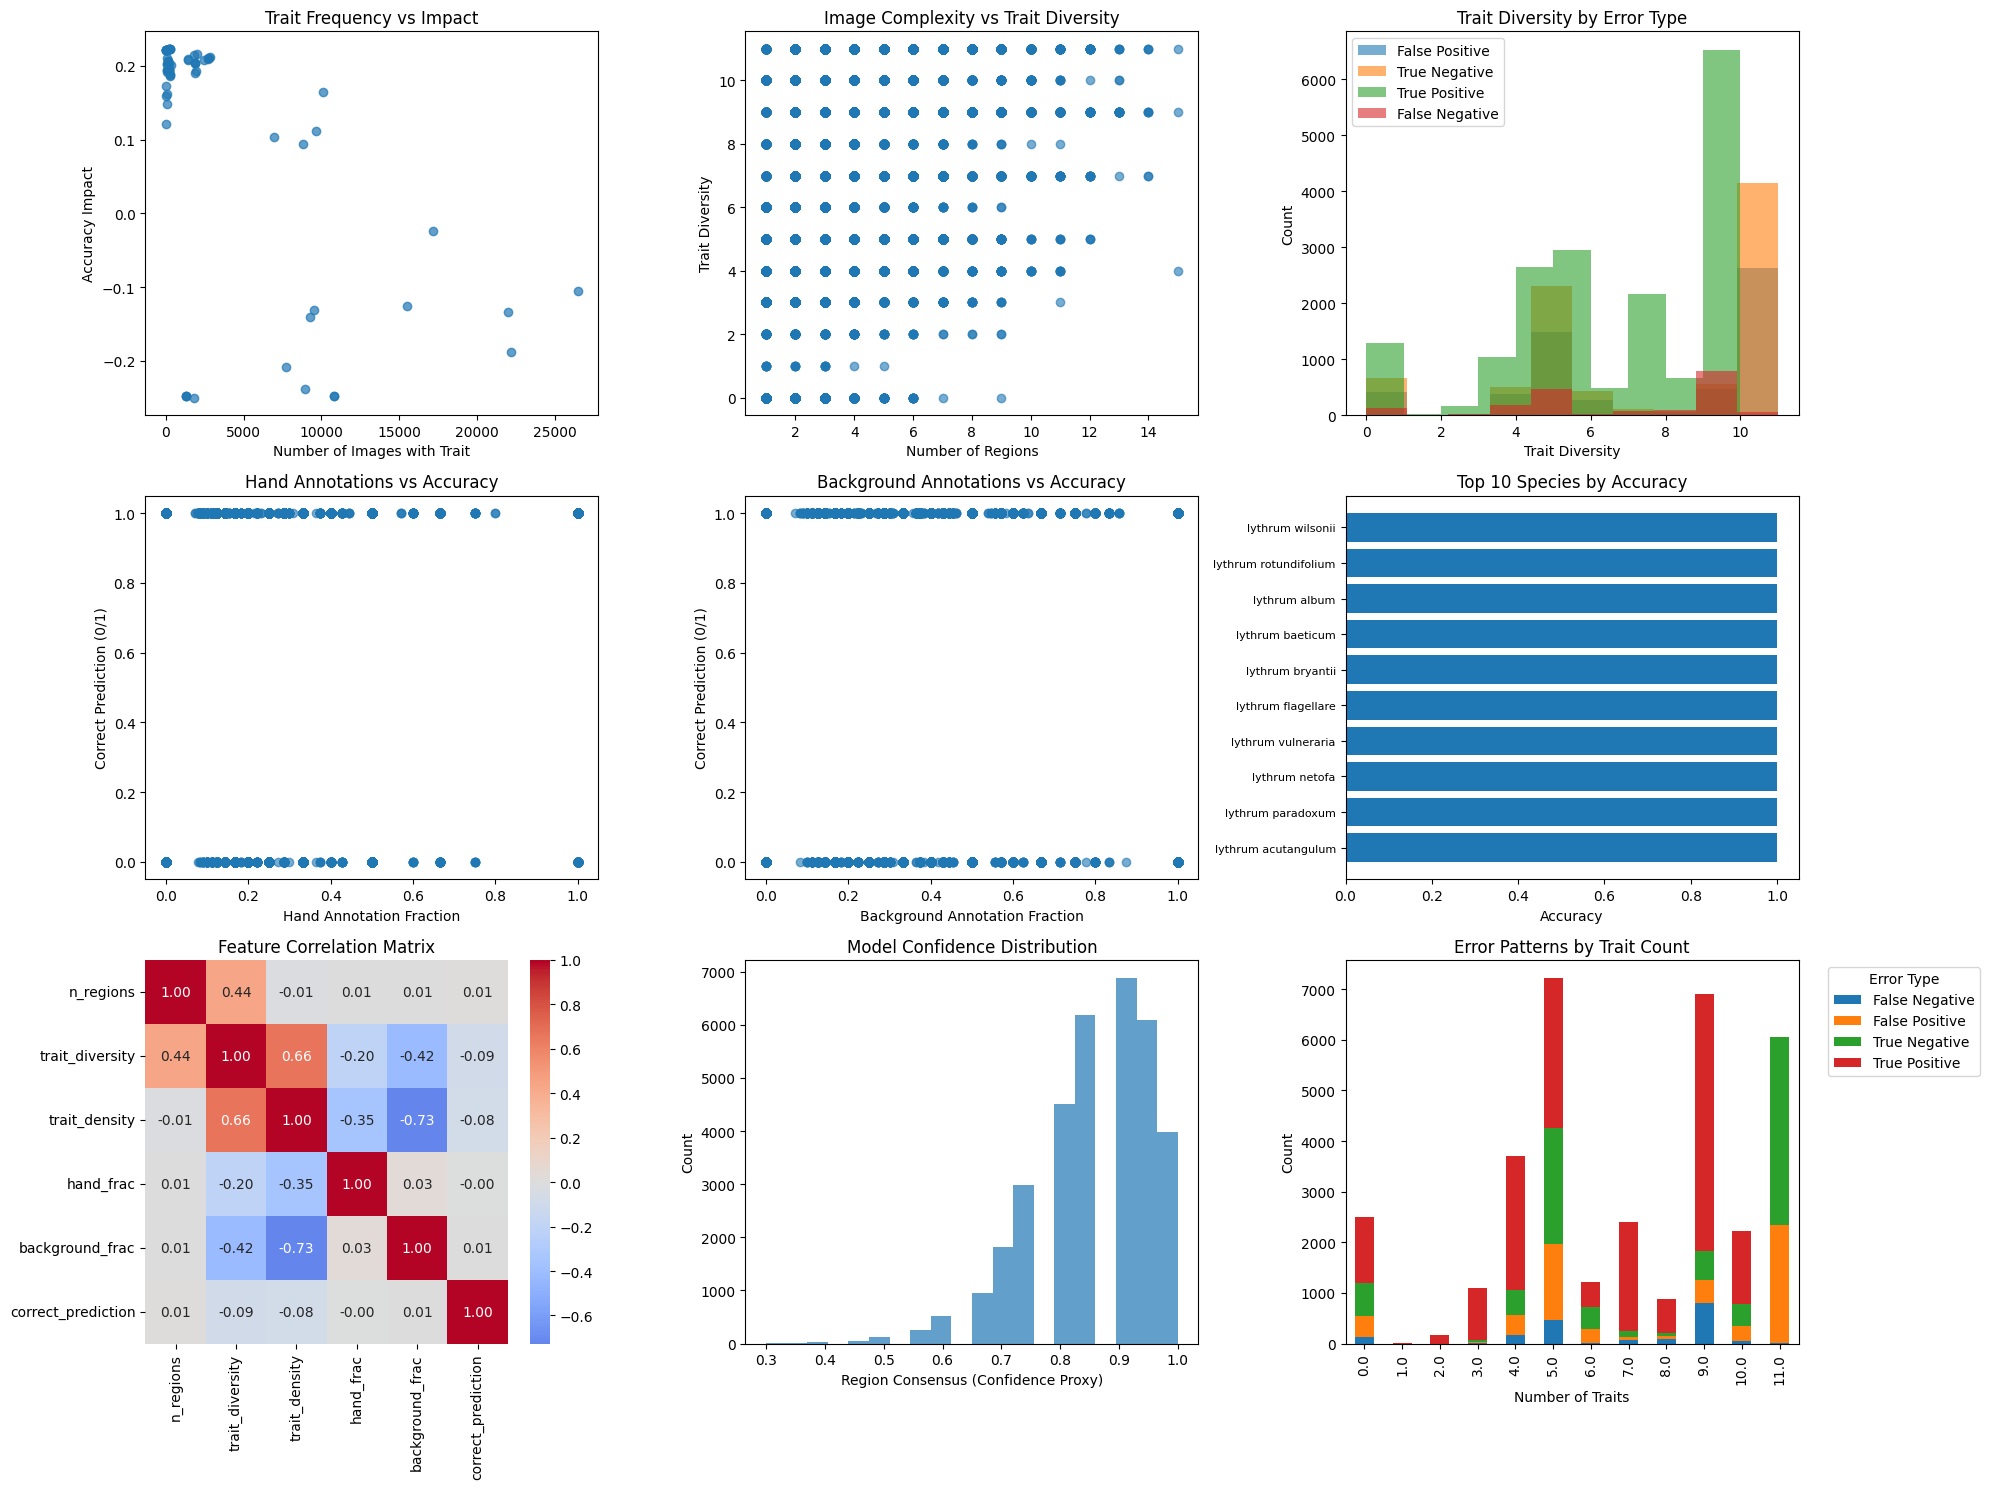

TRAIT CO-OCCURRENCE ANALYSIS
TRAIT CO-OCCURRENCE PATTERNS


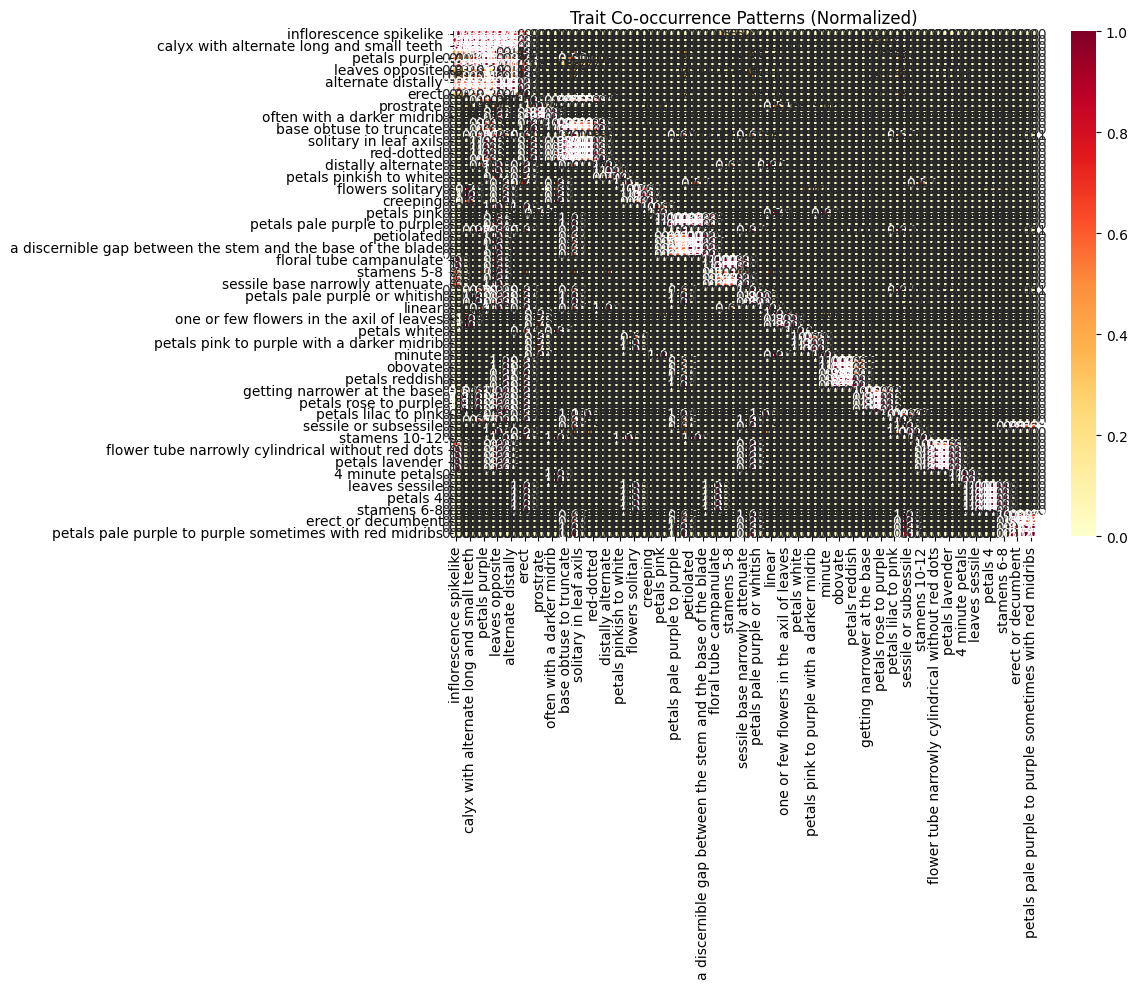

In [20]:
image_analyzer = EnhancedImageLevelAnalyzer(merged_df)

image_results = image_analyzer.comprehensive_summary_report()

# Trying something more elaborated

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class EnhancedImageLevelAnalyzer:
    """
    Image-level analyzer created from region-level data.
    - Input df must have columns: ['filename','obs_id','group','y_true','y_pred',
      'hand','background/undefined','characteristic_traits']
    - characteristic_traits may be list-like per row or NaN.
    This rewritten class adds:
      - Intro + dynamic interpretation printed for each analysis block.
      - Readable trait co-occurrence (top-N traits).
      - Keeps your original outputs but wraps them with explanations.
    """
    def __init__(self, df):
        self.df_regions = df.copy()
        self.df_images = self._aggregate_to_image_level()
        self._prepare_analysis_columns()
        # Ensure integer trait presence columns are filled
        for col in self.trait_cols_present:
            self.df_images[col] = self.df_images[col].fillna(0).astype(int)

    # ----------------- Helpers for printing -----------------
    def _print_header(self, title):
        print("="*60)
        print(title)
        print("="*60)

    def _interpret_ratio(self, a, b, label_a, label_b):
        """simple comparator text for two metrics"""
        if a > b:
            return f"{label_a} ({a:.3f}) > {label_b} ({b:.3f})"
        elif a < b:
            return f"{label_a} ({a:.3f}) < {label_b} ({b:.3f})"
        else:
            return f"{label_a} ({a:.3f}) == {label_b} ({b:.3f})"

    # ---------------- AGGREGATE TO IMAGE LEVEL ----------------
    def _aggregate_to_image_level(self):
        df = self.df_regions.copy()

        def parse_traits(x):
            if isinstance(x, float) and np.isnan(x):
                return []
            if isinstance(x, (list, tuple, np.ndarray)):
                return [str(t).strip() for t in x if (t is not None and str(t).strip()!='')]
            if pd.isna(x):
                return []
            # If string of comma-separated traits, try splitting
            if isinstance(x, str) and (',' in x):
                return [t.strip() for t in x.split(',') if t.strip()!='']
            return [str(x).strip()] if x not in (None, '') else []

        df['traits_list'] = df['characteristic_traits'].apply(parse_traits)

        grouped = []
        for obs_id, g in df.groupby('obs_id'):
            row = {}
            row['obs_id'] = obs_id
            # group/species representative - mode, fallback to first
            try:
                row['group'] = g['group'].mode()[0]
            except:
                row['group'] = g['group'].iloc[0]
            row['n_regions'] = len(g)
            try:
                row['y_true'] = g['y_true'].mode()[0]
            except:
                row['y_true'] = g['y_true'].iloc[0]
            try:
                row['y_pred'] = g['y_pred'].mode()[0]
            except:
                row['y_pred'] = g['y_pred'].iloc[0]
            row['correct_prediction'] = int(row['y_true'] == row['y_pred'])

            if row['y_true'] == row['y_pred']:
                row['error_type'] = 'True Positive' if row['y_true'] == 1 else 'True Negative'
            else:
                row['error_type'] = 'False Positive' if row['y_pred'] == 1 else 'False Negative'

            row['hand_frac'] = g['hand'].fillna(0).mean()
            row['background_frac'] = g['background/undefined'].fillna(0).mean()
            row['hand_count'] = g['hand'].fillna(0).sum()
            row['background_count'] = g['background/undefined'].fillna(0).sum()

            # Traits aggregated across regions
            trait_counts = Counter([t for traits in g['traits_list'] for t in traits])
            total_regions = len(g)
            for trait, count in trait_counts.items():
                safe_trait = str(trait).replace(' ', '_').replace('/','_').replace('-','_')
                row[f'trait_{safe_trait}_present'] = 1
                row[f'trait_{safe_trait}_freq'] = count / total_regions
                row[f'trait_{safe_trait}_count'] = count

            grouped.append(row)

        df_images = pd.DataFrame(grouped).fillna(0)
        # ensure obs_id is first column
        cols = ['obs_id'] + [c for c in df_images.columns if c!='obs_id']
        df_images = df_images[cols]
        return df_images

    # ---------------- PREPARE ANALYSIS COLUMNS ----------------
    def _prepare_analysis_columns(self):
        # Identify all trait presence/freq/count columns
        self.trait_cols_present = [c for c in self.df_images.columns if c.startswith('trait_') and c.endswith('_present')]
        self.trait_cols_freq = [c for c in self.df_images.columns if c.startswith('trait_') and c.endswith('_freq')]
        self.trait_cols_count = [c for c in self.df_images.columns if c.startswith('trait_') and c.endswith('_count')]

        # Numeric indicators
        self.df_images['error_numeric'] = self.df_images['error_type'].map({
            'True Positive': 0,
            'True Negative': 1,
            'False Positive': 2,
            'False Negative': 3
        }).fillna(0).astype(int)

        # Number of traits per image (presence)
        if len(self.trait_cols_present) > 0:
            self.df_images['num_traits'] = self.df_images[self.trait_cols_present].sum(axis=1)
            self.df_images['trait_diversity'] = self.df_images[self.trait_cols_present].sum(axis=1)
        else:
            self.df_images['num_traits'] = 0
            self.df_images['trait_diversity'] = 0

        # Total occurrences of trait regions in image
        if len(self.trait_cols_count) > 0:
            self.df_images['total_trait_regions'] = self.df_images[self.trait_cols_count].sum(axis=1)
            self.df_images['trait_density'] = np.where(self.df_images['n_regions']>0,
                                                       self.df_images['total_trait_regions'] / self.df_images['n_regions'],
                                                       0)
        else:
            self.df_images['total_trait_regions'] = 0
            self.df_images['trait_density'] = 0

        # Region consensus proxy: if many regions, consensus might dilute (custom heuristic)
        self.df_images['region_consensus'] = np.where(
            self.df_images['n_regions'] == 1, 1.0,
            1.0 - (self.df_images['n_regions'] - 1) * 0.05
        ).clip(0,1)

    # ---------------- PERFORMANCE SUMMARY ----------------
    def summary_performance(self):
        self._print_header("IMAGE-LEVEL PERFORMANCE SUMMARY (Intro)")
        print("What you'll see: overall accuracy and counts of different error types at the image level.")
        total = len(self.df_images)
        acc = self.df_images['correct_prediction'].mean() if total>0 else 0
        tp_count = (self.df_images['error_type']=='True Positive').sum()
        tn_count = (self.df_images['error_type']=='True Negative').sum()
        fp_count = (self.df_images['error_type']=='False Positive').sum()
        fn_count = (self.df_images['error_type']=='False Negative').sum()

        precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0.0
        recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        print()
        print(f"Overall Accuracy: {acc:.3f} (n={total})")
        print(f"True Positives: {tp_count}")
        print(f"True Negatives: {tn_count}")
        print(f"False Positives: {fp_count}")
        print(f"False Negatives: {fn_count}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall:    {recall:.3f}")
        print(f"F1-Score:  {f1:.3f}")
        print("\nError type counts (table):")
        print(self.df_images['error_type'].value_counts())
        print()

        # Dynamic interpretation
        print("Interpretation:")
        if total == 0:
            print("  No images available for analysis.")
            return acc
        print(f"  - The model's image-level accuracy is {acc:.3f}.")
        compare = self._interpret_ratio(precision, recall, 'Precision', 'Recall')
        print(f"  - {compare}.")
        if precision > recall:
            print("    -> This suggests the model is more conservative: it avoids false positives but may miss true invasive cases.")
        elif recall > precision:
            print("    -> This suggests the model is more sensitive: it catches more true invasive cases but may produce more false alarms.")
        else:
            print("    -> Precision and recall are balanced.")
        if fp_count > fn_count:
            print(f"  - There are more False Positives ({fp_count}) than False Negatives ({fn_count}). Consider checking features that encourage 'invasive' predictions.")
        elif fn_count > fp_count:
            print(f"  - There are more False Negatives ({fn_count}) than False Positives ({fp_count}). The model might be missing invasive plants.")
        else:
            print("  - False Positives and False Negatives are balanced.")
        print()
        return acc

    # ---------------- SPECIES-LEVEL ANALYSIS ----------------
    def species_performance_analysis(self, min_samples=5):
        self._print_header("SPECIES-LEVEL PERFORMANCE ANALYSIS (Intro)")
        print("What you'll see: per-species (group) counts and accuracy. This helps identify species that the model handles poorly or well.")
        species_stats = []
        for species in self.df_images['group'].unique():
            df_species = self.df_images[self.df_images['group'] == species]
            n_images = len(df_species)
            if n_images < 1:
                continue
            stats_row = {
                'species': species,
                'n_images': n_images,
                'accuracy': df_species['correct_prediction'].mean(),
                'tp_rate': (df_species['error_type']=='True Positive').mean(),
                'tn_rate': (df_species['error_type']=='True Negative').mean(),
                'fp_rate': (df_species['error_type']=='False Positive').mean(),
                'fn_rate': (df_species['error_type']=='False Negative').mean(),
                'avg_regions': df_species['n_regions'].mean(),
                'avg_trait_diversity': df_species['trait_diversity'].mean(),
                'invasive_ratio': df_species['y_true'].mean()
            }
            species_stats.append(stats_row)

        species_df = pd.DataFrame(species_stats).sort_values('n_images', ascending=False)
        print()
        if species_df.empty:
            print("No species data available.")
            return species_df

        # Print top/bottom by accuracy with sample size filter
        print("Top species by accuracy (min samples filter):")
        display_df = species_df[species_df['n_images']>=min_samples].sort_values('accuracy', ascending=False)
        print(display_df.head(15))
        print()
        print("Statistical test (ANOVA) to check if accuracies differ across species:")
        # ANOVA - collect only species with >0 samples
        species_accuracies = [self.df_images[self.df_images['group']==sp]['correct_prediction'].values
                              for sp in self.df_images['group'].unique() if len(self.df_images[self.df_images['group']==sp])>0]
        try:
            if len(species_accuracies) > 1:
                f_stat, p_val = stats.f_oneway(*species_accuracies)
                print(f"  ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
                if p_val < 0.05:
                    print("  -> Significant differences in accuracy across species (p < 0.05).")
                else:
                    print("  -> No significant differences in accuracy across species (p >= 0.05).")
            else:
                print("  Not enough species with samples for ANOVA.")
        except Exception as e:
            print("  Could not perform ANOVA:", str(e))

        # Interpretation
        print()
        print("Interpretation:")
        if display_df.empty:
            print("  - After applying the min_samples filter, no species meet the threshold: consider lowering min_samples.")
        else:
            top = display_df.iloc[0]
            bottom = display_df.iloc[-1]
            print(f"  - Best-performing species (sample>= {min_samples}): {top['species']} with accuracy {top['accuracy']:.3f} (n={int(top['n_images'])}).")
            print(f"  - Worst-performing species (sample>= {min_samples}): {bottom['species']} with accuracy {bottom['accuracy']:.3f} (n={int(bottom['n_images'])}).")
            if p_val < 0.05:
                print("  - The ANOVA suggests species-level differences are unlikely to be due to chance. Check species-specific traits or data quality.")
            else:
                print("  - Differences between species are not statistically significant at p<0.05.")
        print()
        return species_df

    # ---------------- TRAIT INTENSITY ANALYSIS ----------------
    def trait_intensity_analysis(self, min_images=10):
        self._print_header("TRAIT INTENSITY ANALYSIS (Intro)")
        print("What you'll see: for traits with enough images, correlation between trait intensity (freq/count) and image-level accuracy.")
        intensity_results = []
        trait_bases = set([c.replace('trait_','').replace('_present','') for c in self.trait_cols_present])
        for trait_base in trait_bases:
            present_col = f'trait_{trait_base}_present'
            freq_col = f'trait_{trait_base}_freq'
            count_col = f'trait_{trait_base}_count'
            if present_col not in self.df_images.columns:
                continue
            df_with = self.df_images[self.df_images[present_col]==1]
            if len(df_with) < min_images:
                continue
            # compute correlations
            freq_corr = df_with[freq_col].corr(df_with['correct_prediction']) if freq_col in df_with.columns else np.nan
            count_corr = df_with[count_col].corr(df_with['correct_prediction']) if count_col in df_with.columns else np.nan
            # quartile comparison
            try:
                fq1, fq3 = df_with[freq_col].quantile([0.25, 0.75]) if freq_col in df_with.columns else (np.nan, np.nan)
                cq1, cq3 = df_with[count_col].quantile([0.25, 0.75]) if count_col in df_with.columns else (np.nan, np.nan)
                low_freq_acc = df_with[df_with[freq_col] <= fq1]['correct_prediction'].mean() if not np.isnan(fq1) else np.nan
                high_freq_acc = df_with[df_with[freq_col] >= fq3]['correct_prediction'].mean() if not np.isnan(fq3) else np.nan
                low_count_acc = df_with[df_with[count_col] <= cq1]['correct_prediction'].mean() if not np.isnan(cq1) else np.nan
                high_count_acc = df_with[df_with[count_col] >= cq3]['correct_prediction'].mean() if not np.isnan(cq3) else np.nan
            except:
                low_freq_acc = high_freq_acc = low_count_acc = high_count_acc = np.nan

            intensity_results.append({
                'trait': trait_base,
                'n_images': len(df_with),
                'freq_corr': freq_corr,
                'count_corr': count_corr,
                'low_freq_acc': low_freq_acc,
                'high_freq_acc': high_freq_acc,
                'freq_effect': (high_freq_acc - low_freq_acc) if not (np.isnan(low_freq_acc) or np.isnan(high_freq_acc)) else np.nan,
                'low_count_acc': low_count_acc,
                'high_count_acc': high_count_acc,
                'count_effect': (high_count_acc - low_count_acc) if not (np.isnan(low_count_acc) or np.isnan(high_count_acc)) else np.nan
            })

        intensity_df = pd.DataFrame(intensity_results).sort_values('freq_effect', key=lambda s: s.abs() if s.notna().all() else s.fillna(0), ascending=False)
        if intensity_df.empty:
            print("No traits with enough samples for intensity analysis.")
            return intensity_df
        print()
        print("Top trait intensity effects (by absolute effect):")
        print(intensity_df.head(10))
        print()
        # Interpretation: find notable correlations/effects
        print("Interpretation:")
        top = intensity_df.head(5)
        for _, row in top.iterrows():
            trait = row['trait']
            n = int(row['n_images'])
            fc = row['freq_corr']
            cc = row['count_corr']
            fe = row['freq_effect']
            ce = row['count_effect']
            notes = []
            if not np.isnan(fc) and abs(fc) > 0.2:
                notes.append(f"freq_corr={fc:.2f}")
            if not np.isnan(cc) and abs(cc) > 0.2:
                notes.append(f"count_corr={cc:.2f}")
            if not np.isnan(fe) and abs(fe) > 0.05:
                notes.append(f"freq_effect={fe:.3f}")
            if not np.isnan(ce) and abs(ce) > 0.05:
                notes.append(f"count_effect={ce:.3f}")
            note_text = "; ".join(notes) if notes else "no strong effect"
            print(f"  - Trait '{trait}' (n={n}): {note_text}")
        print()
        return intensity_df

    # ---------------- REGION COMPLEXITY ANALYSIS ----------------
    def region_complexity_analysis(self):
        self._print_header("IMAGE COMPLEXITY ANALYSIS (Intro)")
        print("What you'll see: performance by number of extracted regions (image complexity).")
        # Binning regions into categories
        self.df_images['complexity_category'] = pd.cut(
            self.df_images['n_regions'],
            bins=[-1, 1, 3, 5, 10, float('inf')],
            labels=['Simple(1)', 'Low(2-3)', 'Medium(4-5)', 'High(6-10)', 'Very High(10+)']
        )
        complexity_stats = self.df_images.groupby('complexity_category').agg({
            'obs_id': 'count',
            'correct_prediction': 'mean',
            'trait_diversity': 'mean',
            'trait_density': 'mean',
            'hand_frac': 'mean',
            'background_frac': 'mean'
        }).rename(columns={'obs_id':'n_images','correct_prediction':'accuracy'}).round(3)
        print()
        print("Complexity group stats:")
        print(complexity_stats)
        print()
        # ANOVA
        groups = [self.df_images[self.df_images['complexity_category']==cat]['correct_prediction'].values
                  for cat in self.df_images['complexity_category'].dropna().unique()]
        try:
            if len(groups) > 1:
                f_stat, p_val = stats.f_oneway(*groups)
                print(f"ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
            else:
                print("Not enough complexity groups for ANOVA.")
        except Exception as e:
            print("Could not perform ANOVA:", str(e))
        # Interpretation
        print()
        print("Interpretation:")
        if complexity_stats.empty:
            print("  No data for complexity analysis.")
        else:
            best = complexity_stats['accuracy'].idxmax()
            worst = complexity_stats['accuracy'].idxmin()
            print(f"  - Best accuracy in category: {best} ({complexity_stats.loc[best,'accuracy']:.3f})")
            print(f"  - Worst accuracy in category: {worst} ({complexity_stats.loc[worst,'accuracy']:.3f})")
            if 'p_val' in locals() and 'p_val' in locals() and p_val < 0.05:
                print("  - Accuracy differences across complexity categories are statistically significant (p < 0.05).")
            else:
                print("  - No strong statistical evidence that complexity alone drives accuracy differences (p >= 0.05 or not computed).")
        print()
        return complexity_stats

    # ---------------- PREDICTIVE FEATURE IMPORTANCE ----------------
    def predictive_feature_analysis(self, top_n=15):
        self._print_header("PREDICTIVE FEATURE IMPORTANCE (Intro)")
        print("What you'll see: Random Forest feature importances predicting whether the image-level prediction was correct.")
        # Build feature set
        feature_cols = []
        feature_cols.extend(self.trait_cols_present)
        feature_cols.extend(self.trait_cols_freq)
        # add some aggregate features
        candidate = ['n_regions', 'trait_diversity', 'trait_density', 'hand_frac', 'background_frac']
        for c in candidate:
            if c in self.df_images.columns:
                feature_cols.append(c)
        if len(feature_cols) == 0:
            print("No features available for RF analysis.")
            return pd.DataFrame()

        X = self.df_images[feature_cols].fillna(0)
        y = self.df_images['correct_prediction']
        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        rf.fit(X, y)
        fi = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
        print()
        print("Top predictive features:")
        print(fi.head(top_n))
        # Cross-validation
        try:
            cv_scores = cross_val_score(rf, X, y, cv=5)
            print(f"\nRandom Forest CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
        except Exception as e:
            print("Cross-validation failed:", str(e))
        # Interpretation
        print()
        print("Interpretation:")
        top = fi.head(5)
        for _, row in top.iterrows():
            print(f"  - {row['feature']} has importance {row['importance']:.3f}")
        if fi['importance'].iloc[0] > 0.2:
            print("  - The top feature is strongly predictive (importance > 0.2). Investigate this feature for data leakage or strong signal.")
        else:
            print("  - No single dominant predictive feature; model correctness appears distributed across features.")
        print()
        return fi

    # ---------------- ERROR PATTERN ANALYSIS ----------------
    def error_pattern_analysis(self):
        self._print_header("ERROR PATTERN ANALYSIS (Intro)")
        print("What you'll see: typical traits in False Positives and False Negatives and their average complexity.")
        error_patterns = {}
        fp_images = self.df_images[self.df_images['error_type']=='False Positive']
        if len(fp_images) > 0:
            fp_traits = fp_images[self.trait_cols_present].mean().sort_values(ascending=False)
            error_patterns['False Positive'] = {
                'count': len(fp_images),
                'top_traits': fp_traits.head(8).to_dict(),
                'avg_regions': fp_images['n_regions'].mean(),
                'avg_trait_diversity': fp_images['trait_diversity'].mean()
            }
        fn_images = self.df_images[self.df_images['error_type']=='False Negative']
        if len(fn_images) > 0:
            fn_traits = fn_images[self.trait_cols_present].mean().sort_values(ascending=False)
            error_patterns['False Negative'] = {
                'count': len(fn_images),
                'top_traits': fn_traits.head(8).to_dict(),
                'avg_regions': fn_images['n_regions'].mean(),
                'avg_trait_diversity': fn_images['trait_diversity'].mean()
            }
        # Output
        if not error_patterns:
            print("No error patterns (no FP or FN found).")
            return error_patterns
        for etype, pattern in error_patterns.items():
            print()
            print(f"{etype} (n={pattern['count']})")
            print(f"  Avg regions: {pattern['avg_regions']:.2f}")
            print(f"  Avg trait diversity: {pattern['avg_trait_diversity']:.2f}")
            print("  Top traits (fraction of images with trait):")
            for trait, val in pattern['top_traits'].items():
                clean = trait.replace('trait_','').replace('_present','')
                print(f"    - {clean}: {val:.3f}")
        # Interpretation
        print()
        print("Interpretation:")
        if 'False Positive' in error_patterns:
            fp = error_patterns['False Positive']
            print(f"  - FP images (n={fp['count']}) commonly show traits: " +
                  ", ".join([t.replace('trait_','').replace('_present','') for t in list(fp['top_traits'].keys())[:3]]))
            print("    -> These traits may cause the model to over-predict invasiveness.")
        if 'False Negative' in error_patterns:
            fn = error_patterns['False Negative']
            print(f"  - FN images (n={fn['count']}) commonly show traits: " +
                  ", ".join([t.replace('trait_','').replace('_present','') for t in list(fn['top_traits'].keys())[:3]]))
            print("    -> These traits may be associated with missed invasive cases.")
        print()
        return error_patterns

    # ---------------- ANNOTATION LABEL IMPACT ----------------
    def analyze_annotation_labels(self):
        self._print_header("ANNOTATION LABEL IMPACT (Intro)")
        print("What you'll see: whether presence of 'hand' or 'background/undefined' labels correlate with model correctness.")
        for col, pretty in [('hand_frac','Hand'), ('background_frac','Background')]:
            print()
            print(f"Analysis for label: {pretty}")
            has_label = self.df_images[col] > 0
            df_with = self.df_images[has_label]
            df_without = self.df_images[~has_label]
            acc_with = df_with['correct_prediction'].mean() if len(df_with)>0 else np.nan
            acc_without = df_without['correct_prediction'].mean() if len(df_without)>0 else np.nan
            print(f"  With {pretty}:   Acc={acc_with:.3f} (n={len(df_with)})")
            print(f"  Without {pretty}: Acc={acc_without:.3f} (n={len(df_without)})")
            diff = (acc_with - acc_without) if not (np.isnan(acc_with) or np.isnan(acc_without)) else np.nan
            print(f"  Difference: {diff:+.3f}")
            contingency = pd.crosstab(has_label, self.df_images['correct_prediction'])
            if contingency.shape == (2,2):
                chi2, p, _, _ = stats.chi2_contingency(contingency)
                signif = "SIGNIFICANT" if p<0.05 else "NOT significant"
                print(f"  Chi-square test: {signif} (p={p:.4f})")
            else:
                print("  Chi-square test not applicable (imbalanced groups).")
            # Interpretation
            if not np.isnan(diff):
                if diff > 0.02:
                    print(f"  Interpretation: Presence of '{pretty}' is associated with slightly higher accuracy (diff={diff:.3f}).")
                elif diff < -0.02:
                    print(f"  Interpretation: Presence of '{pretty}' is associated with slightly lower accuracy (diff={diff:.3f}).")
                else:
                    print(f"  Interpretation: No meaningful difference in accuracy with/without '{pretty}'.")
        print()
        return

    # ---------------- TRAIT IMPACT (per trait presence) ----------------
    def trait_impact(self, min_images=10):
        self._print_header("TRAIT IMPACT (Intro)")
        print("What you'll see: impact on accuracy for images that contain each trait vs images that don't.")
        results = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            n_images = int(self.df_images[col].sum())
            if n_images < min_images:
                continue
            df_with = self.df_images[self.df_images[col]==1]
            df_without = self.df_images[self.df_images[col]==0]
            acc_with = df_with['correct_prediction'].mean() if len(df_with)>0 else np.nan
            acc_without = df_without['correct_prediction'].mean() if len(df_without)>0 else np.nan
            diff = (acc_with - acc_without) if not (np.isnan(acc_with) or np.isnan(acc_without)) else np.nan
            # chi-square for presence vs correctness
            contingency = pd.crosstab(self.df_images[col], self.df_images['correct_prediction'])
            if contingency.shape == (2,2):
                try:
                    chi2, p, _, _ = stats.chi2_contingency(contingency)
                except:
                    p = 1.0
            else:
                p = 1.0
            results.append({
                'trait': trait_name,
                'n_images': n_images,
                'acc_with': acc_with,
                'acc_without': acc_without,
                'impact': diff,
                'p_value': p,
                'significant': 'Yes' if p<0.05 else 'No'
            })
        df_res = pd.DataFrame(results).sort_values('impact', key=lambda s: s.abs() if s.notna().all() else s.fillna(0), ascending=False)
        if df_res.empty:
            print("No traits meet the min_images threshold for trait impact.")
            return df_res
        print()
        print("Top trait impacts:")
        print(df_res.head(20))
        # Interpretation (dynamic)
        print()
        print("Interpretation:")
        if df_res.empty:
            print("  No strong trait impacts found.")
        else:
            top = df_res.iloc[0]
            print(f"  - Trait with largest impact: '{top['trait']}' (n={top['n_images']}), impact={top['impact']:.3f}, significant={top['significant']}")
            # quick rule-of-thumb
            sig_count = df_res['significant'].value_counts().get('Yes', 0)
            if sig_count > 0:
                print(f"  - {sig_count} traits show statistically significant association with image-level correctness (p<0.05). Investigate these traits further.")
            else:
                print("  - No traits show statistically significant associations at p<0.05.")
        print()
        return df_res

    # ---------------- TRAIT COMBINATION ANALYSIS ----------------
    def trait_combination_analysis(self, min_images=5):
        self._print_header("TRAIT COMBINATION ANALYSIS (Intro)")
        print("What you'll see: performance (accuracy) by exact combination of present traits (only combos with >= min_images).")
        # Build combo label
        if len(self.trait_cols_present) == 0:
            print("No trait presence columns available.")
            return pd.DataFrame()
        self.df_images['trait_combo'] = self.df_images[self.trait_cols_present].apply(
            lambda row: ', '.join([c.replace('trait_','').replace('_present','') for c,v in row.items() if v==1]) if row.sum()>0 else 'No Traits',
            axis=1
        )
        combo_stats = self.df_images.groupby('trait_combo').agg(
            sample_size=('obs_id','count'),
            accuracy=('correct_prediction','mean')
        ).sort_values('accuracy', ascending=False)
        combo_stats = combo_stats[combo_stats['sample_size']>=min_images]
        print()
        print("Top trait combinations (filtered by min_images):")
        print(combo_stats.head(20))
        print()
        print("Interpretation:")
        if combo_stats.empty:
            print("  - No trait combinations meet the min_images threshold; consider lowering min_images or aggregating traits.")
        else:
            top_combo = combo_stats.iloc[0]
            print(f"  - Best combo: '{top_combo.name}' (n={int(top_combo['sample_size'])}) with accuracy {top_combo['accuracy']:.3f}.")
            print("  - Combination-level effects can indicate interactions not visible from single-trait analysis.")
        print()
        return combo_stats

    # ---------------- TRAIT PREDICTION PATTERN ANALYSIS ----------------
    def trait_prediction_pattern_analysis(self, min_images=50):
        self._print_header("TRAIT PREDICTION PATTERN ANALYSIS (Intro)")
        print("What you'll see: traits that create contrasting effects across TP/TN/FP/FN proportions.")
        records = []
        for col in self.trait_cols_present:
            trait = col.replace('trait_','').replace('_present','')
            n_images = int(self.df_images[col].sum())
            if n_images < min_images:
                continue
            df_with = self.df_images[self.df_images[col]==1]
            df_without = self.df_images[self.df_images[col]==0]
            # fractions:
            def frac(df, kind):
                return (df['error_type']==kind).mean() if len(df)>0 else 0.0
            tp_with = frac(df_with,'True Positive'); tn_with = frac(df_with,'True Negative')
            fp_with = frac(df_with,'False Positive'); fn_with = frac(df_with,'False Negative')
            tp_without = frac(df_without,'True Positive'); tn_without = frac(df_without,'True Negative')
            fp_without = frac(df_without,'False Positive'); fn_without = frac(df_without,'False Negative')
            tp_change = tp_with - tp_without
            tn_change = tn_with - tn_without
            fp_change = fp_with - fp_without
            fn_change = fn_with - fn_without
            asymmetry = abs(tp_change) + abs(tn_change) + abs(fp_change) + abs(fn_change)
            pattern_type = 'polarizing' if tp_change * tn_change < 0 else 'aligned'
            # p-value via chi2 on TP/TN counts
            contingency = pd.DataFrame([
                [ (df_with['error_type']=='True Positive').sum(), (df_without['error_type']=='True Positive').sum() ],
                [ (df_with['error_type']=='True Negative').sum(), (df_without['error_type']=='True Negative').sum() ]
            ])
            try:
                chi2, p, _, _ = stats.chi2_contingency(contingency)
            except:
                p = 1.0
            records.append({
                'trait': trait,
                'n_images': n_images,
                'tp_change': tp_change,
                'tn_change': tn_change,
                'fp_change': fp_change,
                'fn_change': fn_change,
                'asymmetry_score': asymmetry,
                'pattern_type': pattern_type,
                'p_value': p
            })
        df_patterns = pd.DataFrame(records).sort_values('asymmetry_score', ascending=False)
        if df_patterns.empty:
            print("No traits meet the min_images threshold for pattern analysis.")
            return df_patterns
        print()
        print("Top polarizing traits (asymmetry score):")
        print(df_patterns.head(30))
        print()
        # Interpretation
        print("Interpretation:")
        top = df_patterns.head(3)
        for _, r in top.iterrows():
            print(f"  - Trait '{r['trait']}' (n={int(r['n_images'])}) has asymmetry {r['asymmetry_score']:.3f}, p={r['p_value']:.3f} -> {r['pattern_type']}")
        print()
        return df_patterns

    # ---------------- TRAIT COMBINATION POLARIZATION ----------------
    def trait_combination_polarization(self, min_images=20):
        self._print_header("TRAIT COMBINATION POLARIZATION (Intro)")
        print("What you'll see: small set (pairs/triples) of trait combos that strongly shift TP/TN/FP/FN balances.")
        combo_records = []
        # iterate over trait presence columns (names)
        present_cols = self.trait_cols_present
        if len(present_cols) < 2:
            print("Not enough traits to compute combinations.")
            return pd.DataFrame()
        for r in range(2,4):  # pairs and triples
            for combo in combinations(present_cols, r):
                df_combo = self.df_images[(self.df_images[list(combo)]==1).all(axis=1)]
                if len(df_combo) < min_images:
                    continue
                tp_frac = (df_combo['error_type']=='True Positive').mean()
                tn_frac = (df_combo['error_type']=='True Negative').mean()
                fp_frac = (df_combo['error_type']=='False Positive').mean()
                fn_frac = (df_combo['error_type']=='False Negative').mean()
                asymmetry = abs(tp_frac - tn_frac) + abs(fp_frac - fn_frac)
                combo_records.append({
                    'trait_combo': ', '.join([c.replace('trait_','').replace('_present','') for c in combo]),
                    'n_images': len(df_combo),
                    'tp_frac': tp_frac,
                    'tn_frac': tn_frac,
                    'fp_frac': fp_frac,
                    'fn_frac': fn_frac,
                    'asymmetry_score': asymmetry
                })
        df_combo = pd.DataFrame(combo_records).sort_values('asymmetry_score', ascending=False)
        if df_combo.empty:
            print("No trait combinations meet the min_images threshold.")
            return df_combo
        print()
        print("Top combinations by asymmetry:")
        print(df_combo.head(20))
        print()
        print("Interpretation:")
        print("  - Highly asymmetric combinations may indicate interaction effects that push predictions to one class.")
        print()
        return df_combo.head(20)

    # ---------------- READABLE PLOTTING ----------------
    def plot_readable_visualizations(self, top_n_traits=10):
        """
        Produce a compact figure summarizing many diagnostics.
        top_n_traits controls visibility in the trait-impact panel.
        """
        plt.style.use('default')
        fig = plt.figure(figsize=(18,12))

        # 1. Top impactful traits
        trait_df = self.trait_impact(min_images=5)
        top_traits = trait_df.head(top_n_traits) if not trait_df.empty else pd.DataFrame()
        plt.subplot(2,3,1)
        if not top_traits.empty:
            colors = ['green' if x>0 else 'red' for x in top_traits['impact']]
            plt.barh(top_traits['trait'], top_traits['impact'], color=colors)
            plt.xlabel('Accuracy Impact')
            plt.title(f'Top {len(top_traits)} Most Impactful Traits')
        else:
            plt.text(0.5,0.5,"No traits to show", ha='center')
            plt.title('Top Traits')

        # 2. Accuracy by number of traits
        plt.subplot(2,3,2)
        num_traits_acc = self.df_images.groupby('num_traits')['correct_prediction'].mean()
        plt.bar(num_traits_acc.index, num_traits_acc.values)
        plt.xlabel('Number of Traits per Image')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Traits')

        # 3. Region count distribution
        plt.subplot(2,3,3)
        self.df_images['n_regions'].hist(bins=20)
        plt.xlabel('Number of Regions per Image')
        plt.ylabel('Image Count')
        plt.title('Distribution of Region Counts per Image')

        # 4. Accuracy vs region counts
        plt.subplot(2,3,4)
        acc_by_regions = self.df_images.groupby('n_regions')['correct_prediction'].mean()
        plt.plot(acc_by_regions.index, acc_by_regions.values, marker='o')
        plt.xlabel('Number of Regions')
        plt.ylabel('Accuracy')
        plt.title('Accuracy vs Number of Regions')

        # 5. Confusion matrix
        plt.subplot(2,3,5)
        try:
            cm = confusion_matrix(self.df_images['y_true'], self.df_images['y_pred'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix')
        except:
            plt.text(0.5,0.5,"No confusion matrix", ha='center')

        # 6. Error type pie chart
        plt.subplot(2,3,6)
        counts = self.df_images['error_type'].value_counts()
        if len(counts)>0:
            colors_map = {
                'True Positive':'#2ca02c', 'True Negative':'#1f77b4',
                'False Positive':'#d62728','False Negative':'#ff7f0e'
            }
            plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                    colors=[colors_map.get(x,'gray') for x in counts.index])
            plt.title('Error Type Distribution')
        else:
            plt.text(0.5,0.5,"No error data", ha='center')

        plt.tight_layout()
        plt.show()

    # ---------------- TRAIT INTERACTION ANALYSIS ----------------
    def trait_interaction_matrix(self, min_images=20):
        self._print_header("TRAIT INTERACTION ANALYSIS (Intro)")
        print("What you'll see: pairwise trait interactions (synergy/antagonism) for trait pairs with enough co-occurrence.")
        interaction_results = []
        trait_names = [c.replace('trait_','').replace('_present','') for c in self.trait_cols_present]
        for i, trait1 in enumerate(self.trait_cols_present):
            for j, trait2 in enumerate(self.trait_cols_present[i+1:], i+1):
                both_traits = self.df_images[(self.df_images[trait1]==1) & (self.df_images[trait2]==1)]
                only_trait1 = self.df_images[(self.df_images[trait1]==1) & (self.df_images[trait2]==0)]
                only_trait2 = self.df_images[(self.df_images[trait1]==0) & (self.df_images[trait2]==1)]
                neither = self.df_images[(self.df_images[trait1]==0) & (self.df_images[trait2]==0)]
                if len(both_traits) >= min_images:
                    acc_both = both_traits['correct_prediction'].mean()
                    acc_trait1 = only_trait1['correct_prediction'].mean() if len(only_trait1)>0 else np.nan
                    acc_trait2 = only_trait2['correct_prediction'].mean() if len(only_trait2)>0 else np.nan
                    expected_combined = (np.nanmean([acc_trait1, acc_trait2]) if not (np.isnan(acc_trait1) and np.isnan(acc_trait2)) else max(acc_trait1 if not np.isnan(acc_trait1) else -1, acc_trait2 if not np.isnan(acc_trait2) else -1))
                    synergy = acc_both - expected_combined if not np.isnan(expected_combined) else np.nan
                    interaction_results.append({
                        'trait1': trait_names[i],
                        'trait2': trait_names[j],
                        'n_both': len(both_traits),
                        'acc_both': acc_both,
                        'acc_trait1_only': acc_trait1,
                        'acc_trait2_only': acc_trait2,
                        'synergy_score': synergy,
                        'interaction_type': 'Synergistic' if not np.isnan(synergy) and synergy > 0.05 else ('Antagonistic' if not np.isnan(synergy) and synergy < -0.05 else 'Neutral')
                    })
        interaction_df = pd.DataFrame(interaction_results).sort_values('synergy_score', key=lambda s: s.abs() if s.notna().all() else s.fillna(0), ascending=False)
        if interaction_df.empty:
            print("No trait pair interactions passing the min_images threshold.")
            return interaction_df
        print()
        print("Top trait interactions:")
        print(interaction_df.head(15))
        print()
        print("Interpretation:")
        top = interaction_df.head(5)
        for _, r in top.iterrows():
            print(f"  - {r['trait1']} + {r['trait2']}: synergy={r['synergy_score']:.3f} ({r['interaction_type']}) n={int(r['n_both'])}")
        print()
        return interaction_df

    # ---------------- TRAIT CO-OCCURRENCE (readable) ----------------
    def trait_sequence_patterns(self, top_n=20):
        """
        Compute and plot co-occurrence for the top_n most frequent traits to keep the heatmap readable.
        Returns (cooccurrence_df, normalized_cooccurrence_df).
        """
        self._print_header("TRAIT CO-OCCURRENCE PATTERNS (Intro)")
        print(f"Plotting co-occurrence for top {top_n} most frequent traits for readability.")
        if len(self.trait_cols_present) == 0:
            print("No traits available.")
            return None, None

        # Determine top traits by raw frequency
        trait_freq_series = self.df_images[self.trait_cols_present].sum().sort_values(ascending=False)
        top_traits = trait_freq_series.head(top_n).index.tolist()
        if len(top_traits) == 0:
            print("No traits to show in co-occurrence.")
            return None, None

        trait_matrix = self.df_images[top_traits].astype(int)
        cooccurrence = trait_matrix.T.dot(trait_matrix)  # counts
        trait_counts = trait_matrix.sum(axis=0)
        # Normalize by maximum possible co-occurrence to keep values in [0,1]
        normalized = cooccurrence.copy().astype(float)
        for c in normalized.columns:
            denom = trait_counts[c] if trait_counts[c] > 0 else 1
            normalized[c] = normalized[c] / denom
        # Convert indices to readable names
        clean_names = [c.replace('trait_','').replace('_present','') for c in top_traits]
        cooccurrence.index = clean_names; cooccurrence.columns = clean_names
        normalized.index = clean_names; normalized.columns = clean_names

        # Plot heatmap (readable)
        plt.figure(figsize=(12,10))
        sns.heatmap(normalized, annot=False, cmap='YlGnBu', linewidths=0.3)
        plt.title(f'Trait Co-occurrence (normalized) — top {len(clean_names)} traits')
        plt.tight_layout()
        plt.show()

        # Interpretation
        print()
        print("Interpretation:")
        print("  - Cells close to 1 mean that nearly all images with trait_i also have trait_j (given denominator used).")
        print("  - Use the top-left block to identify trait clusters frequently co-occurring.")
        print()
        return cooccurrence, normalized

    # ---------------- MODEL CONFIDENCE ANALYSIS ----------------
    def model_confidence_analysis(self):
        self._print_header("MODEL CONFIDENCE ANALYSIS (Intro)")
        print("Using region_consensus proxy as a confidence measure; we compare accuracy across confidence bins.")
        self.df_images['confidence_bin'] = pd.cut(self.df_images['region_consensus'], bins=5, labels=['Very Low','Low','Medium','High','Very High'])
        confidence_stats = self.df_images.groupby('confidence_bin').agg({
            'obs_id':'count',
            'correct_prediction':'mean',
            'n_regions':'mean',
            'trait_diversity':'mean',
            'hand_frac':'mean',
            'background_frac':'mean'
        }).rename(columns={'obs_id':'n_images','correct_prediction':'accuracy'}).round(3)
        print()
        print("Performance by confidence level:")
        print(confidence_stats)
        # Interpretation
        print()
        print("Interpretation:")
        if confidence_stats.empty:
            print("  No confidence data.")
            return confidence_stats
        high_conf = self.df_images[self.df_images['region_consensus'] >= 0.8]
        low_conf = self.df_images[self.df_images['region_consensus'] <= 0.4]
        print(f"  - High confidence images (>=0.8): n={len(high_conf)}, acc={high_conf['correct_prediction'].mean() if len(high_conf)>0 else np.nan:.3f}")
        print(f"  - Low confidence images (<=0.4): n={len(low_conf)}, acc={low_conf['correct_prediction'].mean() if len(low_conf)>0 else np.nan:.3f}")
        if len(high_conf)>0 and len(low_conf)>0:
            if high_conf['correct_prediction'].mean() > low_conf['correct_prediction'].mean():
                print("  -> Higher consensus tends to correspond to higher accuracy (expected).")
            else:
                print("  -> Unexpected: high consensus does not imply higher accuracy — investigate.")
        print()
        return confidence_stats

    # ---------------- BIAS DETECTION ANALYSIS ----------------
    def bias_detection_analysis(self, min_trait_samples=20):
        self._print_header("BIAS DETECTION ANALYSIS (Intro)")
        print("We compare predicted invasive rates vs true invasive rates across annotation labels and traits.")
        bias_results = {}

        # Hand annotation bias
        hand_bias = self.df_images.groupby(self.df_images['hand_frac'] > 0).agg({
            'y_pred':'mean', 'y_true':'mean', 'correct_prediction':'mean'
        }).rename(index={False:'no_hand', True:'has_hand'})
        bias_results['hand_annotation'] = hand_bias

        # Background annotation bias
        bg_bias = self.df_images.groupby(self.df_images['background_frac'] > 0).agg({
            'y_pred':'mean', 'y_true':'mean', 'correct_prediction':'mean'
        }).rename(index={False:'no_background', True:'has_background'})
        bias_results['background_annotation'] = bg_bias

        # Trait-based biases
        trait_biases = []
        for col in self.trait_cols_present:
            trait_name = col.replace('trait_','').replace('_present','')
            if int(self.df_images[col].sum()) > min_trait_samples:
                trait_stats = self.df_images.groupby(col).agg({'y_pred':'mean','y_true':'mean','correct_prediction':'mean'})
                if len(trait_stats) == 2:
                    bias_score = (trait_stats.loc[1,'y_pred'] - trait_stats.loc[1,'y_true']) - (trait_stats.loc[0,'y_pred'] - trait_stats.loc[0,'y_true'])
                    trait_biases.append({
                        'trait': trait_name,
                        'bias_score': bias_score,
                        'with_trait_pred_rate': trait_stats.loc[1,'y_pred'],
                        'with_trait_true_rate': trait_stats.loc[1,'y_true'],
                        'without_trait_pred_rate': trait_stats.loc[0,'y_pred'],
                        'without_trait_true_rate': trait_stats.loc[0,'y_true']
                    })
        trait_bias_df = pd.DataFrame(trait_biases).sort_values('bias_score', key=lambda s: s.abs() if s.notna().all() else s.fillna(0), ascending=False)
        bias_results['trait_biases'] = trait_bias_df

        # Print summaries
        print()
        print("Hand annotation bias (pred vs true rate):")
        print(hand_bias)
        print()
        print("Background annotation bias (pred vs true rate):")
        print(bg_bias)
        print()
        print("Top trait-based biases:")
        if not trait_bias_df.empty:
            print(trait_bias_df.head(15))
        else:
            print("No trait biases found with the min sample threshold.")
        # Interpretation
        print()
        print("Interpretation:")
        # Hand interpretation
        if 'has_hand' in hand_bias.index:
            pred_diff = hand_bias.loc['has_hand','y_pred'] - hand_bias.loc['has_hand','y_true']
            if abs(pred_diff) > 0.05:
                print(f"  - Images with hands show predicted vs true rate difference {pred_diff:.3f} -> potential bias.")
            else:
                print("  - No large prediction drift for 'hand' annotated images.")
        # Background
        if 'has_background' in bg_bias.index:
            pred_diff = bg_bias.loc['has_background','y_pred'] - bg_bias.loc['has_background','y_true']
            if abs(pred_diff) > 0.05:
                print(f"  - Images with background/undefined show predicted vs true rate diff {pred_diff:.3f} -> potential bias.")
            else:
                print("  - No large prediction drift for 'background/undefined' labelled images.")
        # Trait biases
        if not trait_bias_df.empty:
            top = trait_bias_df.head(5)
            for _, r in top.iterrows():
                direction = "over-predicts invasive" if r['bias_score']>0 else "under-predicts invasive"
                print(f"  - Trait '{r['trait']}' (n>={min_trait_samples}) {direction} (bias_score={r['bias_score']:.3f}).")
            print("  -> Traits with large absolute bias_score should be inspected for dataset or labeling imbalance.")
        else:
            print("  - No strong trait-based biases detected at the current threshold.")
        print()
        return bias_results

    # ---------------- DIAGNOSTIC PLOTS ----------------
    def create_diagnostic_plots(self):
        self._print_header("CREATING COMPREHENSIVE DIAGNOSTIC PLOTS")
        print("This will generate a grid of diagnostic plots summarizing many aspects of the dataset and model behaviour.")
        self.plot_readable_visualizations(top_n_traits=12)
        # Show co-occurrence for top 16 traits (if available)
        self.trait_sequence_patterns(top_n=16)

    def plot_trait_bias_and_interactions(self, top_n=20, min_images=20, combo_size=2):
        """
        Combined visualization of trait impact, FP/FN polarization, 
        and trait interactions for model predictions.
        """
        df_images = self.df_images  
        trait_cols = self.trait_cols_present 
        def clean_trait_name(col_name):
            s = col_name.split('_')
            s.pop(0)
            s.pop(len(s)-1)
            col=""
            for i in s:
                col+=i+" "
            return col
        

        # ---------------- Single trait impact ----------------
        impact_records = []
        overall_acc = df_images['correct_prediction'].mean()
        for col in trait_cols:
            with_trait = df_images[df_images[col]==1]
            without_trait = df_images[df_images[col]==0]
            if len(with_trait) < 10:
                continue
            delta_acc = with_trait['correct_prediction'].mean() - without_trait['correct_prediction'].mean()
            impact_records.append({'trait': clean_trait_name(col), 'impact': delta_acc})
        impact_df = pd.DataFrame(impact_records).sort_values('impact', key=abs, ascending=False).head(top_n)

        # ---------------- FP/FN polarization ----------------
        polar_records = []
        for col in trait_cols:
            fp_rate = df_images[(df_images[col]==1) & (df_images['y_true']==0) & (df_images['y_pred']==1)].shape[0] / max(1, df_images[df_images['y_true']==0].shape[0])
            fn_rate = df_images[(df_images[col]==1) & (df_images['y_true']==1) & (df_images['y_pred']==0)].shape[0] / max(1, df_images[df_images['y_true']==1].shape[0])
            polar_records.append({'trait': clean_trait_name(col), 'FP_rate': fp_rate, 'FN_rate': fn_rate})
        polar_df = pd.DataFrame(polar_records).set_index('trait')
        polar_df["sum"] = polar_df["FP_rate"]+polar_df["FN_rate"]
        polar_df = polar_df.sort_values("sum", ascending=False).head(20)

        # ---------------- Trait combinations ΔAccuracy ----------------
        combo_records = []
        for comb in combinations(trait_cols, combo_size):
            comb_name = " + ".join([clean_trait_name(c) for c in comb])
            selected = df_images[(df_images[list(comb)]==1).all(axis=1)]
            if len(selected) < min_images:
                continue
            delta_acc = selected['correct_prediction'].mean() - overall_acc
            combo_records.append({'combo': comb_name, 'delta_acc': delta_acc, 'support': len(selected)})
        combo_df = pd.DataFrame(combo_records).sort_values('support', ascending=False).head(top_n)
        combo_df = combo_df[::-1]  # reverse for horizontal barplot

        # ---------------- Trait frequency ----------------
        freq_df = df_images[trait_cols].sum().reset_index()
        freq_df.columns = ['trait', 'n_images']
        freq_df['trait'] = freq_df['trait'].apply(clean_trait_name)

        # ---------------- Plot all ----------------
        fig, axes = plt.subplots(2,2, figsize=(18,12))

        # Top-left: Single trait impact
        colors = ['green' if x>0 else 'red' for x in impact_df['impact']]
        sns.barplot(data=impact_df, x='impact', y='trait', palette=colors, ax=axes[0,0])
        axes[0,0].set_title(f'Top {top_n} Single Trait Impacts on Accuracy')
        axes[0,0].set_xlabel('Accuracy Difference (with trait - without trait)')
        axes[0,0].set_ylabel('Trait')

        # Top-right: FP/FN polarization as bar plot
        polar_df_sorted = polar_df.sort_values('FP_rate', ascending=False)
        x = range(len(polar_df_sorted))
        axes[0,1].barh(x, polar_df_sorted['FP_rate'], color='red', alpha=0.6, label='FP Rate')
        axes[0,1].barh(x, -polar_df_sorted['FN_rate'], color='blue', alpha=0.6, label='FN Rate')
        axes[0,1].set_yticks(x)
        axes[0,1].set_yticklabels(polar_df_sorted.index)
        axes[0,1].axvline(0, color='black', linestyle='--')
        axes[0,1].set_xlabel('Rate')
        axes[0,1].set_title('FP/FN Polarization (red=FP, blue=FN)')
        axes[0,1].legend()

        # Bottom-left: Trait combination ΔAccuracy
        sns.barplot(
            data=combo_df,
            x='delta_acc',
            y='combo',
            palette='coolwarm',
            ax=axes[1,0]
        )
        axes[1,0].axvline(0, color='gray', linestyle='--')
        axes[1,0].set_title(f'Top {top_n} Trait Combinations ΔAccuracy')
        axes[1,0].set_xlabel('ΔAccuracy (with combination - overall)')
        axes[1,0].set_ylabel('Trait Combination')

        # Bottom-right: Trait frequency distribution
        sns.barplot(data=freq_df.sort_values('n_images', ascending=False).head(top_n), x='n_images', y='trait', ax=axes[1,1])
        axes[1,1].set_title('Top Trait Frequencies')
        axes[1,1].set_xlabel('Number of Images with Trait')
        axes[1,1].set_ylabel('Trait')

        plt.tight_layout()
        plt.show()

    # ---------------- COMPREHENSIVE REPORT ----------------
    def comprehensive_summary_report(self):
        """
        Runs all analyses in a readable, annotated way and returns a dictionary of DataFrames/results.
        Keep in mind this may produce many printed lines and plots.
        """
        print("\n" + "="*80)
        print("ENHANCED COMPREHENSIVE IMAGE-LEVEL MODEL ANALYSIS REPORT")
        print("="*80 + "\n")

        outputs = {}
        outputs['accuracy'] = self.summary_performance()
        outputs['species_performance'] = self.species_performance_analysis()
        print("\n-- Annotation label impact --")
        self.analyze_annotation_labels()
        outputs['trait_impact'] = self.trait_impact()
        outputs['trait_intensity'] = self.trait_intensity_analysis()
        outputs['complexity_analysis'] = self.region_complexity_analysis()
        outputs['feature_importance'] = self.predictive_feature_analysis()
        outputs['error_patterns'] = self.error_pattern_analysis()
        outputs['trait_interactions'] = self.trait_interaction_matrix()
        outputs['confidence_analysis'] = self.model_confidence_analysis()
        outputs['bias_analysis'] = self.bias_detection_analysis()
        outputs['trait_combinations'] = self.trait_combination_analysis()
        outputs['trait_patterns'] = self.trait_prediction_pattern_analysis()
        outputs['trait_combo_polarization'] = self.trait_combination_polarization()
        # Visualisations
        print("\nGenerating diagnostic visualizations...")
        self.create_diagnostic_plots()
        # Co-occurrence
        outputs['cooccurrence_matrix'], outputs['normalized_cooccurrence'] = self.trait_sequence_patterns(top_n=20)
        # include image-level data for further inspection
        outputs['image_level_data'] = self.df_images
        self.plot_trait_bias_and_interactions()
        print("\nREPORT COMPLETE. Outputs dictionary contains DataFrames and analyses for further programmatic use.")
        return outputs

# Usage:
# analyzer = EnhancedImageLevelAnalyzer(your_region_level_dataframe)
# report = analyzer.comprehensive_summary_report()
#
# The report dict contains many pieces:
# - report['image_level_data'] -> aggregated image level table
# - report['trait_impact'], report['feature_importance'], etc. -> DataFrames for inspection
#
# Notes:
# - All printed interpretations are dynamically generated based on computed metrics.
# - Trait co-occurrence and other heavy visualizations are limited to top-N traits for readability.



ENHANCED COMPREHENSIVE IMAGE-LEVEL MODEL ANALYSIS REPORT

IMAGE-LEVEL PERFORMANCE SUMMARY (Intro)
What you'll see: overall accuracy and counts of different error types at the image level.

Overall Accuracy: 0.778 (n=34389)
True Positives: 17970
True Negatives: 8797
False Positives: 5805
False Negatives: 1817
Precision: 0.756
Recall:    0.908
F1-Score:  0.825

Error type counts (table):
error_type
True Positive     17970
True Negative      8797
False Positive     5805
False Negative     1817
Name: count, dtype: int64

Interpretation:
  - The model's image-level accuracy is 0.778.
  - Precision (0.756) < Recall (0.908).
    -> This suggests the model is more sensitive: it catches more true invasive cases but may produce more false alarms.
  - There are more False Positives (5805) than False Negatives (1817). Consider checking features that encourage 'invasive' predictions.

SPECIES-LEVEL PERFORMANCE ANALYSIS (Intro)
What you'll see: per-species (group) counts and accuracy. This helps id

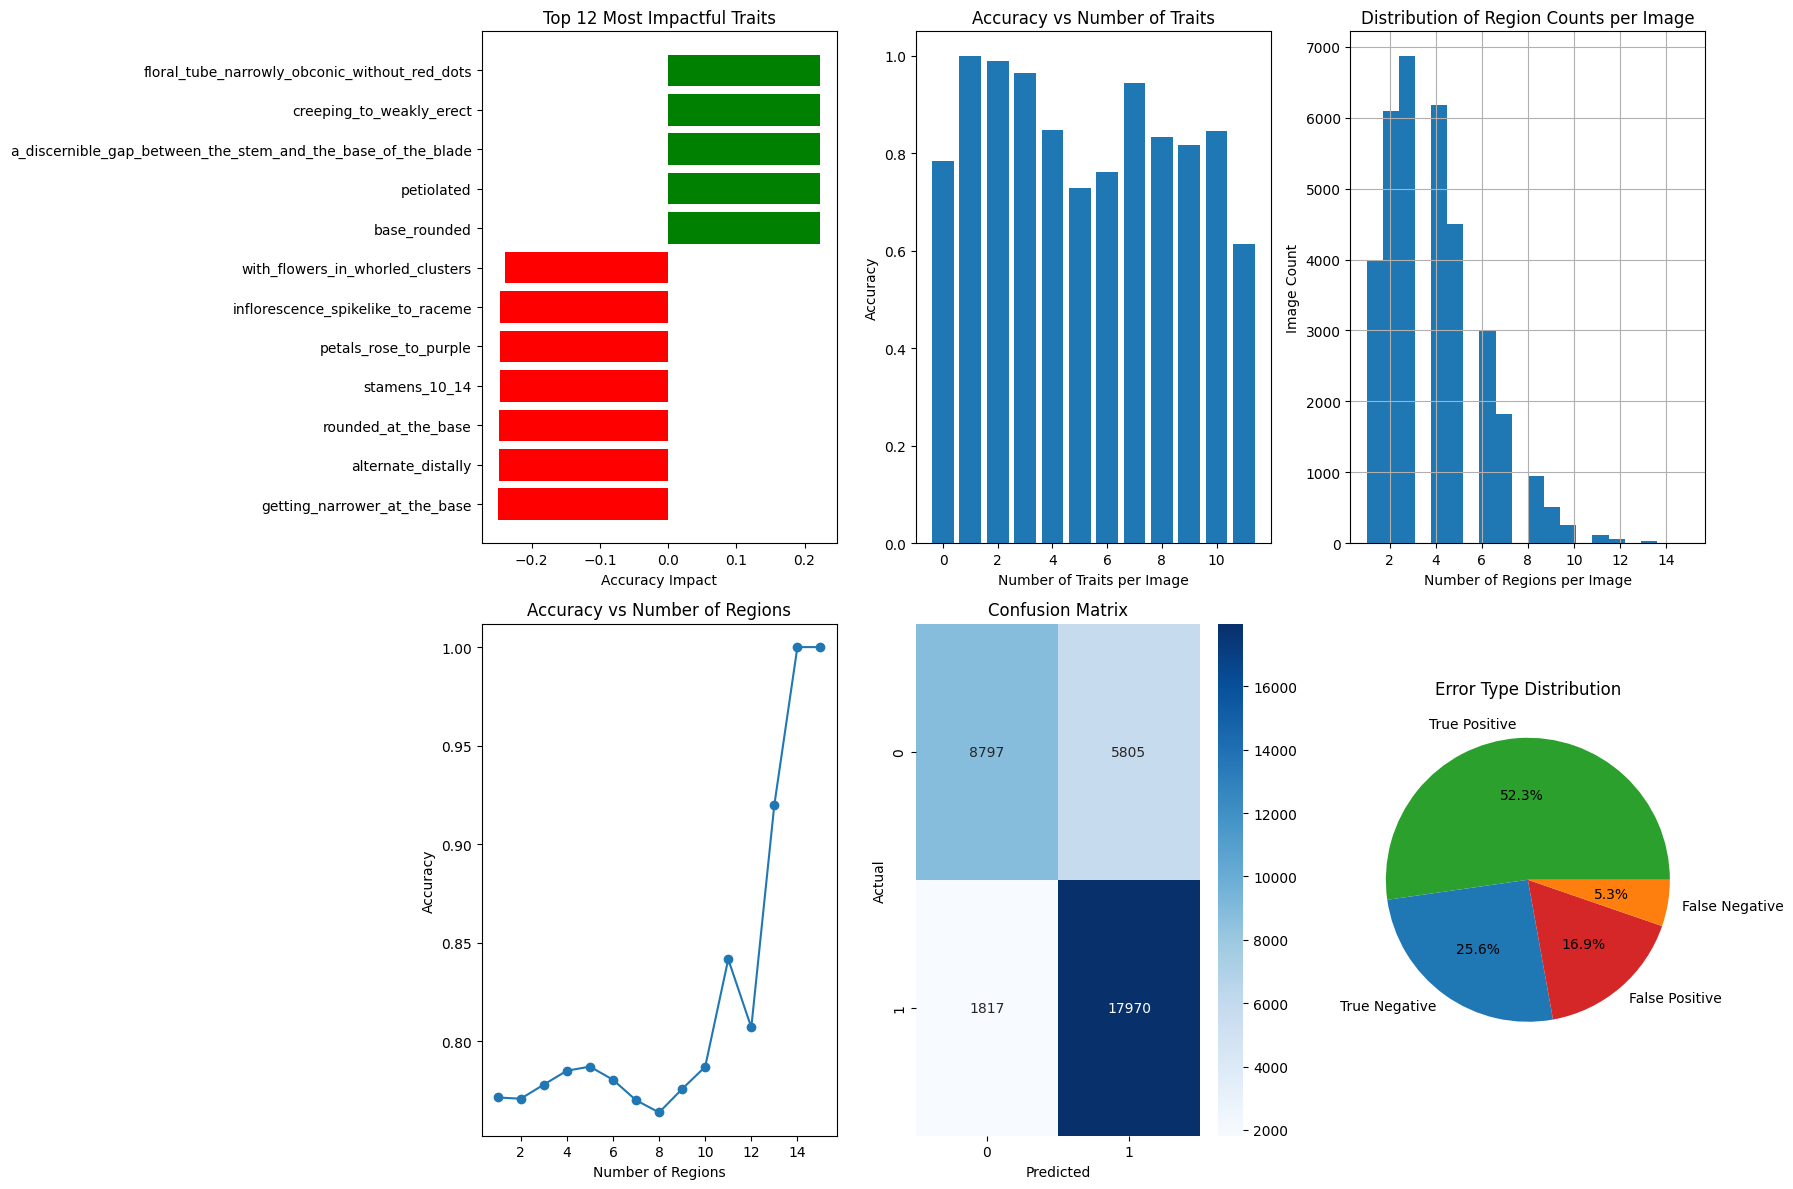

TRAIT CO-OCCURRENCE PATTERNS (Intro)
Plotting co-occurrence for top 16 most frequent traits for readability.


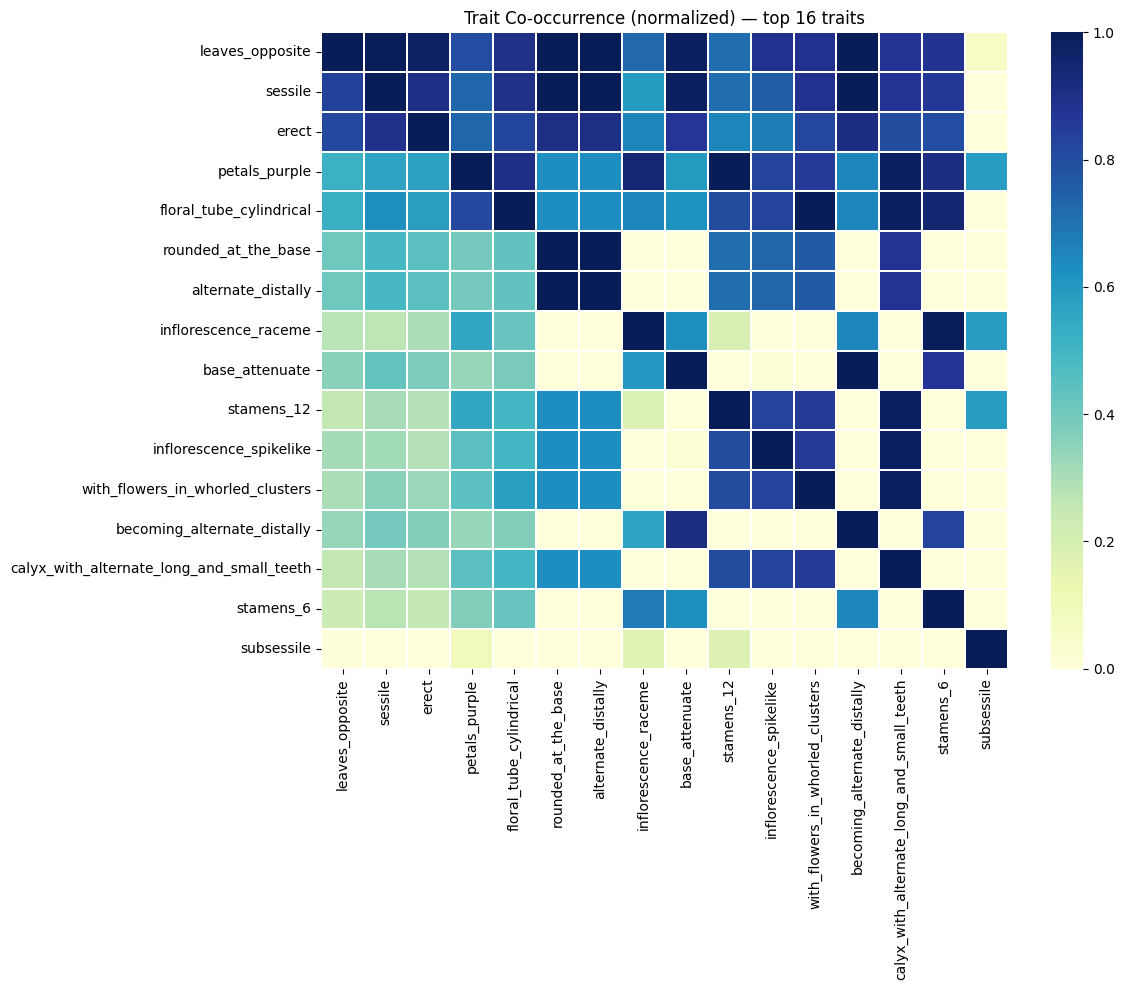


Interpretation:
  - Cells close to 1 mean that nearly all images with trait_i also have trait_j (given denominator used).
  - Use the top-left block to identify trait clusters frequently co-occurring.

TRAIT CO-OCCURRENCE PATTERNS (Intro)
Plotting co-occurrence for top 20 most frequent traits for readability.


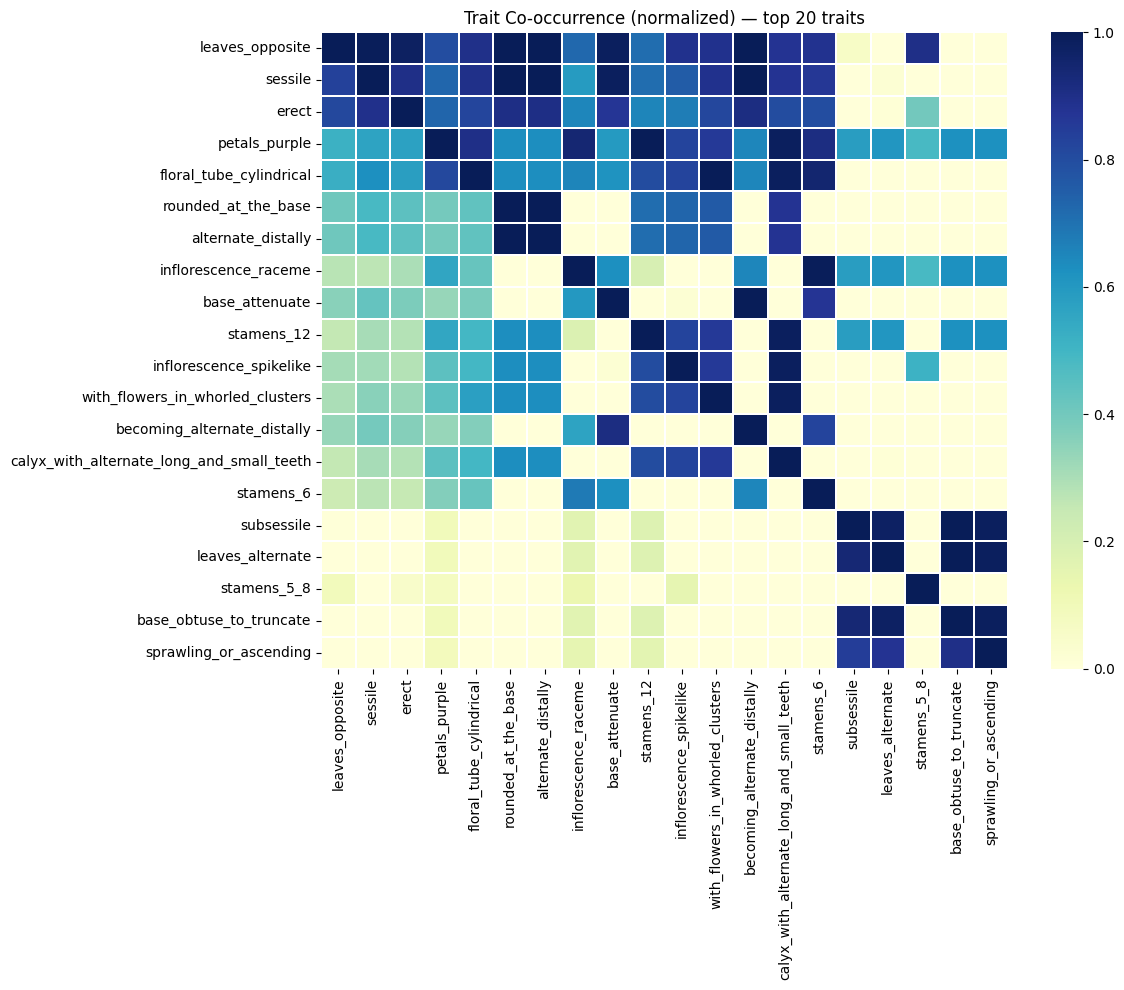


Interpretation:
  - Cells close to 1 mean that nearly all images with trait_i also have trait_j (given denominator used).
  - Use the top-left block to identify trait clusters frequently co-occurring.



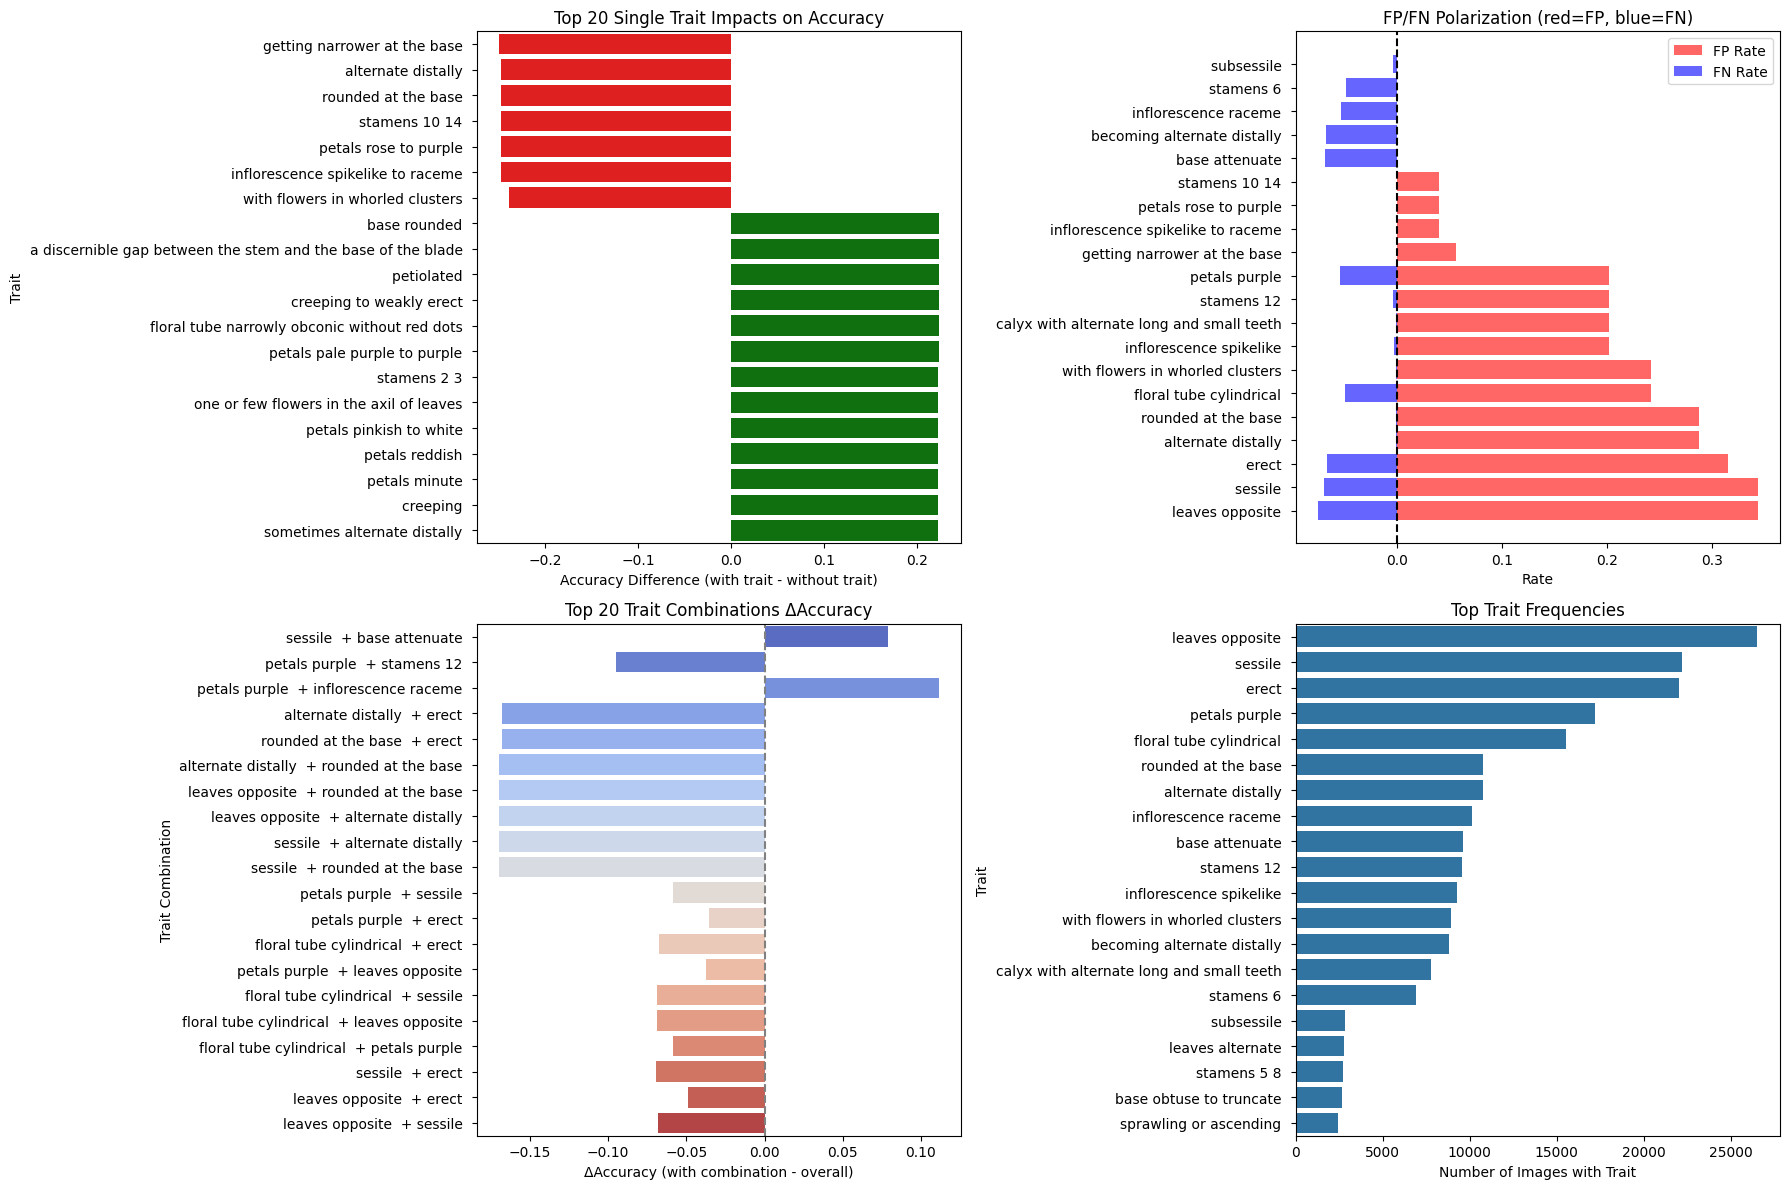


REPORT COMPLETE. Outputs dictionary contains DataFrames and analyses for further programmatic use.


In [56]:
image_analyzer = EnhancedImageLevelAnalyzer(merged_df)

image_results = image_analyzer.comprehensive_summary_report()

old version

ENHANCED IMAGE-LEVEL MODEL ANALYSIS REPORT

IMAGE-LEVEL PERFORMANCE SUMMARY
Overall Accuracy: 0.778 (n=34389)
True Positives: 17970
True Negatives: 8797
False Positives: 5805
False Negatives: 1817
Error type counts:
error_type
True Positive     17970
True Negative      8797
False Positive     5805
False Negative     1817
Name: count, dtype: int64

ANNOTATION LABEL IMPACT (image-level)

Impact of Hand label:
  With Hand:   Acc=0.778, TP=0.527, TN=0.251 (n=9818)
  Without Hand: Acc=0.779, TP=0.521, TN=0.258 (n=24571)
  Difference: -0.001
  Chi-square test: NOT significant (p=0.8759)

Impact of Background label:
  With Background:   Acc=0.781, TP=0.528, TN=0.253 (n=23001)
  Without Background: Acc=0.773, TP=0.512, TN=0.261 (n=11388)
  Difference: +0.008
  Chi-square test: NOT significant (p=0.0900)

TOP TRAIT IMPACT
                                                trait  n_images  acc_with  \
57                       getting narrower at the base      1784  0.541480   
8                    

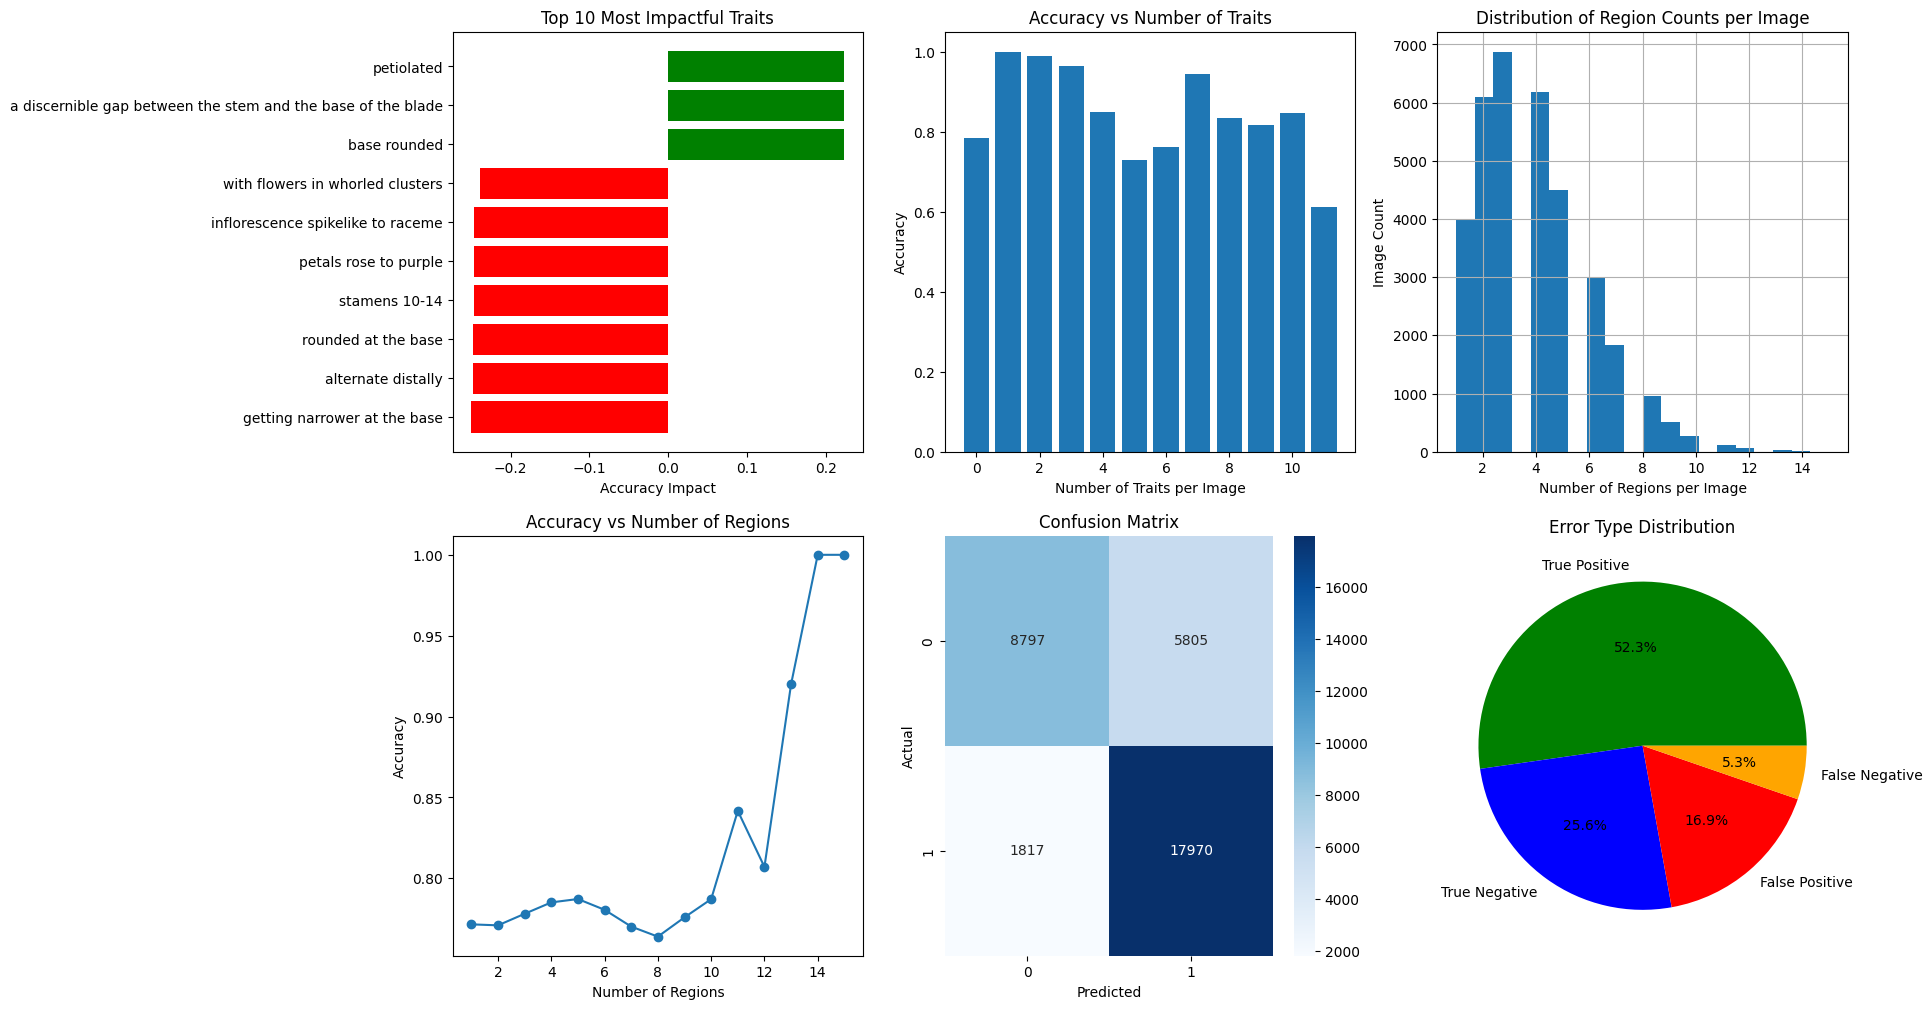

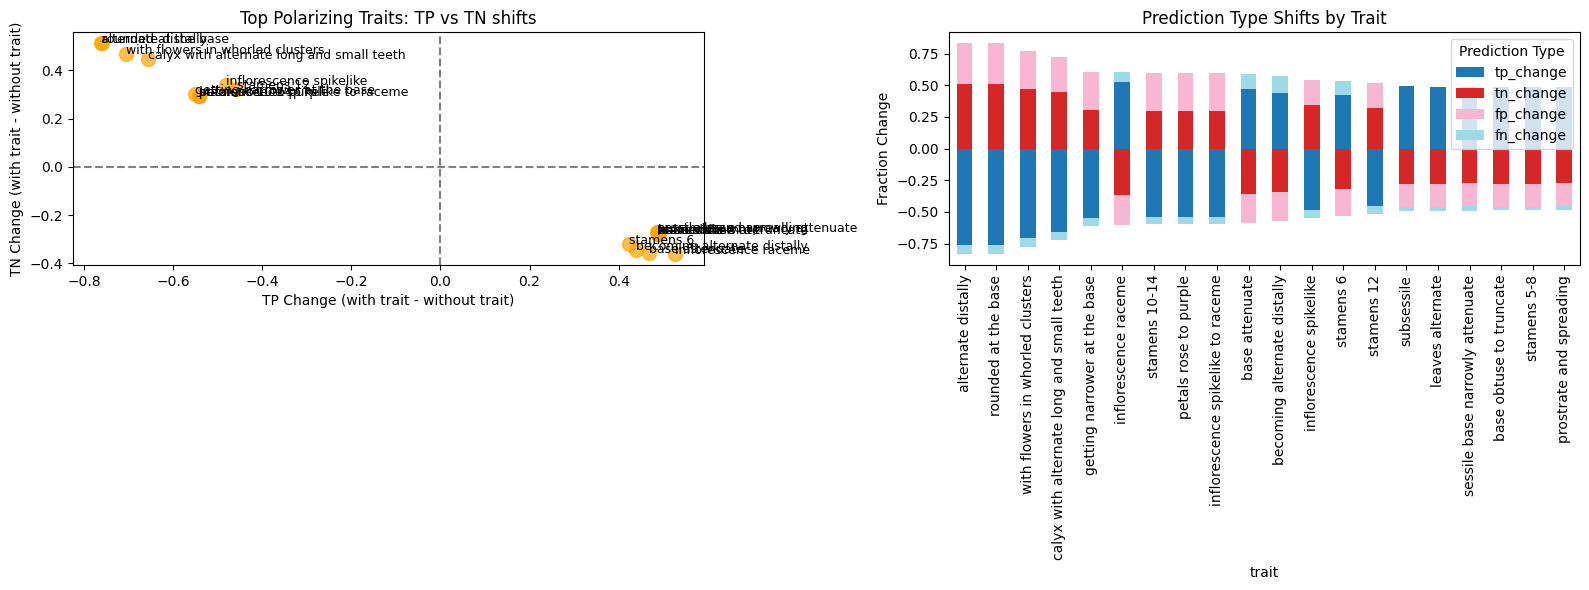

In [12]:
image_analyzer = EnhancedImageLevelAnalyzer(merged_df)

image_results = image_analyzer.comprehensive_summary_report()